# Locomotion Mode Recognition from Exoskeleton-Embeddable Sensors

**Data Mining and Machine Learning** — M.Sc. in Bionics Engineering, University of Pisa

Andrea Diano — Riccardo Mambrini

---

Complete pipeline: from the raw `.mat` recordings of the EPIC Lab dataset
(Camargo et al., 2021) to the final evaluation, the explanations and the error
analysis. Every number, table and figure in the report is produced here.

**Task.** Six classes — idle, walk, stair ascent/descent, ramp ascent/descent —
from 250 ms windows of IMU and goniometer signals only, the sensors an
exoskeleton can carry. EMG, force plates and motion capture are excluded by
design.

**Protocol.** Subject-independent throughout. Four subjects are held out from
the first step and evaluated once, at the end.

**Running it.** Top to bottom, `Restart & Run All`: about 13–14 hours from cold,
most of it hyperparameter search. Long stages checkpoint and resume where they
stopped. Needs Python 3.12 with `requirements.txt`, `Dataset_Camargo/` available
locally, and ~4 GB free. Figures are written to `figures/`.

In [1]:
# --- Setup: imports and project bootstrap -------------------------------------
# nb_utils.py sits next to this notebook, but Jupyter's working directory is not
# necessarily that folder: the project's IDE settings put the kernel root at the
# project folder instead. Searching for it, rather than assuming one path, keeps
# the notebook runnable after the folder is moved or on another machine.
import sys
from pathlib import Path

import numpy as np
import pandas as pd

_cwd = Path.cwd()
for _candidate in [_cwd, _cwd / "Notebook", *_cwd.parents]:
    if (_candidate / "nb_utils.py").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise FileNotFoundError(
        "nb_utils.py not found. Start Jupyter from the project folder or from "
        "Notebook/, or open this notebook from its own directory."
    )

from nb_utils import *   # config as C, notebook paths, class palette, helpers

# Style and class colours are set once, here, so that a class keeps the same
# colour in every figure below and the reader can connect them.
set_plot_style()

print(f"python {sys.version.split()[0]}  |  project root {PROJECT_ROOT}")
print(f"{len(C.CLASSES)} classes, "
      f"{len(C.IMU_CHANNELS) + len(C.GON_CHANNELS)} channels, "
      f"{C.WINDOW_MS} ms windows at a {C.STRIDE_MS_CV} ms stride")


python 3.12.10  |  project root locomotion-mode-recognition
6 classes, 29 channels, 250 ms windows at a 125 ms stride


## Part 1 — Data loading and quality

### 1.1 Reading the raw `.mat` files

The sensor tables are MATLAB `table` objects, which `scipy` cannot decode, so
they are read with `mat-io`. The sampling rate of every table is measured here
rather than taken from the dataset README, which documents a different one for
the labels. Only `conditions`, `imu` and `gon` are read. **Cost: ~2 min.**

In [2]:
# --- Phase 1.1: .mat loading diagnostics -------------------------------------
import scipy.io as sio
from matio import load_from_mat

INSPECT_SUBJECT = "AB06"
INSPECT_TRIALS = [("levelground", "levelground_ccw_normal_01"),
                  ("stair", "stair_1_l_01"),
                  ("ramp", "ramp_1_l_01")]
SENSORS_USED = ["conditions", "imu", "gon"]     # labels, inertial, goniometer
SENSORS_UNUSED = ["gcLeft", "gcRight", "emg", "fp", "ik", "id", "jp", "markers"]


def find_session_dir(subject: str) -> Path:
    """The session folder (e.g. 10_09_18) differs from subject to subject."""
    candidates = [d for d in sorted((C.DATASET_ROOT / subject).iterdir())
                  if d.is_dir() and d.name != "osimxml"]
    if not candidates:
        raise FileNotFoundError(f"no session folder for {subject}")
    return candidates[0]


def trial_file(session_dir: Path, mode: str, sensor: str, stem: str) -> Path | None:
    matches = sorted((session_dir / mode / sensor).glob(f"{stem}*.mat"))
    return matches[0] if matches else None


def table_stats(df: pd.DataFrame) -> dict:
    """Rows, columns and the *measured* sampling rate. The rate is never
    assumed: the cache phase resamples on the strength of this number, so an
    assumed one would propagate into every window and every feature."""
    dt = np.diff(pd.to_numeric(df["Header"], errors="coerce").to_numpy())
    dt = dt[np.isfinite(dt)]
    return {"rows": len(df), "cols": len(df.columns),
            "fs_hz": 1.0 / dt.mean(), "dt_max_ms": dt.max() * 1000}


session_dir = find_session_dir(INSPECT_SUBJECT)
first_mode, first_stem = INSPECT_TRIALS[0]
section(f"Phase 1.1 - {INSPECT_SUBJECT}, session {session_dir.name}")

# What scipy returns on its own. The table comes back undecoded, and that
# single fact is the reason the project depends on mat-io.
cond_path = trial_file(session_dir, first_mode, "conditions", first_stem)
scipy_labels_type = type(sio.loadmat(str(cond_path), squeeze_me=True,
                                     struct_as_record=False)["labels"]).__name__
print(f"  scipy.io.loadmat on a conditions file -> labels: {scipy_labels_type}"
      f"   (its ten scalar fields decode normally)")

stats, vocabulary = {}, {}
for mode, stem in INSPECT_TRIALS:
    for sensor in SENSORS_USED:
        data = load_from_mat(str(trial_file(session_dir, mode, sensor, stem)),
                             raw_data=False, add_table_attrs=False)
        for value in data.values():
            if not isinstance(value, pd.DataFrame):
                continue
            stats[(mode, sensor)] = table_stats(value)
            if sensor == "conditions":
                for lab, cnt in value["Label"].astype(str).value_counts().items():
                    vocabulary[lab] = vocabulary.get(lab, 0) + int(cnt)

print(f"\n  {'mode':<13}{'sensor':<12}{'rows':>9}{'cols':>6}"
      f"{'fs (Hz)':>10}{'max dt (ms)':>13}")
for (mode, sensor), st in stats.items():
    print(f"  {mode:<13}{sensor:<12}{st['rows']:>9,}{st['cols']:>6}"
          f"{st['fs_hz']:>10.2f}{st['dt_max_ms']:>13.4f}")

top = sorted(vocabulary.items(), key=lambda kv: -kv[1])[:3]
print(f"\n  labels: {len(vocabulary)} distinct over {sum(vocabulary.values()):,} "
      f"samples; most frequent " + ", ".join(f"{k} ({v:,})" for k, v in top))
print("  transition labels are present; the six-class mapping is settled in 1.3")

present = [s for s in SENSORS_USED + SENSORS_UNUSED
           if trial_file(session_dir, first_mode, s, first_stem)]
print(f"  sensor folders available: {len(present)}, of which {len(SENSORS_UNUSED)} "
      f"are laboratory-bound and excluded by design")



Phase 1.1 - AB06, session 10_09_18
  scipy.io.loadmat on a conditions file -> labels: MatlabOpaque   (its ten scalar fields decode normally)

  mode         sensor           rows  cols   fs (Hz)  max dt (ms)
  levelground  conditions      3,954     2    200.00       5.0000
  levelground  imu             3,954    25    200.00       5.0000
  levelground  gon            19,766     6   1000.00       1.0000
  stair        conditions      3,045     2    200.00       5.0000
  stair        imu             3,045    25    200.00       5.0000
  stair        gon            15,221     6   1000.00       1.0000
  ramp         conditions      3,226     2    200.00       5.0000
  ramp         imu             3,226    25    200.00       5.0000
  ramp         gon            16,126     6   1000.00       1.0000

  labels: 19 distinct over 10,225 samples; most frequent ['idle'] (3,297), ['walk'] (1,160), ['stand'] (1,084)
  transition labels are present; the six-class mapping is settled in 1.3
  sensor fold

### 1.2 Building the Parquet cache

Every trial is read once and written to a columnar cache, so no later phase
touches a `.mat` file again. Per trial: the goniometer is joined onto the IMU
time base by nearest neighbour within half a sample, raw labels are mapped onto
the six classes with each transition absorbed into the mode it leads into, and
every sample is marked steady or transitional. Nothing is filtered or
normalised — that belongs downstream, inside cross-validation. The cache is also
the checkpoint: a re-run skips the pairs already written.

In [3]:
# --- Phase 1.2: build the Parquet cache --------------------------------------

from matio import load_from_mat
from tqdm.auto import tqdm

MANIFEST_PATH = PARQUET_DIR / "MANIFEST.csv"
LABEL_COUNTS_PATH = PARQUET_DIR / "label_counts.csv"


def scalarize(value):
    """Fields of `conditions` arrive as nested object arrays. Return a plain
    Python scalar, or None when the field is empty."""
    if value is None:
        return None
    arr = np.asarray(value, dtype=object).ravel()
    while arr.size == 1 and isinstance(arr[0], np.ndarray):
        arr = np.asarray(arr[0], dtype=object).ravel()
    if arr.size == 0:
        return None
    if arr.size > 1:                      # e.g. transLegAscent = ['l', 'r']
        return "|".join(str(x) for x in arr)
    v = arr[0]
    if isinstance(v, (bytes, np.bytes_)):
        v = v.decode()
    if isinstance(v, str):
        return v.strip() or None
    if isinstance(v, (np.floating, float)):
        return float(v)
    if isinstance(v, (np.integer, int)):
        return int(v)
    return v


def flatten_label(series: pd.Series) -> pd.Series:
    """The `Label` column holds one-element arrays; turn them into strings."""
    def one(v):
        if isinstance(v, str):
            return v.strip()
        arr = np.asarray(v, dtype=object).ravel()
        if arr.size == 0:
            return ""
        x = arr[0]
        return x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x).strip()
    return series.map(one)


def session_dir_of(subject_dir: Path) -> Path:
    candidates = [d for d in sorted(subject_dir.iterdir())
                  if d.is_dir() and d.name != "osimxml"]
    if not candidates:
        raise FileNotFoundError(f"no session folder in {subject_dir}")
    return candidates[0]


def load_trial(session: Path, mode: str, stem: str) -> tuple[pd.DataFrame, dict]:
    """One trial, aligned onto the IMU's 200 Hz grid, with its diagnostics."""
    paths = {s: session / mode / s / f"{stem}.mat"
             for s in ("conditions", "imu", "gon")}
    for sensor, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f"missing {sensor}/{stem}.mat")

    cond = load_from_mat(str(paths["conditions"]), raw_data=False)
    imu = load_from_mat(str(paths["imu"]), raw_data=False)["data"]
    gon = load_from_mat(str(paths["gon"]), raw_data=False)["data"]

    labels = cond["labels"].copy()
    labels["label_raw"] = flatten_label(labels["Label"])
    labels = labels[["Header", "label_raw"]]
    meta = {k: scalarize(v) for k, v in cond.items()
            if k != "labels" and not k.startswith("__")}

    # Timing diagnostics on the IMU, the master clock of the trial.
    h = imu["Header"].to_numpy(dtype=float)
    dt = np.diff(h)
    diag = {"n_rows_imu": len(imu), "n_rows_gon": len(gon),
            "n_rows_labels": len(labels),
            "t_start": float(h[0]), "t_end": float(h[-1]),
            "duration_s": float(h[-1] - h[0]),
            "dt_mean_ms": float(dt.mean() * 1000),
            "dt_max_ms": float(dt.max() * 1000),
            "n_gaps": int((dt > 1.5 / C.FS_TARGET_HZ).sum())}

    # Goniometer onto the IMU grid: nearest neighbour within half a sample.
    # The labels already share the IMU Header, so their join is exact.
    df = pd.merge_asof(imu.sort_values("Header").reset_index(drop=True),
                       gon.sort_values("Header").reset_index(drop=True),
                       on="Header", direction="nearest",
                       tolerance=C.MERGE_TOLERANCE_S)
    diag["gon_unmatched"] = int(df[C.GON_CHANNELS[0]].isna().sum())

    df = pd.merge_asof(df, labels.sort_values("Header").reset_index(drop=True),
                       on="Header", direction="nearest",
                       tolerance=C.MERGE_TOLERANCE_S)
    diag["labels_unmatched"] = int(df["label_raw"].isna().sum())

    # A transition is absorbed into the mode it leads into, and stays flagged
    # so the decision can be revisited without rebuilding.
    df["label_raw"] = df["label_raw"].fillna("")
    df["label"] = df["label_raw"].map(C.LABEL_MAP)
    df["is_transition"] = df["label_raw"].isin(C.TRANSITION_LABELS)
    df["transition_dir"] = df["label_raw"].map(C.transition_direction).fillna("")
    diag["label_unmapped"] = int(df["label"].isna().sum())
    diag["unknown_labels"] = sorted(set(df.loc[df["label"].isna(), "label_raw"]) - {""})

    df["trial_id"] = stem
    df["mode"] = mode
    # Condition metadata: kept for the breakdown in Part 5, never a feature.
    for key in ("speed", "turn", "stairHeight", "rampIncline", "leadingLegStart",
                "leadingLegStop", "transLegAscent", "transLegDescent"):
        df[f"cond_{key}"] = meta.get(key)

    # `labelError` is a logical vector, one element per circuit, levelground
    # only. Through scalarize it became the string "0|0|0", and `"0|0|0" != 0`
    # is always true — that is how 638 of 680 trials once looked mislabelled.
    le = cond.get("labelError")
    if le is None:
        diag["labelError_n"] = diag["labelError_nonzero"] = 0
    else:
        le = np.asarray(le).ravel()
        diag["labelError_n"] = int(le.size)
        diag["labelError_nonzero"] = int((le != 0).sum())

    return df, diag


# --- Execution ---------------------------------------------------------------
subject_dirs = sorted(d for d in C.DATASET_ROOT.iterdir()
                      if d.is_dir() and d.name.startswith("AB"))
pairs = [(d, m) for d in subject_dirs for m in C.MODES]

# The cache is its own checkpoint: a pair is done when its Parquet file exists
# and the manifest still carries its rows.
manifest_rows, label_rows, done = [], [], set()
if MANIFEST_PATH.exists() and LABEL_COUNTS_PATH.exists():
    prev, prev_labels = pd.read_csv(MANIFEST_PATH), pd.read_csv(LABEL_COUNTS_PATH)
    done = {(s, m) for s, m in zip(prev["subject"], prev["mode"])
            if (PARQUET_DIR / f"{s}__{m}.parquet").is_file()}
    keep = [(s, m) in done for s, m in zip(prev["subject"], prev["mode"])]
    manifest_rows = prev[keep].to_dict("records")
    keep_l = [(s, m) in done for s, m in zip(prev_labels["subject"], prev_labels["mode"])]
    label_rows = prev_labels[keep_l].to_dict("records")

section(f"Phase 1.2 - cache in {PARQUET_DIR}")
if done:
    checkpoint_note(MANIFEST_PATH, len(done), "subject-mode pairs")

for subj_dir, mode in tqdm(pairs, desc="subject-mode", unit="pair"):
    subject = subj_dir.name
    if (subject, mode) in done:
        continue
    session = session_dir_of(subj_dir)
    stems = sorted(p.stem for p in (session / mode / "conditions").glob("*.mat"))
    if not stems:
        raise FileNotFoundError(f"no trials in {session / mode / 'conditions'}")

    frames = []
    for stem in stems:
        df, diag = load_trial(session, mode, stem)
        df.insert(0, "subject", subject)
        frames.append(df)
        manifest_rows.append({"subject": subject, "mode": mode,
                              "trial_id": stem, **diag})
        for lab, cnt in df["label_raw"].value_counts().items():
            label_rows.append({"subject": subject, "mode": mode,
                               "label_raw": lab, "n_samples": int(cnt)})

    pd.concat(frames, ignore_index=True).to_parquet(
        PARQUET_DIR / f"{subject}__{mode}.parquet",
        engine="pyarrow", compression="snappy", index=False)
    # Rewritten after every pair, so an interrupted run resumes from here.
    pd.DataFrame(manifest_rows).to_csv(MANIFEST_PATH, index=False)
    pd.DataFrame(label_rows).to_csv(LABEL_COUNTS_PATH, index=False)

manifest = pd.DataFrame(manifest_rows)
label_counts = pd.DataFrame(label_rows)
n_files = len(list(PARQUET_DIR.glob("*__*.parquet")))
print(f"\n  {len(manifest):,} trials over {len(pairs)} subject-mode pairs, "
      f"{n_files} Parquet files, {int(manifest['n_rows_imu'].sum()):,} samples")

c:\dev\har-dm-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phase 1.2 - cache in locomotion-mode-recognition\Notebook\cache\parquet
  checkpoint found: MANIFEST.csv -> reusing 66 subject-mode pairs already computed; they will not be recomputed


subject-mode: 100%|██████████| 66/66 [00:00<?, ?pair/s]


  2,990 trials over 66 subject-mode pairs, 66 Parquet files, 9,917,736 samples


In [4]:
# --- Phase 1.2: data quality of the cache ------------------------------------
# Reads back what was written, not what was in memory: it validates the artefact
# the rest of the notebook consumes.
#
# `isna()` does not catch infinities. Valid means finite AND inside the
# channel's physical limit — counting only NaN once let 1,273 infinities and
# 1,570 out-of-range angles pass as good data.

limits = np.array([C.channel_limit(ch) for ch in C.ALL_CHANNELS], dtype=float)
n_nan = np.zeros(len(C.ALL_CHANNELS), dtype=np.int64)
n_inf = np.zeros_like(n_nan)
n_oor = np.zeros_like(n_nan)
cache_rows = 0
n_bad_cells = 0

for path in tqdm(sorted(PARQUET_DIR.glob("*__*.parquet")),
                 desc="quality scan", unit="file"):
    A = pd.read_parquet(path, columns=C.ALL_CHANNELS).to_numpy(dtype=float)
    finite = np.isfinite(A)
    cache_rows += len(A)
    n_nan += np.isnan(A).sum(axis=0)
    n_inf += np.isinf(A).sum(axis=0)
    n_oor += (finite & (np.abs(np.where(finite, A, 0.0)) > limits)).sum(axis=0)
    # The same cells counted again through `C.valid_mask`, the project's
    # definition of validity: if this cell's own arithmetic ever drifts from it,
    # 1.3 and the windowing would be counting something else.
    n_bad_cells += int((~C.valid_mask(A, C.ALL_CHANNELS)).sum())

invalid = pd.DataFrame({"nan": n_nan, "inf": n_inf, "out_of_range": n_oor},
                       index=C.ALL_CHANNELS)
invalid["total"] = invalid.sum(axis=1)
invalid = invalid[invalid["total"] > 0].sort_values("total", ascending=False)
n_invalid_cells = int(invalid["total"].sum())
n_cells = cache_rows * len(C.ALL_CHANNELS)

section("Phase 1.2 - data quality")
print(f"  {'channel':<18}{'NaN':>8}{'inf':>8}{'out of range':>14}{'total':>9}{'share':>10}")
for ch, r in invalid.head(5).iterrows():
    print(f"  {ch:<18}{r['nan']:>8,}{r['inf']:>8,}{r['out_of_range']:>14,}"
          f"{r['total']:>9,}{100 * r['total'] / cache_rows:>9.4f}%")
rest = invalid.iloc[5:]
if len(rest):
    print(f"  {f'+ {len(rest)} further channels':<18}{'':>30}"
          f"{int(rest['total'].sum()):>9,}")
print(f"\n  {n_invalid_cells:,} invalid cells out of {n_cells:,} "
      f"({100 * n_invalid_cells / n_cells:.6f}%)")

# Class distribution after the mapping. This is the table report §2 describes.
label_counts["label"] = label_counts["label_raw"].map(C.LABEL_MAP)
by_class = label_counts.groupby("label", dropna=False)["n_samples"].sum() \
                       .sort_values(ascending=False)
print(f"\n  {'class':<16}{'samples':>13}{'minutes':>10}{'share':>9}")
for lab, n in by_class.items():
    print(f"  {str(lab):<16}{n:>13,}{n / C.FS_TARGET_HZ / 60:>10.1f}"
          f"{100 * n / by_class.sum():>8.2f}%")
print(f"  imbalance, largest over smallest: {by_class.max() / by_class.min():.1f}x")


quality scan: 100%|██████████| 66/66 [00:07<00:00,  8.36file/s]

Phase 1.2 - data quality
  channel                NaN     inf  out of range    total     share
  ankle_frontal          432   1,273             0    1,705   0.0172%
  ankle_sagittal         125       0         1,570    1,695   0.0171%
  hip_sagittal           125       0             0      125   0.0013%
  knee_sagittal          125       0             0      125   0.0013%
  hip_frontal            125       0             0      125   0.0013%
  + 19 further channels                                    210

  3,985 invalid cells out of 287,614,344 (0.001386%)

  class                 samples   minutes    share
  idle                3,503,052     291.9   35.32%
  walk                2,806,366     233.9   28.30%
  ramp_descent        1,274,178     106.2   12.85%
  ramp_ascent         1,234,644     102.9   12.45%
  stair_ascent          562,696      46.9    5.67%
  stair_descent         536,800      44.7    5.41%
  imbalance, largest over smallest: 6.5x


Nothing was filtered, resampled or repaired. Invalid values are counted and left
in place; what to do about them is a modelling decision, taken later in one
place. They concentrate in the goniometer channels, where both infinities and
physically impossible angles appear — `isna()` alone sees neither and would have
called this data clean. The class distribution is strongly uneven, which is a
property of the protocol rather than a defect, and the reason macro-F1 is the
metric of this project.

### 1.3 Windows and invalid values

One pass over the cache, counting what §3.1 will need: how many window positions
the recording can produce at this stride, and how many touch at least one
invalid sample. **Cost: under a minute.**

In [5]:
# --- Phase 1.3: window positions and invalid values ---------------------------
# One pass over the cache. `isna()` would miss the infinities and the
# out-of-range angles counted in 1.2, so validity is the project's own
# definition: finite AND inside the channel's physical limit.
from tqdm.auto import tqdm

WIN, STRIDE = C.WINDOW_SAMPLES, C.STRIDE_SAMPLES_CV

section("Phase 1.3 - window positions and invalid values")

n_trials = n_samples = n_bad_samples = win_tot = win_bad = 0

for fp in tqdm(sorted(PARQUET_DIR.glob("*__*.parquet")), desc="parquet",
               unit="file"):
    df = pd.read_parquet(fp, columns=["trial_id", "Header"] + C.ALL_CHANNELS)
    for _, g in df.groupby("trial_id", sort=True):
        g = g.sort_values("Header")
        n = len(g)
        n_trials += 1
        n_samples += n

        bad = ~C.valid_mask(g[C.ALL_CHANNELS].to_numpy(dtype=float),
                            C.ALL_CHANNELS).all(axis=1)
        n_bad_samples += int(bad.sum())

        if n >= WIN:                      # exact count of contaminated windows
            csum = np.concatenate([[0], np.cumsum(bad.astype(int))])
            starts = np.arange(0, n - WIN + 1, STRIDE)
            win_tot += len(starts)
            win_bad += int((csum[starts + WIN] - csum[starts] > 0).sum())

print(f"\n  trials read             : {n_trials:>7,}")
print(f"  samples                 : {n_samples:>7,}")
print(f"  samples with >=1 invalid: {n_bad_samples:>7,}"
      f" ({100 * n_bad_samples / n_samples:.4f}%)")
print(f"\nWindows of {C.WINDOW_MS} ms at a {C.STRIDE_MS_CV} ms stride")
print(f"  complete windows        : {win_tot:>7,}")
print(f"  touching an invalid one : {win_bad:>7,}"
      f" ({100 * win_bad / win_tot:.4f}%)")
print("\n  few enough to drop rather than repair: no invented value enters")
print("  the dataset, and 3.1 discards them when it builds the windows")


Phase 1.3 - window positions and invalid values


parquet: 100%|██████████| 66/66 [00:05<00:00, 11.03file/s]


  trials read             :   2,990
  samples                 : 9,917,736
  samples with >=1 invalid:   1,792 (0.0181%)

Windows of 250 ms at a 125 ms stride
  complete windows        : 392,292
  touching an invalid one :     118 (0.0301%)

  few enough to drop rather than repair: no invented value enters
  the dataset, and 3.1 discards them when it builds the windows


Contaminated windows are a vanishing share of the total, so §3.1 drops them
instead of repairing them: no invented value enters the dataset.

### 1.4 The frozen split

Four subjects are set aside now, before anything is plotted. Windowing and
feature extraction act on one window at a time and learn nothing from the
dataset as a whole, so they are safe to run on everything; the leak is in the
decisions *we* make while looking at the data. Pick channels from a correlation
matrix over all 22 subjects and test information has entered the model — and no
`Pipeline` can unfit a choice a person made.

The four are drawn one per quartile of recording volume, by seed rather than by
hand, and only from subjects who are alone on their recording day. The split is
never regenerated, and nothing below touches the held-out four until §4.1.

In [6]:
# --- Phase 1.4: freeze the subject split --------------------------------------

import json
from datetime import datetime

SPLIT_PATH = CACHE_DIR / "split_subjects.json"
N_TEST = C.N_TEST_SUBJECTS


def recording_dates():
    """The day each subject was recorded, from its single dated session folder.
    Six days hold two subjects; the other ten hold one."""
    dates = {}
    for sd in sorted(d for d in C.DATASET_ROOT.iterdir()
                     if d.is_dir() and d.name.startswith("AB")):
        folders = [d.name for d in sorted(sd.iterdir())
                   if d.is_dir() and d.name != "osimxml"]
        if folders:
            dates[sd.name] = folders[0]
    return dates


def subject_inventory():
    """Samples per subject and per class, plus recording day and eligibility.

    These counts run over all 22 subjects on purpose. They are descriptive and
    they are what decides the split itself; no modelling choice is taken from
    them. Every analysis that guides a decision starts at 2.1, on the 18."""
    rows = []
    for fp in sorted(PARQUET_DIR.glob("*__*.parquet")):
        subject, _ = fp.stem.split("__")
        labels = pd.read_parquet(fp, columns=["label"])["label"]
        rec = {"subject": subject, "n_samples": len(labels)}
        rec.update({str(k): int(v) for k, v in labels.value_counts().items()})
        rows.append(rec)

    inv = pd.DataFrame(rows).fillna(0).groupby("subject").sum()
    inv["minutes"] = inv["n_samples"] / C.FS_TARGET_HZ / 60
    inv["n_classes"] = sum((inv[c] > 0).astype(int) for c in C.CLASSES)

    dates = recording_dates()
    inv["day"] = [dates.get(s, "?") for s in inv.index]
    inv["same_day"] = inv["day"].map(inv["day"].value_counts())
    # Eligible as held-out: alone on its recording day. A held-out subject that
    # shared a day with a training subject would have been recorded under the
    # same calibration and would read as slightly more familiar than it should.
    # This is NOT label leakage - every day contains all six activities, so the
    # day's signature cannot help guess the class - but excluding it costs
    # nothing, since ten eligible subjects already cover all four quartiles.
    inv["eligible"] = inv["same_day"] == 1
    return inv.sort_values("n_samples")


def choose_test_subjects(inv, n_test):
    """One subject per quartile of recording volume, drawn among the eligible.

    Quartiles are computed over all 22 subjects: recomputing them on the ten
    eligible ones would make the bands stop describing the real distribution of
    volumes. Two fallbacks, both fixed before the outcome was seen - redraw with
    seed+1 if a subject were missing a class, borrow from the nearest quartile
    if one held no eligible subject. Neither has ever fired: all 22 subjects
    carry all six classes, and every quartile has at least one eligible."""
    order = inv.sort_values("n_samples").index.tolist()
    cuts = [round(i * len(order) / n_test) for i in range(n_test + 1)]
    quartiles = [order[cuts[i]:cuts[i + 1]] for i in range(n_test)]

    chosen, detail = [], []
    for i, q in enumerate(quartiles):
        pool = [s for s in q if bool(inv.loc[s, "eligible"]) and s not in chosen]
        borrowed = False
        if not pool:
            borrowed = True
            for delta in range(1, n_test):
                for j in (i - delta, i + delta):
                    if 0 <= j < n_test:
                        cand = [s for s in quartiles[j]
                                if bool(inv.loc[s, "eligible"]) and s not in chosen]
                        if cand:
                            pool = cand
                            break
                if pool:
                    break
        if not pool:
            raise RuntimeError(f"quartile {i + 1}: no eligible subject")

        seed = C.RANDOM_SEED + i
        while True:
            pick = str(np.random.default_rng(seed).choice(pool))
            if int(inv.loc[pick, "n_classes"]) == len(C.CLASSES):
                break
            seed += 1
            if seed > C.RANDOM_SEED + i + 50:
                raise RuntimeError(f"quartile {i + 1}: no valid candidate")

        chosen.append(pick)
        detail.append({"quartile": i + 1, "n_subjects": len(q),
                       "eligible": pool, "seed": seed, "chosen": pick,
                       "range": [int(inv.loc[q, "n_samples"].min()),
                                 int(inv.loc[q, "n_samples"].max())],
                       "borrowed": borrowed})
    return chosen, detail


# --- Execution ----------------------------------------------------------------
section("Phase 1.4 - frozen split")

inv = subject_inventory()
n_eligible = int(inv["eligible"].sum())
shared = inv.loc[inv["same_day"] > 1, "day"].nunique()

print("\nEligibility: a held-out subject must be alone on its recording day")
print(f"  recording days holding two : {shared:>4}"
      f"  -> {len(inv) - n_eligible} subjects excluded")
print(f"  eligible as held-out       : {n_eligible:>4} of {len(inv)}")
print(f"  carrying all {len(C.CLASSES)} classes     :"
      f" {int((inv['n_classes'] == len(C.CLASSES)).sum()):>4} of {len(inv)}")

if SPLIT_PATH.exists():
    split = json.loads(SPLIT_PATH.read_text(encoding="utf-8"))
    checkpoint_note(SPLIT_PATH, len(split["test"]), "held-out subjects")
    print("  the split is frozen: it is read back, never redrawn")
else:
    test, detail = choose_test_subjects(inv, N_TEST)
    split = {"created": datetime.now().isoformat(timespec="seconds"),
             "criterion": ("one subject per quartile of recording volume, "
                           "quartiles over all 22, held-out subjects alone on "
                           f"their recording day; seed {C.RANDOM_SEED}"),
             "random_seed": C.RANDOM_SEED, "test": sorted(test),
             "dev": sorted(s for s in inv.index if s not in test),
             "recording_days": {s: str(inv.loc[s, "day"]) for s in inv.index},
             "quartiles": detail}
    SPLIT_PATH.write_text(json.dumps(split, indent=2), encoding="utf-8")

TEST_SUBJECTS, DEV_SUBJECTS = split["test"], split["dev"]
q_test, q_dev = inv.loc[TEST_SUBJECTS], inv.loc[DEV_SUBJECTS]
gaps = {c: q_test[c].sum() / q_test["n_samples"].sum()
        - q_dev[c].sum() / q_dev["n_samples"].sum() for c in C.CLASSES}
worst = max(gaps, key=lambda c: abs(gaps[c]))

print("\nStratified draw, one subject per quartile of recording volume")
for d in split["quartiles"]:
    print(f"  quartile {d['quartile']} ({d['range'][0]:,}-{d['range'][1]:,}"
          f" samples): {len(d['eligible'])} eligible, seed {d['seed']}"
          f" -> {d['chosen']}" + ("  [borrowed]" if d["borrowed"] else ""))

print(f"\nFrozen split, held in the notebook cache as {SPLIT_PATH.name}")
print(f"  {'held-out':<11} ({len(TEST_SUBJECTS):>2}) : {', '.join(TEST_SUBJECTS)}")
print(f"  {'':<11}        {int(q_test['n_samples'].sum()):>9,} samples,"
      f" {q_test['minutes'].sum():>6.1f} min")
print(f"  {'development':<11} ({len(DEV_SUBJECTS):>2}) :"
      f" {int(q_dev['n_samples'].sum()):>9,} samples,"
      f" {q_dev['minutes'].sum():>6.1f} min")
print(f"  widest class-share gap between the two:"
      f" {worst} {100 * gaps[worst]:+.2f} pp")
print("  from here to 4.1 every cell reads the development subjects only")



Phase 1.4 - frozen split

Eligibility: a held-out subject must be alone on its recording day
  recording days holding two :    6  -> 12 subjects excluded
  eligible as held-out       :   10 of 22
  carrying all 6 classes     :   22 of 22
  checkpoint found: split_subjects.json -> reusing 4 held-out subjects already computed; they will not be recomputed
  the split is frozen: it is read back, never redrawn

Stratified draw, one subject per quartile of recording volume
  quartile 1 (357,619-425,847 samples): 2 eligible, seed 42 -> AB15
  quartile 2 (428,374-445,473 samples): 1 eligible, seed 43 -> AB18
  quartile 3 (453,330-487,632 samples): 3 eligible, seed 44 -> AB28
  quartile 4 (489,508-552,183 samples): 4 eligible, seed 45 -> AB07

Frozen split, held in the notebook cache as split_subjects.json
  held-out    ( 4) : AB07, AB15, AB18, AB28
                     1,833,292 samples,  152.8 min
  development (18) : 8,084,444 samples,  673.7 min
  widest class-share gap between the two: wal

The four span the range of recording volume rather than clustering at one end,
and none shares a recording day with a training subject. The two halves differ
slightly in class composition and that difference stays: correcting it by
redrawing would be selection in disguise. The split is stratified by how much
data a subject contributed, never by what that data contains.

### 1.5 The dataset at a glance

Assembled from counts the cells above already produced. It runs over all 22
subjects, held-out ones included, on purpose: the table describes the recording
and informs no modelling choice. What is forbidden before §4.1 is *learning*
from those subjects, not counting their samples.

In [7]:
# --- Phase 1.5: the dataset at a glance ---------------------------------------
# No new computation: every number below was produced by a cell above.

hours = cache_rows / C.FS_TARGET_HZ / 3600

# A row whose key is None is a rule, optionally carrying a section heading.
rows = [
    (None, "Protocol"),
    ("Subjects", f"{len(inv)} ({len(DEV_SUBJECTS)} development, "
                 f"{len(TEST_SUBJECTS)} held out)"),
    ("Trials", f"{len(manifest):,} over {len(C.MODES)} circuits"),
    ("Labelled samples", f"{cache_rows:,} ({hours:.1f} h at {C.FS_TARGET_HZ} Hz)"),
    ("Sensor channels", f"{len(C.ALL_CHANNELS)} ({len(C.IMU_CHANNELS)} IMU, "
                        f"{len(C.GON_CHANNELS)} goniometer)"),
    ("Invalid values", f"{n_invalid_cells:,} cells "
                       f"({100 * n_invalid_cells / n_cells:.4f}%)"),
    ("Windows", f"{win_tot:,} of {C.WINDOW_MS} ms, {C.STRIDE_MS_CV} ms stride"),
    (None, "Class distribution"),
]
rows += [(str(lab), f"{int(n):,} ({100 * n / cache_rows:.2f}%)")
         for lab, n in by_class.items()]
rows += [(None, None),
         ("Imbalance, largest over smallest",
          f"{by_class.max() / by_class.min():.1f}:1")]

section("Phase 1.5 - the dataset at a glance")
for key, value in rows:
    if key is None:
        print(f"\n  {value}" if value else "")
    else:
        print(f"    {key:<32}{value:>36}")


Phase 1.5 - the dataset at a glance

  Protocol
    Subjects                             22 (18 development, 4 held out)
    Trials                                         2,990 over 3 circuits
    Labelled samples                        9,917,736 (13.8 h at 200 Hz)
    Sensor channels                            29 (24 IMU, 5 goniometer)
    Invalid values                                 3,985 cells (0.0014%)
    Windows                             392,292 of 250 ms, 125 ms stride

  Class distribution
    idle                                              3,503,052 (35.32%)
    walk                                              2,806,366 (28.30%)
    ramp_descent                                      1,274,178 (12.85%)
    ramp_ascent                                       1,234,644 (12.45%)
    stair_ascent                                         562,696 (5.67%)
    stair_descent                                        536,800 (5.41%)

    Imbalance, largest over smallest                 

---

## Part 2 — Exploratory data analysis

### 2.1 What the development data looks like

Eighteen subjects only, for the reason given in §1.4. Means, standard deviations
and correlations are exact over every development sample, accumulated file by
file; only the box plots use a subsample, because quantiles need one. Nothing is
filtered, imputed or rebalanced here.

In [8]:
# --- Phase 2.1: one pass over the development subjects ------------------------

EDA_SAMPLE_PER_FILE = 6_000     # rows kept per file for the box plots


class Accumulator:
    """Exact means, standard deviations and correlations without holding the
    data. Pearson needs only the sums of x, x^2 and xy, so 8 million rows go by
    in one pass and never sit in memory together.

    Global statistics use rows where every channel is valid: a correlation
    computed column by column on different subsets of rows is not a correlation
    matrix. Per-class counts instead keep every row, because the report has to
    state how many values are missing in each class."""

    def __init__(self, channels):
        self.channels = channels
        k = len(channels)
        self.n = 0
        self.total = np.zeros(k)
        self.total_sq = np.zeros(k)
        self.cross = np.zeros((k, k))
        self.per_class = {}
        self.invalid_per_class = {}
        self.rows_per_class = {}

    def update(self, block, classes):
        ok = C.valid_mask(block, self.channels)
        complete = ok.all(axis=1)
        X = block[complete]
        if len(X):
            self.n += len(X)
            self.total += X.sum(axis=0)
            self.total_sq += (X ** 2).sum(axis=0)
            self.cross += X.T @ X

        for cls in np.unique(classes):
            m = classes == cls
            cls = str(cls)
            if cls not in self.per_class:
                k = len(self.channels)
                self.per_class[cls] = {"n": 0, "total": np.zeros(k),
                                       "total_sq": np.zeros(k)}
                self.invalid_per_class[cls] = np.zeros(k, dtype=np.int64)
                self.rows_per_class[cls] = 0
            self.rows_per_class[cls] += int(m.sum())
            self.invalid_per_class[cls] += (~ok[m]).sum(axis=0)
            good = block[m][ok[m].all(axis=1)]
            if len(good):
                d = self.per_class[cls]
                d["n"] += len(good)
                d["total"] += good.sum(axis=0)
                d["total_sq"] += (good ** 2).sum(axis=0)

    def means(self):
        return self.total / max(self.n, 1)

    def stds(self):
        return np.sqrt(np.maximum(self.total_sq / max(self.n, 1)
                                  - self.means() ** 2, 0))

    def correlation(self):
        mu = self.means()
        cov = self.cross / max(self.n, 1) - np.outer(mu, mu)
        sd = np.sqrt(np.maximum(np.diag(cov), 1e-30))
        return pd.DataFrame(np.clip(cov / np.outer(sd, sd), -1, 1),
                            index=self.channels, columns=self.channels)

    def class_stats(self):
        """Per-class means and standard deviations, one row per class."""
        mean, sd = {}, {}
        for cls, d in self.per_class.items():
            n = max(d["n"], 1)
            mu = d["total"] / n
            mean[cls] = mu
            sd[cls] = np.sqrt(np.maximum(d["total_sq"] / n - mu ** 2, 0))
        return (pd.DataFrame(mean, index=self.channels).T,
                pd.DataFrame(sd, index=self.channels).T)


# --- Execution ----------------------------------------------------------------
section(f"Phase 2.1 - one pass over {len(DEV_SUBJECTS)} development subjects")

acc = Accumulator(C.ALL_CHANNELS)
rng = np.random.default_rng(C.RANDOM_SEED)
eda_cols = ["subject", "mode", "label"] + C.ALL_CHANNELS
eda_files = [PARQUET_DIR / f"{s}__{m}.parquet"
             for s in DEV_SUBJECTS for m in C.MODES]

sample_parts, subject_rows, dead_channels = [], [], []
eda_rows = n_incomplete = 0

for fp in tqdm(eda_files, desc="EDA pass", unit="file"):
    subject, mode = fp.stem.split("__")
    df = pd.read_parquet(fp, columns=eda_cols)
    X = df[C.ALL_CHANNELS].to_numpy(dtype=float)
    acc.update(X, df["label"].to_numpy())
    eda_rows += len(df)
    n_incomplete += int((~C.valid_mask(X, C.ALL_CHANNELS).all(axis=1)).sum())

    # A channel that never moves for a whole subject-mode is a dead sensor, not
    # a quiet one. Nothing else in the notebook would notice.
    for j, ch in enumerate(C.ALL_CHANNELS):
        finite = X[np.isfinite(X[:, j]), j]
        if len(finite) and finite.std() == 0:
            dead_channels.append(f"{subject}/{mode}/{ch}")

    row = {"subject": subject, "mode": mode, "n": len(df)}
    row.update({str(c): int(k) for c, k in df["label"].value_counts().items()})
    subject_rows.append(row)

    keep = rng.choice(len(df), min(EDA_SAMPLE_PER_FILE, len(df)), replace=False)
    sample_parts.append(df.iloc[np.sort(keep)][["label"] + C.ALL_CHANNELS])

eda_sample = pd.concat(sample_parts, ignore_index=True)
per_subject = pd.DataFrame(subject_rows).fillna(0)
eda_corr = acc.correlation()
eda_cells = eda_rows * len(C.ALL_CHANNELS)
invalid_cells_by_class = {c: int(v.sum()) for c, v in acc.invalid_per_class.items()}

print(f"\n  subjects read           : {len(DEV_SUBJECTS)} of {len(inv)},"
      f" the {len(TEST_SUBJECTS)} held-out ones untouched")
print(f"  samples                 : {eda_rows:,}"
      f" ({eda_rows / C.FS_TARGET_HZ / 3600:.1f} h)")
print(f"  complete rows for stats : {acc.n:,}"
      f" ({100 * acc.n / eda_rows:.4f}% of them)")
print(f"  box-plot subsample      : {len(eda_sample):,} rows,"
      f" {EDA_SAMPLE_PER_FILE:,} per file")

print(f"\n  {'class':<16}{'samples':>12}{'share':>9}{'invalid cells':>15}"
      f"{'of cells':>10}")
for cls in sorted(acc.rows_per_class, key=acc.rows_per_class.get, reverse=True):
    n_rows, n_bad = acc.rows_per_class[cls], invalid_cells_by_class[cls]
    print(f"  {cls:<16}{n_rows:>12,}{100 * n_rows / eda_rows:>8.2f}%"
          f"{n_bad:>15,}{100 * n_bad / (n_rows * len(C.ALL_CHANNELS)):>9.5f}%")
print(f"  {'total':<16}{eda_rows:>12,}{100:>8.2f}%"
      f"{sum(invalid_cells_by_class.values()):>15,}"
      f"{100 * sum(invalid_cells_by_class.values()) / eda_cells:>9.5f}%")
print(f"\n  channels constant over a whole subject-mode: {len(dead_channels)}")



Phase 2.1 - one pass over 18 development subjects


EDA pass: 100%|██████████| 54/54 [00:14<00:00,  3.71file/s]


  subjects read           : 18 of 22, the 4 held-out ones untouched
  samples                 : 8,084,444 (11.2 h)
  complete rows for stats : 8,082,781 (99.9794% of them)
  box-plot subsample      : 324,000 rows, 6,000 per file

  class                samples    share  invalid cells  of cells
  idle               2,855,353   35.32%          1,991  0.00240%
  walk               2,302,750   28.48%            459  0.00069%
  ramp_descent       1,029,491   12.73%              0  0.00000%
  ramp_ascent          992,712   12.28%              4  0.00001%
  stair_ascent         461,715    5.71%              0  0.00000%
  stair_descent        442,423    5.47%            902  0.00703%
  total              8,084,444  100.00%          3,356  0.00143%

  channels constant over a whole subject-mode: 0


Phase 2.1 - Figure 2

  Pearson over the 8,082,781 complete development rows
  channel pairs           : 406
  above |r| = 0.9         : 0
  above |r| = 0.8         : 0
  above |r| = 0.7         : 1
  above |r| = 0.5         : 6

  strongest pairs
    ankle_sagittal    ankle_frontal      -0.764
    shank_Gyro_Y      foot_Gyro_Y        +0.628
    hip_sagittal      knee_sagittal      -0.523
    shank_Accel_Z     foot_Accel_X       +0.523
    shank_Gyro_Y      foot_Gyro_Z        -0.519
saved  Notebook\figures\fig2_channel_correlation.png  and  fig2_channel_correlation.pdf


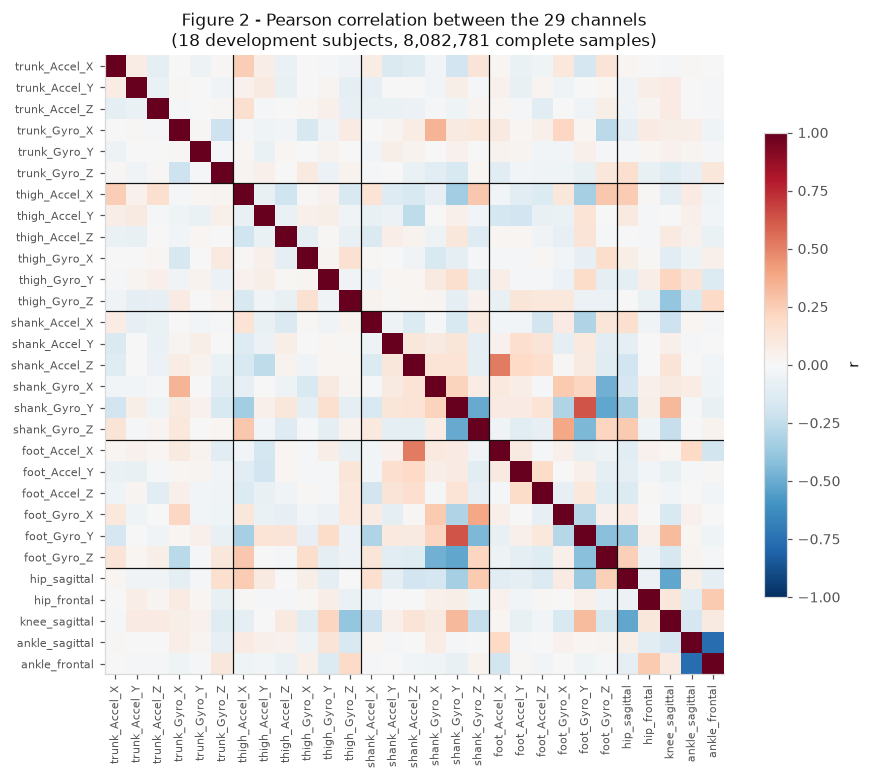

In [9]:
# --- Phase 2.1: Figure 2, correlation between channels ------------------------

CORR_THRESHOLDS = (0.9, 0.8, 0.7, 0.5)

def channel_group(channel):
    """Which sensor a channel belongs to. The four IMUs sit on body segments,
    the goniometers are one instrument measuring five joint angles."""
    return "goniometer" if channel in C.GON_CHANNELS else channel.split("_")[0]

# --- Execution ----------------------------------------------------------------
section("Phase 2.1 - Figure 2")

corr_values = eda_corr.to_numpy()
iu = np.triu_indices(len(eda_corr), k=1)
corr_pairs = pd.DataFrame({
    "a": eda_corr.index[iu[0]], "b": eda_corr.columns[iu[1]],
    "r": corr_values[iu]}).assign(abs_r=lambda d: d["r"].abs())
corr_pairs = corr_pairs.sort_values("abs_r", ascending=False)

groups = [channel_group(ch) for ch in eda_corr.index]
group_sizes = {g: groups.count(g) for g in dict.fromkeys(groups)}
boundaries = np.cumsum(list(group_sizes.values()))[:-1]

print(f"\n  Pearson over the {acc.n:,} complete development rows")
print(f"  channel pairs           : {len(corr_pairs):,}")
for t in CORR_THRESHOLDS:
    print(f"  above |r| = {t:<3}         : {int((corr_pairs['abs_r'] > t).sum())}")
print("\n  strongest pairs")
for _, row in corr_pairs.head(5).iterrows():
    print(f"    {row['a']:<18}{row['b']:<18}{row['r']:>+7.3f}")


fig, ax = plt.subplots(figsize=(8.4, 7))
im = ax.imshow(corr_values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(eda_corr)), eda_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(eda_corr)), eda_corr.index, fontsize=7)
for b in boundaries:
    ax.axhline(b - 0.5, color=TEXT_PRIMARY, linewidth=0.8)
    ax.axvline(b - 0.5, color=TEXT_PRIMARY, linewidth=0.8)
ax.grid(visible=False)
ax.set_title(f"Figure 2 - Pearson correlation between the "
             f"{len(C.ALL_CHANNELS)} channels\n({len(DEV_SUBJECTS)} development "
             f"subjects, {acc.n:,} complete samples)")
fig.colorbar(im, ax=ax, shrink=0.75, label="r")
fig.tight_layout()
fig2_png = save_figure(fig, "fig2_channel_correlation")
plt.show()


Phase 2.1 - class composition per subject

  class                         lowest             highest      spread
  idle                    29.6% (AB17)        41.9% (AB10)     12.3 pp
  walk                    25.2% (AB30)        32.0% (AB25)      6.8 pp
  stair_ascent             4.2% (AB08)         7.4% (AB11)      3.2 pp
  stair_descent            4.0% (AB09)         7.1% (AB11)      3.1 pp
  ramp_ascent             10.4% (AB08)        14.1% (AB17)      3.7 pp
  ramp_descent            10.3% (AB10)        15.5% (AB21)      5.2 pp
saved  Notebook\figures\slide_class_composition_per_subject.png  and  slide_class_composition_per_subject.pdf


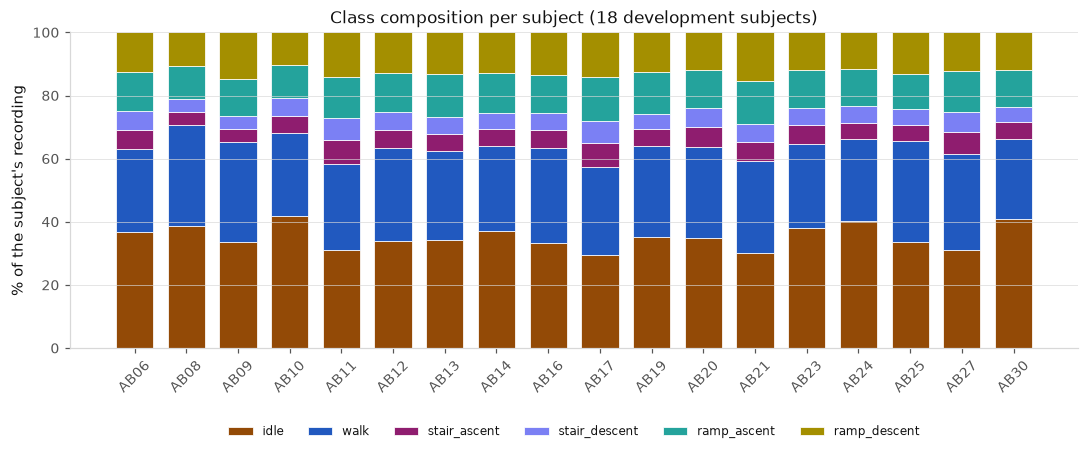

In [10]:
# --- Phase 2.1: class composition per subject ---------------------------------


composition = (per_subject.groupby("subject")[list(C.CLASSES)].sum()
               .pipe(lambda d: 100 * d.div(d.sum(axis=1), axis=0)))

section("Phase 2.1 - class composition per subject")
print(f"\n  {'class':<16}{'lowest':>20}{'highest':>20}{'spread':>12}")
for cls in C.CLASSES:
    lo, hi = composition[cls].idxmin(), composition[cls].idxmax()
    print(f"  {cls:<16}{composition.loc[lo, cls]:>12.1f}% ({lo})"
          f"{composition.loc[hi, cls]:>12.1f}% ({hi})"
          f"{composition.loc[hi, cls] - composition.loc[lo, cls]:>9.1f} pp")


fig, ax = plt.subplots(figsize=(10, 4.4))
bottom = np.zeros(len(composition))
for cls in C.CLASSES:
    ax.bar(composition.index, composition[cls], bottom=bottom,
           color=class_color(cls), label=cls, width=0.72,
           edgecolor=SURFACE, linewidth=0.5)
    bottom += composition[cls].to_numpy()
ax.set_ylabel("% of the subject's recording")
ax.set_ylim(0, 100)
ax.set_title(f"Class composition per subject "
             f"({len(DEV_SUBJECTS)} development subjects)")
ax.legend(ncol=len(C.CLASSES), loc="lower center", bbox_to_anchor=(0.5, -0.32),
          fontsize=8)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", visible=False)
fig.tight_layout()
slide_png = save_figure(fig, "slide_class_composition_per_subject")
plt.show()


The channels are close to independent: the only pair above the highest threshold
is the two axes of one ankle goniometer, so there is no redundancy worth
exploiting and no channel is dropped before the pipeline can judge it. The
classes are uneven — the two stair activities take the smallest share, and that
share changes from subject to subject, so every fold trains and tests on a
slightly different mixture.

---

## Part 3 — Windows, features and feature selection

### 3.1 From samples to windows

A row stops being five milliseconds of sensor and becomes a quarter of a second
of movement. Windows are 250 ms long, start every 125 ms, and take the majority
label of their samples, ties going to the last one. Two constraints are
structural: a window never crosses a trial boundary — stitching two recordings
would invent transitions that never happened — and every window carries its
subject, the key leave-one-subject-out groups on. Windows holding an invalid
sample are dropped, the decision §1.3 measured.

Rebalancing does **not** happen here. 

In [11]:
# --- Phase 3.1: windowing the 18 development subjects -------------------------

import json
from datetime import datetime
from numpy.lib.stride_tricks import sliding_window_view

WIN = C.WINDOW_SAMPLES          # 50 samples = 250 ms
STRIDE = C.STRIDE_SAMPLES_CV    # 25 samples = 125 ms — rule 14, never C.STRIDE_SAMPLES
WINDOW_INDEX_PATH = WINDOWS_DIR / "window_index.parquet"
WINDOW_META_PATH = WINDOWS_DIR / "window_index_meta.json"


def windows_of_trial(g, codes):
    """Every window of one trial, labelled by the majority of its 50 samples.

    Vectorised with `sliding_window_view`: a Python loop over 300,000 windows
    would be slow for no reason. Windows are cut inside a single trial and never
    across two, which is why this works on one trial at a time — trials are
    separate recordings, and stitching them would invent transitions that never
    happened. Returns (index rows, counters); rows is None when the trial is
    shorter than a window or when every position is invalid.
    """
    counters = {"positions": 0, "discarded": 0, "ties": 0, "short": 0}
    n = len(g)
    if n < WIN:
        counters["short"] = 1
        return None, counters

    X = g[C.ALL_CHANNELS].to_numpy(dtype=float)
    valid = C.valid_mask(X, C.ALL_CHANNELS).all(axis=1)
    code = np.array([codes.get(str(x), -1) for x in g["label"].to_numpy()],
                    dtype=np.int16)
    if (code == -1).any():
        raise ValueError(f"label outside C.CLASSES in {g['trial_id'].iloc[0]}")
    trans = g["is_transition"].to_numpy().astype(bool)
    header = g["Header"].to_numpy(dtype=float)

    starts = np.arange(0, n - WIN + 1, STRIDE)
    W_code = sliding_window_view(code, WIN)[starts]
    W_valid = sliding_window_view(valid, WIN)[starts]
    W_trans = sliding_window_view(trans, WIN)[starts]

    # One invalid sample drops the window: imputing a sensor fault would
    # invent data, and 1.3 measured that the cost is negligible.
    keep = W_valid.all(axis=1)
    counters["positions"] = int(len(starts))
    counters["discarded"] = int((~keep).sum())
    if not keep.any():
        return None, counters
    starts, W_code, W_trans = starts[keep], W_code[keep], W_trans[keep]

    counts = np.stack([(W_code == k).sum(axis=1) for k in range(len(codes))],
                      axis=1)
    winner = counts.argmax(axis=1)
    top = counts.max(axis=1)
    tied = (counts == top[:, None]).sum(axis=1) > 1
    last = W_code[:, -1]
    # Ties go to the last sample: deterministic, and consistent with reading
    # the window as "what is happening now".
    winner = np.where(tied, last, winner)
    counters["ties"] = int(tied.sum())

    frac_trans = W_trans.mean(axis=1)
    name = {i: c for c, i in codes.items()}
    return pd.DataFrame({
        "start": starts,
        "t_start": header[starts],
        "t_end": header[starts + WIN - 1],
        "label": [name[int(v)] for v in winner],
        # The alternative rule, kept so the choice can be measured later.
        "label_last": [name[int(v)] for v in last],
        "purity": top / WIN,
        "tie": tied,
        "frac_transition": frac_trans,
        "is_transition": frac_trans > 0.5,
        "n_distinct_labels": (counts > 0).sum(axis=1),
    }), counters


# --- Execution ----------------------------------------------------------------
section(f"Phase 3.1 - windowing {len(DEV_SUBJECTS)} development subjects")

codes = {c: i for i, c in enumerate(C.CLASSES)}
window_cols = (["subject", "mode", "trial_id", "Header", "label", "is_transition"]
               + C.ALL_CHANNELS)

window_meta = (json.loads(WINDOW_META_PATH.read_text(encoding="utf-8"))
               if WINDOW_META_PATH.exists() and WINDOW_INDEX_PATH.exists() else {})
reusable = (window_meta.get("window_samples") == WIN
            and window_meta.get("stride_samples") == STRIDE
            and window_meta.get("classes") == list(C.CLASSES)
            and window_meta.get("subjects") == sorted(DEV_SUBJECTS))

if reusable:
    windows_dev = pd.read_parquet(WINDOW_INDEX_PATH)
    checkpoint_note(WINDOW_INDEX_PATH, len(windows_dev), "windows")
else:
    if window_meta:
        print("  index on disk was built with other parameters -> rebuilding")
    from tqdm.auto import tqdm
    parts, tot = [], {"positions": 0, "discarded": 0, "ties": 0, "short": 0}
    n_trials = n_samples_scanned = 0
    samples_by_class = {}

    for fp in tqdm([PARQUET_DIR / f"{s}__{m}.parquet"
                    for s in DEV_SUBJECTS for m in C.MODES],
                   desc="windowing", unit="file"):
        subject, mode = fp.stem.split("__")
        df = pd.read_parquet(fp, columns=window_cols)
        n_samples_scanned += len(df)
        for cls, k in df["label"].value_counts().items():
            samples_by_class[str(cls)] = samples_by_class.get(str(cls), 0) + int(k)

        for trial_id, g in df.groupby("trial_id", sort=True):
            n_trials += 1
            rows, counters = windows_of_trial(g.sort_values("Header"), codes)
            for k, v in counters.items():
                tot[k] += v
            if rows is None:
                continue
            rows.insert(0, "trial_id", trial_id)
            rows.insert(0, "mode", mode)
            rows.insert(0, "subject", subject)
            parts.append(rows)

    windows_dev = pd.concat(parts, ignore_index=True)
    window_meta = {
        "created": datetime.now().isoformat(timespec="seconds"),
        "generated_by": "notebook, phase 3.1",
        "window_ms": C.WINDOW_MS, "window_samples": WIN,
        "stride_ms": C.STRIDE_MS_CV, "stride_samples": STRIDE,
        "fs_hz": C.FS_TARGET_HZ,
        "label_rule": "mode of the samples; ties go to the last one",
        "discard_rule": "window dropped if any sample is invalid (C.valid_mask)",
        "limits": {"gon_deg": C.GON_LIMIT_DEG, "accel_g": C.ACCEL_LIMIT_G,
                   "gyro_rads": C.GYRO_LIMIT_RADS},
        "classes": list(C.CLASSES),
        "subjects": sorted(DEV_SUBJECTS),
        "n_windows": int(len(windows_dev)),
        "n_positions": int(tot["positions"]),
        "n_discarded": int(tot["discarded"]),
        "n_ties": int(tot["ties"]),
        "n_short_trials": int(tot["short"]),
        "n_trials": int(n_trials),
        "n_samples": int(n_samples_scanned),
        "samples_by_class": samples_by_class,
    }
    windows_dev.to_parquet(WINDOW_INDEX_PATH, index=False)
    WINDOW_META_PATH.write_text(json.dumps(window_meta, indent=2), encoding="utf-8")

# Read back from the signature, so a reloaded run and a fresh one are checked
# against the same numbers.
n_win_positions_dev = window_meta["n_positions"]
n_win_discarded_dev = window_meta["n_discarded"]
n_trials_dev = window_meta["n_trials"]
n_samples_dev = window_meta["n_samples"]
dev_samples_by_class = window_meta["samples_by_class"]

per_subject_class = (windows_dev.groupby(["subject", "label"]).size()
                     .unstack(fill_value=0)
                     .reindex(columns=C.CLASSES, fill_value=0))
windows_by_class = windows_dev["label"].value_counts()
ps = per_subject_class.sum(axis=1)

print(f"\n  windows produced   : {len(windows_dev):,} from {n_win_positions_dev:,}"
      f" positions over {n_trials_dev:,} trials")
print(f"  discarded, invalid : {n_win_discarded_dev:,}"
      f" ({100 * n_win_discarded_dev / n_win_positions_dev:.4f}%);"
      f" trials shorter than a window: {window_meta['n_short_trials']}")
print(f"  1.3 counted {win_tot:,} positions and {win_bad:,} invalid ones"
      f" over all {len(inv)} subjects")
print(f"  per subject        : min {ps.min():,} | median {ps.median():,.0f}"
      f" | max {ps.max():,}")

# Does the majority rule cost the rare classes? A class living in short runs
# can lose ground when 50 samples have to agree on one label.
print(f"\n  {'class':<16}{'% samples':>12}{'% windows':>12}{'shift':>9}")
for cls in C.CLASSES:
    a = 100 * dev_samples_by_class.get(cls, 0) / n_samples_dev
    b = 100 * windows_by_class.get(cls, 0) / len(windows_dev)
    print(f"  {cls:<16}{a:>11.2f}%{b:>11.2f}%{b - a:>+9.2f}")
print(f"  {'imbalance':<16}"
      f"{max(dev_samples_by_class.values()) / min(dev_samples_by_class.values()):>11.1f}x"
      f"{windows_by_class.max() / windows_by_class.min():>11.1f}x")

p = windows_dev["purity"]
diverge = windows_dev["label"] != windows_dev["label_last"]
print(f"\n  purity: 1.00 in {100 * (p == 1).mean():.1f}% of windows,"
      f" >=0.90 in {100 * (p >= 0.9).mean():.1f}%,"
      f" <0.60 in {100 * (p < 0.6).mean():.1f}%, min {p.min():.2f}")
print(f"  ties broken by the last sample : {window_meta['n_ties']:,}"
      f" ({100 * window_meta['n_ties'] / len(windows_dev):.4f}%)")
print(f"  mode and last-sample rules disagree : {int(diverge.sum()):,}"
      f" ({100 * diverge.mean():.2f}%), median purity there"
      f" {windows_dev.loc[diverge, 'purity'].median():.2f}")
print(f"  transition windows : {int(windows_dev['is_transition'].sum()):,}"
      f" ({100 * windows_dev['is_transition'].mean():.2f}%)")
print(f"  (subject, class) pairs with no window : "
      f"{int((per_subject_class == 0).to_numpy().sum())}")


Phase 3.1 - windowing 18 development subjects
  checkpoint found: window_index.parquet -> reusing 319,651 windows already computed; they will not be recomputed

  windows produced   : 319,651 from 319,758 positions over 2,440 trials
  discarded, invalid : 107 (0.0335%); trials shorter than a window: 0
  1.3 counted 392,292 positions and 118 invalid ones over all 22 subjects
  per subject        : min 14,107 | median 17,769 | max 20,117

  class              % samples   % windows    shift
  idle                  35.32%      34.63%    -0.69
  walk                  28.48%      28.76%    +0.28
  stair_ascent           5.71%       5.77%    +0.06
  stair_descent          5.47%       5.53%    +0.06
  ramp_ascent           12.28%      12.41%    +0.13
  ramp_descent          12.73%      12.89%    +0.16
  imbalance               6.5x        6.3x

  purity: 1.00 in 92.7% of windows, >=0.90 in 94.2%, <0.60 in 1.3%, min 0.50
  ties broken by the last sample : 472 (0.1477%)
  mode and last-sample ru

The risk was that a class
living in short runs would struggle to be the majority of a quarter of a second,
costing ground where the data is already thin. The largest shift is under one
percentage point, it falls on `idle`, and all four rare classes gain share — the
imbalance ratio drops. Transitions last long enough to fill windows of their own
instead of being crushed inside somebody else's.

True ties are a fraction of a percent, and the two candidate rules disagree only
at the edge of the transitions. `label_last` stays in the index so the question
can be answered later with a number. One fact matters for the protocol: no
(subject, class) pair was left without windows, so every fold can score all six
classes.

### 3.2 Features

A window becomes a vector: 15 statistics over 37 channels, 555 features. Ten
statistics describe the window in the time domain, two its dynamics — mean
absolute difference and energy of the first difference, both blind to a constant
offset — and three the share of spectral energy in a band. The 37 channels are
the 29 recorded ones plus, per IMU segment, the magnitude of acceleration and of
angular velocity: a magnitude does not depend on how the sensor was rotated on
the limb.




In [12]:
# --- Phase 3.2: features for the 18 development subjects ----------------------


import time
from tqdm.auto import tqdm

BANDS = [("blo", 0.0, 10.0), ("bmid", 10.0, 25.0), ("bhi", 25.0, np.inf)]
STATS = ["mean", "std", "min", "max", "range", "rms", "median", "iqr",
         "skew", "kurt", "mad_diff", "denergy"] + [b[0] for b in BANDS]
CHANNELS = C.ALL_CHANNELS + [f"{seg}_{kind}Mag" for seg in C.IMU_SEGMENTS
                             for kind in ("Accel", "Gyro")]
FEATURE_NAMES = [f"{ch}__{st}" for ch in CHANNELS for st in STATS]
FEATURE_META_COLS = ["subject", "mode", "trial_id", "start", "t_start", "t_end",
                     "label", "is_transition", "frac_transition", "purity"]
FEATURES_META_PATH = FEATURES_DIR / "features_meta.json"
N_PROBES = 200                 # windows recomputed through a different code path


def add_magnitudes(A):
    """From (n, 29) to (n, 37): |accel| and |gyro| for each IMU segment.

    A vector magnitude does not depend on how the sensor was rotated on the
    limb, which is the entire reason these eight channels exist.
    """
    cols = [A]
    for seg in C.IMU_SEGMENTS:
        for kind in ("Accel", "Gyro"):
            j = [C.ALL_CHANNELS.index(f"{seg}_{kind}_{ax}") for ax in "XYZ"]
            cols.append(np.sqrt((A[:, j] ** 2).sum(axis=1, keepdims=True)))
    return np.hstack(cols)


def block_features(X, band_masks, ac_bins):
    """The 15 statistics for a block of windows, X of shape (n_win, w, n_ch).

    Returns (n_win, n_ch * 15) laid out channel by channel — the order of
    FEATURE_NAMES — and the per-channel count of constant windows.
    """
    mean, std = X.mean(axis=1), X.std(axis=1)
    mn, mx = X.min(axis=1), X.max(axis=1)
    q75, q25 = np.percentile(X, [75, 25], axis=1)

    # std == 0: the window never moved, so skew and kurt are 0/0. Zero is the
    # right value for a degenerate distribution, and the cases are counted.
    constant = std == 0
    z = (X - mean[:, None, :]) / np.where(constant, 1.0, std)[:, None, :]
    skew = np.where(constant, 0.0, (z ** 3).mean(axis=1))
    kurt = np.where(constant, 0.0, (z ** 4).mean(axis=1) - 3.0)

    # From the first difference: blind to a constant offset, so a sensor at a
    # different resting value cannot fake them.
    d = np.diff(X, axis=1)

    # Bands as shares of the non-DC energy. The DC bin is the mean, which is
    # already a feature of its own.
    P = np.abs(np.fft.rfft(X, axis=1)) ** 2
    total = P[:, ac_bins, :].sum(axis=1)
    bands = [P[:, m, :].sum(axis=1) / np.where(total == 0, 1.0, total)
             for m in band_masks]

    parts = [mean, std, mn, mx, mx - mn, np.sqrt((X ** 2).mean(axis=1)),
             np.median(X, axis=1), q75 - q25, skew, kurt,
             np.abs(d).mean(axis=1), (d ** 2).mean(axis=1), *bands]
    F = np.stack(parts, axis=2)                       # (n_win, n_ch, 15)
    return F.reshape(len(X), -1), constant.sum(axis=0)


def features_of_subject(subject, idx_sub, band_masks, ac_bins):
    """One subject's feature matrix, in the index's own row order."""
    feats, metas = [], []
    constant = np.zeros(len(CHANNELS), dtype=np.int64)
    last_mode, df = None, None
    # sort=False keeps the index order, so the file is row-for-row aligned with
    # `windows_dev` and the check below compares positions, not just counts.
    for (mode, trial_id), idx_tr in idx_sub.groupby(["mode", "trial_id"],
                                                    sort=False):
        if mode != last_mode:
            df = pd.read_parquet(PARQUET_DIR / f"{subject}__{mode}.parquet",
                                 columns=["trial_id", "Header"] + C.ALL_CHANNELS)
            last_mode = mode
        g = df[df["trial_id"] == trial_id].sort_values("Header")
        A = add_magnitudes(g[C.ALL_CHANNELS].to_numpy(dtype=np.float64))

        # The index positions, in its order: features and labels must describe
        # the same 250 ms.
        starts = idx_tr["start"].to_numpy()
        view = sliding_window_view(A, WIN, axis=0)        # (n-w+1, n_ch, w)
        X = np.transpose(view[starts], (0, 2, 1))         # (n_win, w, n_ch)

        F, n_const = block_features(X, band_masks, ac_bins)
        feats.append(F.astype(np.float32))
        metas.append(idx_tr[FEATURE_META_COLS])
        constant += n_const

    return pd.concat([pd.concat(metas, ignore_index=True),
                      pd.DataFrame(np.vstack(feats), columns=FEATURE_NAMES)],
                     axis=1), constant


# --- Execution ----------------------------------------------------------------
section(f"Phase 3.2 - features for {len(DEV_SUBJECTS)} development subjects")

freqs = np.fft.rfftfreq(WIN, d=1.0 / C.FS_TARGET_HZ)
ac_bins = freqs > 0
band_masks = [(freqs > lo) & (freqs <= hi) & ac_bins for _, lo, hi in BANDS]

# The risk is not wrong positions, it is an OLD index: features computed on
# last week's stride would raise nothing and still count right.
index_signature = {k: window_meta[k] for k in
                   ("created", "window_samples", "stride_samples", "n_windows")}
prev = (json.loads(FEATURES_META_PATH.read_text(encoding="utf-8"))
        if FEATURES_META_PATH.exists() else {})
if prev.get("index") == index_signature and prev.get("n_features") == len(FEATURE_NAMES):
    done = {s: n for s, n in prev["rows_by_subject"].items()
            if (FEATURES_DIR / f"features__{s}.parquet").exists()}
    constant_by_channel = np.array(prev["constant_by_channel"], dtype=np.int64)
else:
    if prev:
        print("  features on disk were built from another index -> rebuilding")
    done, constant_by_channel = {}, np.zeros(len(CHANNELS), dtype=np.int64)

print(f"  index accepted: {window_meta['n_windows']:,} windows,"
      f" stride {window_meta['stride_samples']}, built {window_meta['created']}")
if done:
    checkpoint_note(FEATURES_META_PATH, len(done), "subjects")

t0, n_built = time.time(), 0
for s in tqdm(DEV_SUBJECTS, desc="features", unit="subject"):
    if s in done:
        continue
    out, n_const = features_of_subject(
        s, windows_dev[windows_dev["subject"] == s], band_masks, ac_bins)
    out.to_parquet(FEATURES_DIR / f"features__{s}.parquet",
                   index=False, compression="snappy")
    done[s] = int(len(out))
    constant_by_channel = constant_by_channel + n_const
    n_built += 1
    # Rewritten after every subject, so an interrupted run resumes here.
    FEATURES_META_PATH.write_text(json.dumps(
        {"index": index_signature, "n_features": len(FEATURE_NAMES),
         "rows_by_subject": done,
         "constant_by_channel": constant_by_channel.tolist()}, indent=2),
        encoding="utf-8")
t_build = time.time() - t0

# --- Reading everything back: the checks below never trust the build path -----
n_rows = n_nonfinite = n_misplaced = n_cols_wrong = 0
disk_mb = 0.0
for s in DEV_SUBJECTS:
    fp = FEATURES_DIR / f"features__{s}.parquet"
    disk_mb += fp.stat().st_size / 1e6
    d = pd.read_parquet(fp)
    idx_s = windows_dev[windows_dev["subject"] == s]
    n_rows += len(d)
    n_cols_wrong += int([c for c in d.columns if "__" in c] != FEATURE_NAMES)
    if len(d) != len(idx_s):
        n_misplaced += abs(len(d) - len(idx_s))
    else:
        for col in ("start", "trial_id", "label"):
            n_misplaced += int((d[col].to_numpy() != idx_s[col].to_numpy()).sum())
    n_nonfinite += int((~np.isfinite(d[FEATURE_NAMES].to_numpy())).sum())

print(f"\n  matrix        : {n_rows:,} x {len(FEATURE_NAMES)}"
      f"   ({len(CHANNELS)} channels x {len(STATS)} statistics)")
print(f"  on disk       : {disk_mb:,.0f} MB in {len(done)} files"
      f" | in RAM as float32: {n_rows * len(FEATURE_NAMES) * 4 / 1e6:,.0f} MB")
print(f"  build time    : {t_build:.0f} s for {n_built} subject(s) computed now")

n_cells = n_rows * len(CHANNELS)
print(f"\n  constant window-channels (std = 0): {int(constant_by_channel.sum()):,}"
      f" of {n_cells:,} ({100 * constant_by_channel.sum() / n_cells:.4f}%),"
      f" skew and kurt set to 0 there")
for i in np.argsort(-constant_by_channel)[:3]:
    if constant_by_channel[i]:
        print(f"    {CHANNELS[i]:<16}{int(constant_by_channel[i]):>7,}"
              f"  ({100 * constant_by_channel[i] / n_rows:.3f}% of its own)")

# The row count is tautological — it counts the rows we asked for, and would
# survive transposed axes or slices off by one. So a sample is rebuilt from the
# raw Parquet with iloc and plain NumPy, labels and tie-break included.
rng = np.random.default_rng(C.RANDOM_SEED)
probes = (windows_dev
          .iloc[np.sort(rng.choice(len(windows_dev), N_PROBES, replace=False))]
          .sort_values(["subject", "mode", "trial_id"]))
probe_channels = ["knee_sagittal", "trunk_Accel_X", "foot_Gyro_Z", "shank_AccelMag"]
n_compared = n_label_bad = 0
worst_deviation = 0.0
feat_subject = raw_key = None

for _, r in probes.iterrows():
    s, mode, trial, start = r["subject"], r["mode"], r["trial_id"], int(r["start"])
    if s != feat_subject:
        F = pd.read_parquet(FEATURES_DIR / f"features__{s}.parquet")
        feat_subject = s
    row = F[(F["mode"] == mode) & (F["trial_id"] == trial) & (F["start"] == start)]
    if len(row) != 1:
        raise ValueError(f"{s}/{mode}/{trial}/{start}: {len(row)} rows, expected 1")
    row = row.iloc[0]

    if (s, mode) != raw_key:
        raw = pd.read_parquet(PARQUET_DIR / f"{s}__{mode}.parquet",
                              columns=["trial_id", "Header", "label"] + C.ALL_CHANNELS)
        raw_key = (s, mode)
    sl = raw[raw["trial_id"] == trial].sort_values("Header").iloc[start:start + WIN]
    if len(sl) != WIN:
        raise ValueError(f"{s}/{mode}/{trial}/{start}: slice of {len(sl)} samples")

    vc = sl["label"].value_counts()
    expected_label = (vc.index[0] if len(vc) == 1 or vc.iloc[0] > vc.iloc[1]
                      else sl["label"].iloc[-1])
    n_label_bad += int(row["label"] != expected_label)

    for ch in probe_channels:
        if ch in C.ALL_CHANNELS:
            v = sl[ch].to_numpy(dtype=np.float64)
        else:
            seg, kind = ch.split("_")[0], ch.split("_")[1].replace("Mag", "")
            v = np.sqrt(sum(sl[f"{seg}_{kind}_{a}"].to_numpy(dtype=np.float64) ** 2
                            for a in "XYZ"))
        for st, expected in (("mean", v.mean()), ("std", v.std()),
                             ("max", v.max()), ("median", np.median(v))):
            got = float(row[f"{ch}__{st}"])
            worst_deviation = max(worst_deviation,
                                  abs(got - expected) / max(abs(expected), 1e-6))
            n_compared += 1

print(f"\n  independent recomputation: {len(probes)} windows,"
      f" {n_compared:,} comparisons")
print(f"  worst relative deviation : {worst_deviation:.2e}"
      f" | labels disagreeing: {n_label_bad}")



Phase 3.2 - features for 18 development subjects
  index accepted: 319,651 windows, stride 25, built 2026-08-23T10:45:32
  checkpoint found: features_meta.json -> reusing 18 subjects already computed; they will not be recomputed


features: 100%|██████████| 18/18 [00:00<00:00, 14027.77subject/s]


  matrix        : 319,651 x 555   (37 channels x 15 statistics)
  on disk       : 1,018 MB in 18 files | in RAM as float32: 710 MB
  build time    : 0 s for 0 subject(s) computed now

  constant window-channels (std = 0): 2,012 of 11,827,087 (0.0170%), skew and kurt set to 0 there
    thigh_Gyro_X      1,002  (0.313% of its own)
    trunk_Gyro_X        348  (0.109% of its own)
    trunk_Gyro_Z        314  (0.098% of its own)

  independent recomputation: 200 windows, 3,200 comparisons
  worst relative deviation : 5.83e-08 | labels disagreeing: 0


**The features describe the windows they claim to describe, and this is
verified rather than assumed.** Counting rows written against windows expected
would stay true if the axes were transposed or every slice were off by one
sample. So a random sample of windows is rebuilt from the raw Parquet through a
different code path — plain slicing, plain NumPy — and compared. The worst
disagreement is at the precision limit of `float32` and no label differs, which
covers window positions, axis orientation, derived-channel order, the
feature-to-column mapping and the window-label join.



### 3.3 Feature selection

**No reduced dataset leaves this phase.** Choosing the best features on all the
data would be leakage in its purest form: the choice would have seen the labels
of every validation fold. What is built instead is one ranking **per fold**. The
eighteen folds are defined here — leave one subject out, `idle` undersampled on
the training side only — and in each the 555 features are ranked by mutual
information with the class, estimated on that fold's training rows and nothing
else.

On all of those rows rather than a subsample: the estimator counts nearest
neighbours, so its bias depends on how many rows it is given, and a subsample
would produce a different ranking rather than a noisier version of the same one.

`k` is not decided here either — it enters §3.4 as a hyperparameter over
{75, 150, 350}. The ranking is reported on as well as produced: identical
rankings across folds would mean a selector saw more than its own training rows,
while a top that changed wholesale would mean §3.4 is fitting one particular set
of seventeen people. Overlap is therefore measured against chance, since two
random choices of `k` out of 555 already agree on `k`/555 of them.

In [13]:
# --- Phase 3.3: the folds and their mutual information ranking ----------------

from sklearn.feature_selection import mutual_info_classif

MI_ROWS = "all"                # every training row of the fold, not a subsample
MI_PATH = CKPT_DIR / "10_mi_per_fold.csv"
STABILITY_K = [20, 50, 75, 150, 350]
STABILITY_FLOOR = 0.5          # fixed in advance, before any of this was run


def undersample_idle(labels, fraction, rng):
    """Row indices to keep. Touches `idle` only; every other class is left
    whole. Applied to training rows exclusively — removing `idle` from a
    validation fold would score a world where standing still takes a fifth of
    the time instead of a third."""
    idle = np.flatnonzero(labels == "idle")
    other = np.flatnonzero(labels != "idle")
    keep = rng.permutation(idle)[:int(round(len(idle) * fraction))]
    return np.sort(np.concatenate([other, keep]))


def stability(sets, k, n_total):
    """Overlap between the folds' top `k`, normalised against chance.

    Raw overlap is not comparable across values of `k`: two random choices of
    `k` features out of `n_total` already agree on k*k/n_total of them. The
    normalised index is 0 for a random selection and 1 for one identical in
    every fold, whatever `k` is.
    """
    by_chance = k * k / n_total
    observed = float(np.mean([len(a & b) for i, a in enumerate(sets)
                              for b in sets[i + 1:]]))
    return (observed - by_chance) / (k - by_chance), observed, by_chance


# --- The design matrix --------------------------------------------------------
section(f"Phase 3.3 - {len(DEV_SUBJECTS)} folds and their MI ranking")

# Preallocated and filled subject by subject: concatenating would hold two
# copies of 710 MB at once.
X = np.empty((len(windows_dev), len(FEATURE_NAMES)), dtype=np.float32)
y_parts, group_parts, at = [], [], 0
for s in tqdm(DEV_SUBJECTS, desc="loading", unit="subject"):
    d = pd.read_parquet(FEATURES_DIR / f"features__{s}.parquet",
                        columns=FEATURE_NAMES + ["label", "subject"])
    X[at:at + len(d)] = d[FEATURE_NAMES].to_numpy(dtype=np.float32)
    y_parts.append(d["label"].to_numpy())
    group_parts.append(d["subject"].to_numpy())
    at += len(d)
y = np.concatenate(y_parts).astype(str)
groups = np.concatenate(group_parts).astype(str)
del y_parts, group_parts, d
print(f"  matrix {X.shape[0]:,} x {X.shape[1]}  ({X.nbytes / 1e6:,.0f} MB)")

# --- Folds and mutual information ---------------------------------------------
# Estimated on the raw training rows: the estimator standardises each feature
# internally, so scaling here would only cost memory. The scaler belongs to the
# model pipeline, fitted per fold in §3.4.
mi = pd.read_csv(MI_PATH, index_col=0) if MI_PATH.exists() else None
if mi is None or list(mi.index) != FEATURE_NAMES:
    if mi is not None:
        print("  MI on disk does not match these feature names -> recomputing")
    mi = pd.DataFrame(index=FEATURE_NAMES)
cached = [s for s in DEV_SUBJECTS if s in mi.columns]
if cached:
    checkpoint_note(MI_PATH, len(cached), "folds")

fold_train, fold_val = [], []
for subject in tqdm(DEV_SUBJECTS, desc="folds", unit="fold"):
    # A fresh generator per fold: a training set must not depend on how many
    # folds ran before it.
    rng = np.random.default_rng(C.RANDOM_SEED)
    tr = np.flatnonzero(groups != subject)
    tr = tr[undersample_idle(y[tr], C.IDLE_KEEP_FRACTION, rng)]
    fold_train.append(tr)
    fold_val.append(np.flatnonzero(groups == subject))

    if subject not in mi.columns:
        # Every training row, not a subsample. The k-nearest-neighbour
        # estimator is biased by construction and the bias depends on n, so a
        # subsample gives a different ranking rather than a noisier one — it
        # underrates the order statistics `__min` and `__max` above all. About
        # 70 s per fold, paid once and then frozen.
        mi[subject] = mutual_info_classif(X[tr], y[tr],
                                          random_state=C.RANDOM_SEED, n_jobs=-1)
        mi.to_csv(MI_PATH)          # the CSV is the checkpoint, not a log

mi = mi[DEV_SUBJECTS]
mi_order = {s: np.argsort(-mi[s].to_numpy()) for s in DEV_SUBJECTS}

train_sizes = np.array([len(t) for t in fold_train])
val_sizes = np.array([len(v) for v in fold_val])
idle_share_train = float(np.mean([(y[t] == "idle").mean() for t in fold_train]))
print(f"\n  training rows per fold : {train_sizes.min():,} - {train_sizes.max():,}"
      f"   validation: {val_sizes.min():,} - {val_sizes.max():,}")
print(f"  `idle` share           : {100 * (y == 'idle').mean():.1f}% of the"
      f" matrix -> {100 * idle_share_train:.1f}% of training rows")

# --- Can the ranking be trusted? ----------------------------------------------
print(f"\n  {'k':>6}{'by chance':>12}{'observed':>11}{'index':>9}{'verdict':>10}")
for k in STABILITY_K:
    sets = [set(mi_order[s][:k].tolist()) for s in DEV_SUBJECTS]
    index, observed, by_chance = stability(sets, k, len(FEATURE_NAMES))
    print(f"  {k:>6}{by_chance:>12.1f}{observed:>11.1f}{index:>9.3f}"
          f"{'stable' if index >= STABILITY_FLOOR else 'UNSTABLE':>10}")

tops20 = [set(mi_order[s][:20].tolist()) for s in DEV_SUBJECTS]
pair_overlap = [len(a & b) for i, a in enumerate(tops20) for b in tops20[i + 1:]]
# Two folds agreeing on their best twenty is stability, not a leak: had the
# selector seen the whole dataset, the ENTIRE ranking would be identical.
n_identical_full = sum(1 for i, a in enumerate(DEV_SUBJECTS)
                       for b in DEV_SUBJECTS[i + 1:]
                       if np.array_equal(mi_order[a], mi_order[b]))
in_top50 = np.bincount(np.concatenate([mi_order[s][:50] for s in DEV_SUBJECTS]),
                       minlength=len(FEATURE_NAMES))
n_always = int((in_top50 == len(DEV_SUBJECTS)).sum())
print(f"\n  top-20 overlap between folds: min {min(pair_overlap)},"
      f" median {int(np.median(pair_overlap))}, max {max(pair_overlap)}"
      f" | identical rankings {n_identical_full}")
print(f"  {n_always} features are in the top 50 of all {len(DEV_SUBJECTS)} folds"
      f" | highest mean MI: {mi.mean(axis=1).idxmax()}")

# Undersampling recomputed from y and groups, independently of the loop above.
n_nonidle_dropped = n_rate_off = 0
for subject, tr in zip(DEV_SUBJECTS, fold_train):
    full = y[groups != subject]
    n_nonidle_dropped += int((full != "idle").sum() - (y[tr] != "idle").sum())
    n_rate_off += int((y[tr] == "idle").sum()
                      != round((full == "idle").sum() * C.IDLE_KEEP_FRACTION))



Phase 3.3 - 18 folds and their MI ranking


loading: 100%|██████████| 18/18 [00:01<00:00, 16.05subject/s]


  matrix 319,651 x 555  (710 MB)
  checkpoint found: 10_mi_per_fold.csv -> reusing 18 folds already computed; they will not be recomputed


folds: 100%|██████████| 18/18 [00:00<00:00, 37.25fold/s]



  training rows per fold : 236,795 - 242,013   validation: 14,107 - 20,117
  `idle` share           : 34.6% of the matrix -> 17.5% of training rows

       k   by chance   observed    index   verdict
      20         0.7       20.0    1.000    stable
      50         4.5       48.7    0.972    stable
      75        10.1       74.0    0.985    stable
     150        40.5      147.0    0.973    stable
     350       220.7      348.5    0.988    stable

  top-20 overlap between folds: min 20, median 20, max 20 | identical rankings 0
  46 features are in the top 50 of all 18 folds | highest mean MI: shank_Accel_X__max


 No two folds
produced the same ordering, which is the evidence that each selector saw only
its own seventeen subjects. But at every `k` the overlap sits far above the
floor fixed in advance and rises as `k` grows, and a core of features appears in
the top fifty of every fold — so "keep the best `k`" means something specific in
each fold and comparable across folds.

The feature with the highest average mutual information is a joint angle.
Whether that survives aggregation per channel is what the figure below answers,
and the answer redraws the line: not between goniometers and inertial sensors,
but between the sagittal plane and the frontal one.

Phase 3.3 - Figure 3
saved  Notebook\figures\fig3_feature_importance.png  and  fig3_feature_importance.pdf

  top 20 features : 2 goniometer, 18 IMU
  leading feature : shank_Accel_X__max  mean 0.2906  (folds 0.2874 - 0.2966)
  leading channel : foot_Accel_X  1.765

  sensor group    channels   mean per channel
  shank                  8              1.356
  foot                   8              1.287
  goniometer             5              1.274
  thigh                  8              1.210
  trunk                  8              1.165


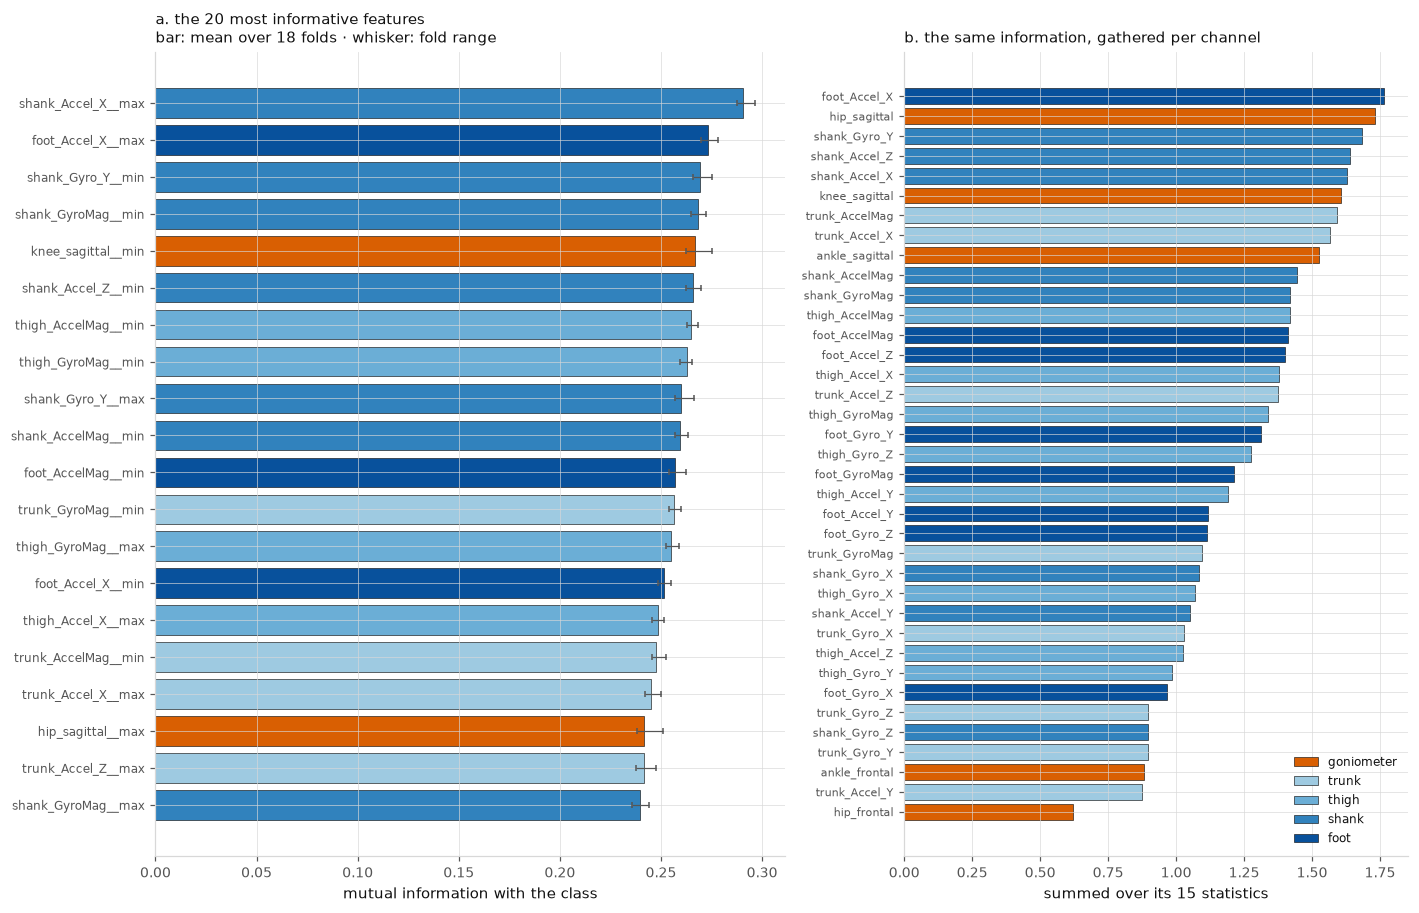

In [14]:
# --- Phase 3.3: Figure 3, where the information sits --------------------------

SENSOR_COLORS = {"goniometer": "#d95f02", "trunk": "#9ecae1",
                 "thigh": "#6baed6", "shank": "#3182bd", "foot": "#08519c"}
N_TOP_FEATURES = 20

# Mean across folds, with the fold-to-fold range kept: a feature that leads on
# average but collapses on one subject is not the same thing as a steady one.
mi_mean, mi_lo, mi_hi = mi.mean(axis=1), mi.min(axis=1), mi.max(axis=1)
channel_of = pd.Series([f.split("__")[0] for f in FEATURE_NAMES],
                       index=FEATURE_NAMES)
top_features = mi_mean.sort_values(ascending=False).head(N_TOP_FEATURES)

# Per channel: the total information its fifteen statistics carry. Every channel
# has exactly fifteen, so the sum ranks them the same way the mean would.
per_channel = mi_mean.groupby(channel_of).sum().sort_values(ascending=False)

# --- The figure ---------------------------------------------------------------
section("Phase 3.3 - Figure 3")

fig, axes = plt.subplots(1, 2, figsize=(13, 8.4),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
y_feat = np.arange(len(top_features))[::-1]
ax.barh(y_feat, top_features.to_numpy(),
        color=[SENSOR_COLORS[channel_group(c)]
               for c in channel_of[top_features.index]],
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
ax.errorbar(top_features.to_numpy(), y_feat,
            xerr=[top_features.to_numpy() - mi_lo[top_features.index].to_numpy(),
                  mi_hi[top_features.index].to_numpy() - top_features.to_numpy()],
            fmt="none", ecolor=TEXT_SECONDARY, elinewidth=0.8, capsize=2)
ax.set_yticks(y_feat)
ax.set_yticklabels(top_features.index, fontsize=8)
ax.set_xlabel("mutual information with the class")
ax.set_title(f"a. the {N_TOP_FEATURES} most informative features\n"
             f"bar: mean over {mi.shape[1]} folds · whisker: fold range",
             fontsize=10, loc="left")

ax = axes[1]
y_chan = np.arange(len(per_channel))[::-1]
ax.barh(y_chan, per_channel.to_numpy(),
        color=[SENSOR_COLORS[channel_group(c)] for c in per_channel.index],
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
ax.set_yticks(y_chan)
ax.set_yticklabels(per_channel.index, fontsize=7)
ax.set_xlabel(f"summed over its {len(STATS)} statistics")
ax.set_title("b. the same information, gathered per channel",
             fontsize=10, loc="left")
ax.legend(handles=[mpl.patches.Patch(facecolor=v, edgecolor=TEXT_PRIMARY,
                                     linewidth=0.4, label=k)
                   for k, v in SENSOR_COLORS.items()],
          loc="lower right", frameon=False, fontsize=8)

fig.tight_layout()
fig3_png = save_figure(fig, "fig3_feature_importance")

# --- What it says -------------------------------------------------------------
n_gon_top = int(sum(channel_group(c) == "goniometer"
                    for c in channel_of[top_features.index]))
print(f"\n  top {N_TOP_FEATURES} features : {n_gon_top} goniometer,"
      f" {N_TOP_FEATURES - n_gon_top} IMU")
print(f"  leading feature : {top_features.index[0]}"
      f"  mean {top_features.iloc[0]:.4f}"
      f"  (folds {mi_lo[top_features.index[0]]:.4f}"
      f" - {mi_hi[top_features.index[0]]:.4f})")
print(f"  leading channel : {per_channel.index[0]}  {per_channel.iloc[0]:.3f}")

# Group totals would only say which group has more channels. The mean per
# channel is what compares five goniometers against thirty-two IMU channels.
group_of = [channel_group(c) for c in per_channel.index]
group_mean = per_channel.groupby(group_of).mean().sort_values(ascending=False)
print(f"\n  {'sensor group':<14}{'channels':>10}{'mean per channel':>19}")
for name, value in group_mean.items():
    print(f"  {name:<14}{group_of.count(name):>10}{value:>19.3f}")


 As groups,
the five joint angles and the four inertial units are close to equal. What
separates them is the **plane**: the angle measured in the plane of walking
leads all thirty-seven channels, two more sagittal angles sit in the leading
handful, and the two frontal-plane angles are the worst in the figure. Walking,
climbing and descending happen in the sagittal plane; the frontal plane mostly
records side-to-side sway that all six classes share. Panel a agrees: half of
the twenty most informative features are joint angles, all sagittal.

Trunk acceleration magnitude — built
in §3.2 because a magnitude ignores sensor rotation — is the best trunk channel
and contributes three of the twenty leading features. One shank gyroscope
channel supplies five on its own: the IMUs do not measure where a limb rests,
they measure how it moves.

Two things must not be read out of these bars. **The order inside panel a is not
a ranking** — the whiskers show the range across folds and neighbours overlap
freely. And **mutual information is univariate**: two features carrying the same
information both score high, so the figure cannot say whether the second adds
anything. Hence nothing is dropped here, and `k` is left to §3.4.

**Everything §3.3 produced is now sealed, and the seal is what makes §3.5
legitimate.** The three models are tuned in separate cells, possibly in separate
sessions. The test that compares them is **paired**: fold `i` of every model has
to be the same subject with the same rows as fold `i` of the others. If the
partitions drifted the test would not fail — it would quietly return p-values
that mean nothing.

Three things are frozen together: the eighteen splits; the training indices
**already undersampled**, so two scores do not differ by the noise of two
different draws of `idle`; and the per-fold ranking, which depends on the fold
and not on the model.

The file carries a **sha256**, and every cell that consumes it recomputes the
hash and stops on a mismatch. That is what lets the tuning be interrupted or run
in any order — and why the freeze must not be broken lightly, since
regenerating the folds mid-tuning would silently invalidate every score already
computed. 

In [15]:
# --- Section 3.3: freeze the folds --------------------------------------------

import hashlib

FOLDS_PATH = FEATURES_DIR / "folds.npz"
FOLDS_MANIFEST_PATH = FEATURES_DIR / "folds_manifest.json"


def sha256_of(path):
    """Hash of a file, read in chunks so a large array never doubles in RAM."""
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


# --- Execution ----------------------------------------------------------------
section("Section 3.3 - freezing the folds")

arrays = {}
for i, subject in enumerate(DEV_SUBJECTS):
    arrays[f"tr_{i}"] = fold_train[i].astype(np.int32)
    arrays[f"va_{i}"] = fold_val[i].astype(np.int32)
    arrays[f"rk_{i}"] = mi_order[subject].astype(np.int16)
arrays["subjects"] = np.array(DEV_SUBJECTS)
arrays["feature_names"] = np.array(FEATURE_NAMES)

if FOLDS_PATH.exists():
    # The file is frozen. It may be reused only if it holds exactly what is in
    # memory; anything else would silently invalidate the scores of §3.4.
    on_disk = np.load(FOLDS_PATH)
    folds_manifest = json.loads(FOLDS_MANIFEST_PATH.read_text(encoding="utf-8"))
    identical = (set(on_disk.files) == set(arrays)
                 and all(np.array_equal(on_disk[k], v) for k, v in arrays.items())
                 and folds_manifest.get("sha256") == sha256_of(FOLDS_PATH)
                 and folds_manifest.get("n_rows") == len(X))
    if not identical:
        raise RuntimeError(
            f"{FOLDS_PATH.name} is frozen and no longer matches the folds this "
            f"run built. Overwriting it would invalidate every score already "
            f"computed in §3.4, and the paired test in §3.5 would compare "
            f"models scored on different partitions. Delete the file "
            f"deliberately, together with the tuning checkpoints, if that is "
            f"really what you want.")
    checkpoint_note(FOLDS_PATH, len(DEV_SUBJECTS), "frozen folds")
else:
    np.savez_compressed(FOLDS_PATH, **arrays)
    FOLDS_MANIFEST_PATH.write_text(json.dumps({
        "created": datetime.now().isoformat(timespec="seconds"),
        "generated_by": "notebook, section 3.3",
        "sha256": sha256_of(FOLDS_PATH),
        "n_folds": len(DEV_SUBJECTS),
        "dev_subjects": list(DEV_SUBJECTS),
        "window_ms": window_meta["window_ms"],
        "stride_ms": window_meta["stride_ms"],
        "window_index_created": window_meta["created"],
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "idle_keep_fraction": C.IDLE_KEEP_FRACTION,
        "mi_rows": MI_ROWS,
        "random_seed": C.RANDOM_SEED,
    }, indent=2), encoding="utf-8")

# Everything downstream reads the FILE, not the variables in memory. That is
# what makes the seal operational: §3.4 recomputes this hash before it starts.
frozen = np.load(FOLDS_PATH)
folds_manifest = json.loads(FOLDS_MANIFEST_PATH.read_text(encoding="utf-8"))
FOLDS_SHA = folds_manifest["sha256"]

train_sizes = np.array([len(frozen[f"tr_{i}"]) for i in range(len(DEV_SUBJECTS))])
val_sizes = np.array([len(frozen[f"va_{i}"]) for i in range(len(DEV_SUBJECTS))])
print(f"\n  {len(DEV_SUBJECTS)} folds  |  training {train_sizes.min():,}"
      f" - {train_sizes.max():,}  |  validation {val_sizes.min():,}"
      f" - {val_sizes.max():,}")
print(f"  ranking: {frozen['rk_0'].shape[0]} features per fold,"
      f" {frozen['rk_0'].dtype}")
print(f"  file   : {FOLDS_PATH.name}, {FOLDS_PATH.stat().st_size / 1e6:.1f} MB,"
      f" frozen {folds_manifest['created']}")
print(f"  sha256 : {FOLDS_SHA}")
print("  §3.4 recomputes this hash before it starts, and stops if it differs.")


Section 3.3 - freezing the folds
  checkpoint found: folds.npz -> reusing 18 frozen folds already computed; they will not be recomputed

  18 folds  |  training 236,795 - 242,013  |  validation 14,107 - 20,117
  ranking: 555 features per fold, int16
  file   : folds.npz, 6.4 MB, frozen 2026-08-23T11:10:03
  sha256 : 9e7797f809bf0cd11573db7a9b79d5df65ad1229b59ba2dd09f0a8a01aa5ac56
  §3.4 recomputes this hash before it starts, and stops if it differs.


`idle` was thinned on the **training** side only, so each validation fold keeps
the class proportions the recording actually has. The macro-F1 that follows is
an honest average over six classes of unequal size, and the spread between folds
is the spread between people.

## Part 4 — Model selection, tuning and comparison

### 3.4 Hyperparameter search

**The first of three models, tuned on the folds §3.3 froze.** Three axes — the
depth at which the tree stops, the minimum size of a leaf, and `k`, the number
of features kept from that fold's ranking. Twenty-seven combinations on eighteen
folds: 486 fits. The two models that follow search the **same three values of
`k`**, which is what makes the searches comparable.

`class_weight` is `balanced`, not the subsample variant, which exists only for
forests. **`max_features` stays at `None`**, even though restricting it would
make this cell far faster: a single tree that considers a random handful of
features per split is not a Decision Tree but one isolated random tree, and §3.5
would then compare a forest against a member of its own family. The price is
that `k` becomes the dominant cost, since fit time grows linearly in it.

Hence the grid is walked cheapest first, and every fit writes its own row as it
finishes: the checkpoint has the granularity of one (configuration, fold) pair.
Fits run in parallel across processes, one core each, since a single tree does
not parallelise internally. 

In [16]:
# --- Section 3.4: Decision Tree, 27 configurations x 18 folds -----------------

import os
import itertools
from datetime import timedelta
from joblib import Parallel, delayed

K_GRID = [75, 150, 350]              # the same set the Random Forest searches
DT_MAX_DEPTH = [15, 20, 30]
DT_MIN_SAMPLES_LEAF = [1, 10, 50]
LOCO_CLASSES = [c for c in C.CLASSES if c != "idle"]
DT_SCORES_PATH = CKPT_DIR / "13_tune_dt_scores.csv"
# One core per worker, since a single tree does not parallelise internally, and
# some headroom left: past a point the workers compete for memory bandwidth.
N_WORKERS = max(1, min(6, (os.cpu_count() or 4) - 2))


def fit_tree(X, y, tr, va, rank, depth, leaf, k, fold, subject, seed,
             classes, loco):
    """One (configuration, fold) pair. Returns the row that goes in the CSV."""
    import time
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.tree import DecisionTreeClassifier

    cols = rank[:k]
    # Rows AND columns in one indexing operation, so only the reduced matrix is
    # allocated. X[tr][:, cols] would materialise all 555 columns first.
    Xtr, Xva = X[np.ix_(tr, cols)], X[np.ix_(va, cols)]
    # copy=False is safe here: both are already private copies of this worker.
    sc = StandardScaler(copy=False).fit(Xtr)
    Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)

    clf = DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=leaf,
        max_features=None,                 # the standard tree; see the note above
        criterion="gini", class_weight="balanced", random_state=seed)
    t0 = time.time()
    clf.fit(Xtr, y[tr])
    t_fit = time.time() - t0
    pred = clf.predict(Xva)

    row = {"fold": fold, "subject": subject, "max_depth": depth,
           "min_samples_leaf": leaf, "k": k,
           "macro_f1": f1_score(y[va], pred, average="macro"),
           "f1_loco": f1_score(y[va], pred, labels=loco, average="macro"),
           "accuracy": accuracy_score(y[va], pred),
           "n_nodes": int(clf.tree_.node_count),
           "depth_reached": int(clf.get_depth()),
           "t_fit_s": t_fit, "n_train": len(tr), "n_val": len(va)}
    for cls, value in zip(classes, f1_score(y[va], pred, labels=classes,
                                            average=None, zero_division=0)):
        row[f"f1__{cls}"] = value
    return row


# --- Execution ----------------------------------------------------------------
section("Section 3.4 - Decision Tree tuning, LOSO over 18 folds")

# The seal, enforced: a score produced on different partitions would make the
# paired test in §3.5 compare things that are not comparable.
if sha256_of(FOLDS_PATH) != FOLDS_SHA:
    raise RuntimeError(f"{FOLDS_PATH.name} no longer matches its manifest: the "
                       f"folds were regenerated after §3.3. Scores produced now "
                       f"would not be comparable with any produced before.")
if len(X) != folds_manifest["n_rows"]:
    raise RuntimeError(f"the feature matrix has {len(X):,} rows but the folds "
                       f"declare {folds_manifest['n_rows']:,}: the cache changed "
                       f"after the folds were frozen.")
print(f"  folds verified: {len(DEV_SUBJECTS)} partitions, checksum matches")

# Cheapest first, so an interruption leaves as many results as possible.
grid = sorted(itertools.product(DT_MAX_DEPTH, DT_MIN_SAMPLES_LEAF, K_GRID),
              key=lambda c: c[2] * c[0] / (1 + 0.02 * c[1]))

done = set()
if DT_SCORES_PATH.exists():
    previous = pd.read_csv(DT_SCORES_PATH)
    # Every grid value is an integer, so the resume key needs no normalising.
    done = {(int(r.fold), int(r.max_depth), int(r.min_samples_leaf), int(r.k))
            for r in previous.itertuples()}
    checkpoint_note(DT_SCORES_PATH, len(done), "(configuration, fold) pairs")

jobs = [delayed(fit_tree)(X, y, frozen[f"tr_{i}"], frozen[f"va_{i}"],
                          frozen[f"rk_{i}"], depth, leaf, k, i,
                          str(frozen["subjects"][i]), C.RANDOM_SEED,
                          list(C.CLASSES), LOCO_CLASSES)
        for i in range(len(DEV_SUBJECTS))
        for depth, leaf, k in grid
        if (i, depth, leaf, k) not in done]

print(f"  grid          : {len(grid)} configurations x {len(DEV_SUBJECTS)}"
      f" folds = {len(grid) * len(DEV_SUBJECTS)} fits")
print(f"  to run now    : {len(jobs)} on {N_WORKERS} workers"
      f" ({os.cpu_count()} logical cores)")

t_start, n_done, cpu_seconds = time.time(), 0, 0.0
if jobs:
    bar = tqdm(total=len(jobs), desc="fits", unit="fit")
    # generator_unordered yields each result as it lands, so the CSV stays a
    # real checkpoint even if this cell is interrupted.
    for row in Parallel(n_jobs=N_WORKERS, backend="loky",
                        return_as="generator_unordered")(jobs):
        pd.DataFrame([row]).to_csv(DT_SCORES_PATH, mode="a", index=False,
                                   header=not DT_SCORES_PATH.exists())
        n_done += 1
        cpu_seconds += row["t_fit_s"]
        bar.update(1)
        bar.set_postfix_str(f"f{row['fold']} d={row['max_depth']}"
                            f" l={row['min_samples_leaf']} k={row['k']}"
                            f" F1={row['macro_f1']:.3f}")
    bar.close()
    # Loky keeps its workers alive after the call, each holding a memmapped X
    # and a full sklearn import. The forest below wants the whole machine.
    from joblib.externals.loky import get_reusable_executor
    get_reusable_executor().shutdown(wait=True)
    wall = time.time() - t_start
    print(f"\n  this session  : {n_done} fits in"
          f" {timedelta(seconds=int(wall))}, CPU"
          f" {timedelta(seconds=int(cpu_seconds))}"
          f" (speedup {cpu_seconds / max(wall, 1):.1f}x)")

dt_scores = pd.read_csv(DT_SCORES_PATH)



Section 3.4 - Decision Tree tuning, LOSO over 18 folds
  folds verified: 18 partitions, checksum matches
  checkpoint found: 13_tune_dt_scores.csv -> reusing 486 (configuration, fold) pairs already computed; they will not be recomputed
  grid          : 27 configurations x 18 folds = 486 fits
  to run now    : 0 on 6 workers (16 logical cores)


In [17]:
# --- Section 3.4: Decision Tree, the ranking ----------------------------------

dt_rank = (dt_scores.groupby(["max_depth", "min_samples_leaf", "k"])
           .agg(macro_f1=("macro_f1", "mean"), sd=("macro_f1", "std"),
                f1_loco=("f1_loco", "mean"), n_nodes=("n_nodes", "mean"),
                t_fit=("t_fit_s", "mean"), n_folds=("macro_f1", "size"))
           .sort_values("macro_f1", ascending=False).reset_index())


def fold_scores(config):
    """The 18 per-fold scores of one configuration, indexed by fold."""
    m = ((dt_scores["max_depth"] == config.max_depth)
         & (dt_scores["min_samples_leaf"] == config.min_samples_leaf)
         & (dt_scores["k"] == config.k))
    return dt_scores[m].set_index("fold")["macro_f1"].sort_index()


section("Section 3.4 - Decision Tree, regularisation surface and ranking")

surface = dt_scores.pivot_table(index=["max_depth", "min_samples_leaf"],
                                columns="k", values="macro_f1", aggfunc="mean")
print(f"\n  macro-F1, mean over {len(DEV_SUBJECTS)} folds")
print(f"  {'depth':>7}{'leaf':>6}"
      + "".join(f"{f'k={k}':>11}" for k in surface.columns))
for (depth, leaf), row in surface.iterrows():
    print(f"  {depth:>7}{leaf:>6}" + "".join(f"{v:>11.4f}" for v in row))

dt_best, runner_up = dt_rank.iloc[0], dt_rank.iloc[1]
dt_best_f1 = fold_scores(dt_best)
gap = dt_best_f1 - fold_scores(runner_up)

print(f"\n  best      : depth={int(dt_best.max_depth)}"
      f" leaf={int(dt_best.min_samples_leaf)} k={int(dt_best.k)}"
      f"   macro-F1 {dt_best.macro_f1:.4f} +/- {dt_best.sd:.4f}"
      f"   loco {dt_best.f1_loco:.4f}")
print(f"  runner-up : depth={int(runner_up.max_depth)}"
      f" leaf={int(runner_up.min_samples_leaf)} k={int(runner_up.k)}"
      f"   macro-F1 {runner_up.macro_f1:.4f}")

# The mean difference is not the number to read here. Both configurations are
# scored on the same folds, so the comparison is paired: what matters is the
# standard error of the per-fold differences, and how often the winner wins.
print(f"\n  paired gap: {gap.mean():+.4f} +/- "
      f"{gap.std(ddof=1) / np.sqrt(len(gap)):.4f}"
      f"   better in {int((gap > 0).sum())}/{len(gap)} folds")
print(f"  whole grid: best minus worst is "
      f"{dt_rank['macro_f1'].iloc[0] - dt_rank['macro_f1'].iloc[-1]:.4f},"
      f" against a between-subject spread of {dt_best.sd:.4f}")
print(f"  the winning tree carries {dt_best.n_nodes:,.0f} nodes on average"
      f" and fits in {dt_best.t_fit:.0f} s per fold")


Section 3.4 - Decision Tree, regularisation surface and ranking

  macro-F1, mean over 18 folds
    depth  leaf       k=75      k=150      k=350
       15     1     0.6232     0.6460     0.6590
       15    10     0.6263     0.6451     0.6571
       15    50     0.6158     0.6363     0.6437
       20     1     0.6215     0.6412     0.6486
       20    10     0.6256     0.6393     0.6519
       20    50     0.6159     0.6360     0.6457
       30     1     0.6059     0.6253     0.6309
       30    10     0.6210     0.6360     0.6448
       30    50     0.6157     0.6358     0.6452

  best      : depth=15 leaf=1 k=350   macro-F1 0.6590 +/- 0.0543   loco 0.6352
  runner-up : depth=15 leaf=10 k=350   macro-F1 0.6571

  paired gap: +0.0019 +/- 0.0015   better in 12/18 folds
  whole grid: best minus worst is 0.0531, against a between-subject spread of 0.0543
  the winning tree carries 10,798 nodes on average and fits in 157 s per fold


 All twenty-seven configurations fall inside a band narrower than the
spread between subjects: which person is held out changes the score more than
any hyperparameter here. The winner beats the runner-up in fewer than half the
folds — higher average, most head-to-head comparisons lost, and a paired
difference that is a fraction of its own standard error. That is a plateau, and
the ranking is reporting the noise on top of it.

The surface agrees: shallower trees win at every setting, and the effect of `k`
**changes sign** with depth — a real mechanism does not flip like that.


**The second model, the same folds and the same three values of `k`.** The
forest searches the number of trees, the minimum leaf size and `k`: eighteen
combinations, 324 fits.

Two values are held fixed rather than searched, and both are stated as choices
rather than results. **Depth is unbounded**, because a forest controls variance
by averaging over the ensemble instead of truncating its members. And
**`max_features` is fixed at the square root of the feature count**, the usual
setting for classification forests — at the largest `k` in this grid the
alternative would select a very different number of features per split, and that
comparison is not made here.



In [18]:
# --- Section 3.4: Random Forest, 18 configurations x 18 folds -----------------

RF_N_ESTIMATORS = [100, 200]
RF_MIN_SAMPLES_LEAF = [1, 5, 30]
RF_MAX_FEATURES = "sqrt"        # fixed; see the caveat in the cell above
RF_MAX_DEPTH = None             # unbounded: the ensemble controls the variance
RF_SCORES_PATH = CKPT_DIR / "14_tune_rf_scores.csv"


def fit_forest(tr, va, rank, n_estimators, leaf, k):
    """One (configuration, fold) pair. Returns the row that goes in the CSV."""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    cols = rank[:k]
    Xtr, Xva = X[np.ix_(tr, cols)], X[np.ix_(va, cols)]
    # A threshold split does not care about units, so scaling is inert here.
    # Kept so all models see the same transformation and §3.5 compares
    # algorithms rather than preprocessing.
    sc = StandardScaler(copy=False).fit(Xtr)
    Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)

    clf = RandomForestClassifier(
        n_estimators=n_estimators, max_features=RF_MAX_FEATURES,
        min_samples_leaf=leaf, max_depth=RF_MAX_DEPTH, criterion="gini",
        class_weight="balanced_subsample",   # the forest's own variant
        n_jobs=-1, random_state=C.RANDOM_SEED)
    t0 = time.time()
    clf.fit(Xtr, y[tr])
    t_fit = time.time() - t0
    pred = clf.predict(Xva)

    row = {"n_estimators": n_estimators, "max_features": RF_MAX_FEATURES,
           "min_samples_leaf": leaf, "k": k,
           "macro_f1": f1_score(y[va], pred, average="macro"),
           "f1_loco": f1_score(y[va], pred, labels=LOCO_CLASSES,
                               average="macro"),
           "accuracy": accuracy_score(y[va], pred),
           "n_nodes": int(sum(e.tree_.node_count for e in clf.estimators_)),
           "t_fit_s": t_fit, "n_train": len(tr), "n_val": len(va)}
    for cls, value in zip(C.CLASSES, f1_score(y[va], pred, labels=list(C.CLASSES),
                                              average=None, zero_division=0)):
        row[f"f1__{cls}"] = value
    return row


# --- Execution ----------------------------------------------------------------
section("Section 3.4 - Random Forest tuning, LOSO over 18 folds")

if sha256_of(FOLDS_PATH) != FOLDS_SHA:
    raise RuntimeError(f"{FOLDS_PATH.name} no longer matches its manifest: the "
                       f"folds were regenerated after §3.3. These scores would "
                       f"not be comparable with the tree's.")
print(f"  folds verified: {len(DEV_SUBJECTS)} partitions, checksum matches")

# Cheapest first. With max_features='sqrt' the cost grows with the square root
# of k, not with k as it did for the single tree.
rf_grid = sorted(itertools.product(RF_N_ESTIMATORS, RF_MIN_SAMPLES_LEAF, K_GRID),
                 key=lambda c: c[0] * np.sqrt(c[2]) * (1.0 if c[1] == 1 else 0.586))

rf_done = set()
if RF_SCORES_PATH.exists():
    previous_rf = pd.read_csv(RF_SCORES_PATH)
    rf_done = {(int(r.fold), int(r.n_estimators), int(r.min_samples_leaf),
                int(r.k)) for r in previous_rf.itertuples()}
    checkpoint_note(RF_SCORES_PATH, len(rf_done), "(configuration, fold) pairs")

todo = [(n, leaf, k, i) for n, leaf, k in rf_grid
        for i in range(len(DEV_SUBJECTS)) if (i, n, leaf, k) not in rf_done]
print(f"  grid          : {len(rf_grid)} configurations x {len(DEV_SUBJECTS)}"
      f" folds = {len(rf_grid) * len(DEV_SUBJECTS)} fits")
print(f"  to run now    : {len(todo)}, one at a time on all"
      f" {os.cpu_count()} logical cores")

t_start, cpu_seconds, n_done = time.time(), 0.0, 0
for n_estimators, leaf, k, i in todo:
    row = fit_forest(frozen[f"tr_{i}"], frozen[f"va_{i}"], frozen[f"rk_{i}"],
                     n_estimators, leaf, k)
    row["fold"] = i
    row["subject"] = str(frozen["subjects"][i])
    pd.DataFrame([row]).to_csv(RF_SCORES_PATH, mode="a", index=False,
                               header=not RF_SCORES_PATH.exists())
    cpu_seconds += row["t_fit_s"]
    n_done += 1
    # One line per configuration rather than a progress bar: a cell that runs
    # for hours has to be able to say where it is.
    if n_done == len(todo) or (n_estimators, leaf, k) != tuple(todo[n_done][:3]):
        elapsed = time.time() - t_start
        left = elapsed / n_done * (len(todo) - n_done)
        print(f"  n={n_estimators:<4} leaf={leaf:<3} k={k:<4}"
              f" done {n_done:>3}/{len(todo)}"
              f"   elapsed {timedelta(seconds=int(elapsed))}"
              f"   left ~{timedelta(seconds=int(left))}")
if todo:
    print(f"\n  this session  : {len(todo)} fits in"
          f" {timedelta(seconds=int(time.time() - t_start))}, of which"
          f" {timedelta(seconds=int(cpu_seconds))} inside fit")

rf_scores = pd.read_csv(RF_SCORES_PATH)



Section 3.4 - Random Forest tuning, LOSO over 18 folds
  folds verified: 18 partitions, checksum matches
  checkpoint found: 14_tune_rf_scores.csv -> reusing 324 (configuration, fold) pairs already computed; they will not be recomputed
  grid          : 18 configurations x 18 folds = 324 fits
  to run now    : 0, one at a time on all 16 logical cores


In [19]:
# --- Section 3.4: Random Forest, the ranking ----------------------------------
# The twin of the tree's ranking cell, on the forest's own grid. Same shape on
# purpose: §3.5 compares the two models, and a comparison is easier to trust
# when both sides were measured and reported the same way.
rf_rank = (rf_scores.groupby(["n_estimators", "min_samples_leaf", "k"])
           .agg(macro_f1=("macro_f1", "mean"), sd=("macro_f1", "std"),
                f1_loco=("f1_loco", "mean"), n_nodes=("n_nodes", "mean"),
                t_fit=("t_fit_s", "mean"), n_folds=("macro_f1", "size"))
           .sort_values("macro_f1", ascending=False).reset_index())


def rf_fold_scores(config):
    """The 18 per-fold scores of one configuration, indexed by fold."""
    m = ((rf_scores["n_estimators"] == config.n_estimators)
         & (rf_scores["min_samples_leaf"] == config.min_samples_leaf)
         & (rf_scores["k"] == config.k))
    return rf_scores[m].set_index("fold")["macro_f1"].sort_index()


section("Section 3.4 - Random Forest, regularisation surface and ranking")

rf_surface = rf_scores.pivot_table(index=["n_estimators", "min_samples_leaf"],
                                   columns="k", values="macro_f1",
                                   aggfunc="mean")
print(f"\n  macro-F1, mean over {len(DEV_SUBJECTS)} folds")
print(f"  {'trees':>7}{'leaf':>6}"
      + "".join(f"{f'k={k}':>11}" for k in rf_surface.columns))
for (trees, leaf), row in rf_surface.iterrows():
    print(f"  {trees:>7}{leaf:>6}" + "".join(f"{v:>11.4f}" for v in row))

rf_best, rf_runner_up = rf_rank.iloc[0], rf_rank.iloc[1]
rf_best_f1 = rf_fold_scores(rf_best)
rf_gap = rf_best_f1 - rf_fold_scores(rf_runner_up)

print(f"\n  best      : trees={int(rf_best.n_estimators)}"
      f" leaf={int(rf_best.min_samples_leaf)} k={int(rf_best.k)}"
      f"   macro-F1 {rf_best.macro_f1:.4f} +/- {rf_best.sd:.4f}"
      f"   loco {rf_best.f1_loco:.4f}")
print(f"  runner-up : trees={int(rf_runner_up.n_estimators)}"
      f" leaf={int(rf_runner_up.min_samples_leaf)} k={int(rf_runner_up.k)}"
      f"   macro-F1 {rf_runner_up.macro_f1:.4f}")
print(f"\n  paired gap: {rf_gap.mean():+.4f} +/- "
      f"{rf_gap.std(ddof=1) / np.sqrt(len(rf_gap)):.4f}"
      f"   better in {int((rf_gap > 0).sum())}/{len(rf_gap)} folds")
print(f"  whole grid: best minus worst is "
      f"{rf_rank['macro_f1'].iloc[0] - rf_rank['macro_f1'].iloc[-1]:.4f},"
      f" against a between-subject spread of {rf_best.sd:.4f}")
print(f"  per fold  : from {rf_best_f1.min():.4f} to {rf_best_f1.max():.4f}")
print(f"  the winning forest carries {rf_best.n_nodes:,.0f} nodes in total"
      f" and fits in {rf_best.t_fit:.0f} s per fold")


Section 3.4 - Random Forest, regularisation surface and ranking

  macro-F1, mean over 18 folds
    trees  leaf       k=75      k=150      k=350
      100     1     0.7732     0.7915     0.7857
      100     5     0.7998     0.8156     0.8210
      100    30     0.7786     0.7940     0.8018
      200     1     0.7749     0.7935     0.7881
      200     5     0.8027     0.8170     0.8232
      200    30     0.7808     0.7948     0.8037

  best      : trees=200 leaf=5 k=350   macro-F1 0.8232 +/- 0.0326   loco 0.8168
  runner-up : trees=100 leaf=5 k=350   macro-F1 0.8210

  paired gap: +0.0021 +/- 0.0004   better in 17/18 folds
  whole grid: best minus worst is 0.0500, against a between-subject spread of 0.0326
  per fold  : from 0.7440 to 0.8705
  the winning forest carries 4,858,497 nodes in total and fits in 97 s per fold



The minimum leaf size is the axis that matters, and consistently: the middle
value wins at every combination of tree count and `k`, by margins several times
wider than the spread around them, and it does not change sign when another axis
moves. A forest of unrestricted trees memorises its bootstrap samples, while
leaves that are too large stop the trees before they can describe the short
activities at all.
**The third family, and the first for which feature selection is a real
decision.** A tree and a bagged ensemble differ in how they control variance;
boosting differs more basically, since each tree is fitted to what the previous
ones got wrong. Same eighteen partitions, same frozen ranking, same three values
of `k`.

**`k` is in the grid.** The other two both chose
350; handing 350 to this model instead of letting it search would make the
"configurations tried" column of Table 2 mean something different for one row
than for the others.

**The number of rounds costs nothing to search.** The ensemble is additive, so
the model after 100 rounds is an exact prefix of the model after 600 — same
trees, same order, same weights. One fit read through `iteration_range` scores
five values of `n` for four extra predictions.

The remaining parameters are fixed at the values listed in the grid rather than
searched. 

In [20]:
# --- Section 3.4: XGBoost, 6 configurations x 18 folds ------------------------

from joblib import Parallel, delayed

XGB_K = K_GRID                      # the same three values the others searched
XGB_MAX_LEAVES = 63                 # the knee: +0.0062 from 31, +0.0016 to 127
XGB_LEARNING_RATE = [0.1, 0.3]
XGB_N_MAX = 600                     # the plateau sits at 800; 600 costs 0.0016
XGB_STOPS = [100, 200, 300, 400, 600]
XGB_WORKERS, XGB_THREADS = 4, 4
XGB_FIXED = {"min_child_weight": 1, "colsample_bytree": 1.0, "subsample": 1.0,
             "reg_lambda": 1.0, "reg_alpha": 0.0, "gamma": 0.0,
             "max_bin": 256, "grow_policy": "lossguide", "max_depth": 0}
XGB_SCORES_PATH = CKPT_DIR / "15_tune_xgb_scores.csv"
XGB_OOF_PATH = CKPT_DIR / "15_tune_xgb_oof.npz"


def fit_xgb(X_all, y_code, tr, va, rank, k, lr, fold, leaves, n_max, stops,
            n_classes, threads, seed, fixed):
    """One (configuration, fold) pair, scored at every value of `n`.

    The task carries its own identity — `k`, `lr` and `fold` go in and come back
    out with the result. The pool returns results in completion order, not in
    submission order, so pairing them with the list they were submitted from
    would label each result with somebody else's fold. Nothing would raise: the
    scores would simply belong to the wrong subject.

    Runs in a worker process. `X_all` arrives memory-mapped, so the 710 MB
    feature matrix is not copied four times, and the labels arrive already
    encoded as int8 — encoding them here instead would pickle a 320,000-element
    array of Python strings once per task, which costs more than the fit.

    Everything the fit needs is a parameter rather than a global: a worker
    process reconstructs the function, not the notebook around it.
    """
    import time
    import numpy as np
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from xgboost import XGBClassifier

    cols = rank[:k]
    Xtr, Xva = X_all[np.ix_(tr, cols)], X_all[np.ix_(va, cols)]
    # copy=False is safe: both are already private copies of this worker.
    sc = StandardScaler(copy=False).fit(Xtr)
    Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
    # XGBoost has no `class_weight` for multiclass, so the same rebalancing
    # comes from per-row weights computed on the training rows alone.
    weight = compute_sample_weight("balanced", y_code[tr])

    clf = XGBClassifier(n_estimators=n_max, learning_rate=lr,
                        max_leaves=leaves, objective="multi:softprob",
                        num_class=n_classes, tree_method="hist",
                        n_jobs=threads, random_state=seed, verbosity=0,
                        **fixed)
    t0 = time.time()
    clf.fit(Xtr, y_code[tr], sample_weight=weight)
    t_fit = time.time() - t0

    rows, preds = [], {}
    for n in stops:
        pred = np.asarray(clf.predict(Xva, iteration_range=(0, n)),
                          dtype=np.int8)
        preds[n] = pred
        rows.append({"k": k, "learning_rate": lr, "fold": fold,
                     "max_leaves": leaves,
                     "n_estimators": n, "n_max_fit": n_max,
                     # the same fit on all five rows: summing this column would
                     # count it five times, so the cost is read where
                     # n_estimators == n_max_fit
                     "t_fit_s": t_fit,
                     "macro_f1": f1_score(y_code[va], pred, average="macro"),
                     "accuracy": accuracy_score(y_code[va], pred),
                     "n_classes_predicted": int(len(np.unique(pred))),
                     "n_train": len(tr), "n_val": len(va)})
    return k, lr, fold, rows, preds


# --- Execution ----------------------------------------------------------------
section("Section 3.4 - XGBoost tuning, LOSO over 18 folds")

if sha256_of(FOLDS_PATH) != FOLDS_SHA:
    raise RuntimeError(f"{FOLDS_PATH.name} no longer matches its manifest: the "
                       f"folds were regenerated after §3.3. These scores would "
                       f"not be comparable with the other two models'.")
print(f"  folds verified: {len(DEV_SUBJECTS)} partitions, checksum matches")

CLASS_INDEX = {c: i for i, c in enumerate(C.CLASSES)}
y_code = np.array([CLASS_INDEX[v] for v in y], dtype=np.int8)

xgb_grid = sorted(itertools.product(XGB_K, XGB_LEARNING_RATE),
                  key=lambda c: -c[0])          # most expensive first: LPT

xgb_done = set()
if XGB_SCORES_PATH.exists():
    previous_xgb = pd.read_csv(XGB_SCORES_PATH)
    previous_xgb = previous_xgb[previous_xgb["n_max_fit"] == XGB_N_MAX]
    xgb_done = {(int(r.fold), int(r.k), float(r.learning_rate))
                for r in previous_xgb.itertuples()}
    checkpoint_note(XGB_SCORES_PATH, len(xgb_done), "(configuration, fold) pairs")

# One file, one array per (config, n), rewritten after every task: an
# interrupted run would otherwise skip the finished fits and lose them.
xgb_oof = {}
if XGB_OOF_PATH.exists():
    xgb_oof = {kk: vv.copy() for kk, vv in np.load(XGB_OOF_PATH).items()}


def oof_key(k, lr, n):
    return f"k{k}_lr{lr}_n{n}"


for k, lr in xgb_grid:
    for n in XGB_STOPS:
        xgb_oof.setdefault(oof_key(k, lr, n),
                           np.full(len(X), -1, dtype=np.int8))

todo = [(k, lr, i) for k, lr in xgb_grid for i in range(len(DEV_SUBJECTS))
        if (i, k, lr) not in xgb_done]
print(f"  grid          : {len(xgb_grid)} configurations x {len(DEV_SUBJECTS)}"
      f" folds = {len(xgb_grid) * len(DEV_SUBJECTS)} fits")
print(f"  read at       : n = {XGB_STOPS} from one fit at {XGB_N_MAX}"
      f"  ->  {len(xgb_grid) * len(XGB_STOPS)} configurations for Table 2")
print(f"  to run now    : {len(todo)}, {XGB_WORKERS} at a time on"
      f" {XGB_THREADS} threads each\n")

t_start, n_done = time.time(), 0
if todo:
    results = Parallel(n_jobs=XGB_WORKERS, backend="loky", max_nbytes="1M",
                       return_as="generator_unordered")(
        delayed(fit_xgb)(X, y_code, frozen[f"tr_{i}"], frozen[f"va_{i}"],
                         frozen[f"rk_{i}"], k, lr, i, XGB_MAX_LEAVES,
                         XGB_N_MAX, XGB_STOPS, len(C.CLASSES), XGB_THREADS,
                         C.RANDOM_SEED, XGB_FIXED)
        for k, lr, i in todo)
    for k, lr, i, rows, preds in results:
        for row in rows:
            row["subject"] = str(frozen["subjects"][i])
        pd.DataFrame(rows).to_csv(XGB_SCORES_PATH, mode="a", index=False,
                                  header=not XGB_SCORES_PATH.exists())
        for n, pred in preds.items():
            xgb_oof[oof_key(k, lr, n)][frozen[f"va_{i}"]] = pred
        np.savez(XGB_OOF_PATH, **xgb_oof)
        n_done += 1
        best = max(rows, key=lambda r: r["macro_f1"])
        elapsed = time.time() - t_start
        left = elapsed / n_done * (len(todo) - n_done)
        print(f"  k={k:<4} lr={lr:<4} fold {i:>2}"
              f"   {best['macro_f1']:.4f} at n={best['n_estimators']:<4}"
              f"   {n_done:>3}/{len(todo)}"
              f"   elapsed {timedelta(seconds=int(elapsed))}"
              f"   left ~{timedelta(seconds=int(left))}")
    print(f"\n  this session  : {len(todo)} fits in"
          f" {timedelta(seconds=int(time.time() - t_start))}")

xgb_scores = pd.read_csv(XGB_SCORES_PATH)
xgb_scores = xgb_scores[xgb_scores["n_max_fit"] == XGB_N_MAX]


Section 3.4 - XGBoost tuning, LOSO over 18 folds
  folds verified: 18 partitions, checksum matches
  checkpoint found: 15_tune_xgb_scores.csv -> reusing 108 (configuration, fold) pairs already computed; they will not be recomputed
  grid          : 6 configurations x 18 folds = 108 fits
  read at       : n = [100, 200, 300, 400, 600] from one fit at 600  ->  30 configurations for Table 2
  to run now    : 0, 4 at a time on 4 threads each



In [21]:
# --- Section 3.4: XGBoost, the ranking ----------------------------------------

xgb_rank = (xgb_scores.groupby(["k", "learning_rate", "n_estimators"])
            .agg(macro_f1=("macro_f1", "mean"), sd=("macro_f1", "std"),
                 accuracy=("accuracy", "mean"), t_fit=("t_fit_s", "mean"),
                 n_folds=("macro_f1", "size"))
            .sort_values("macro_f1", ascending=False).reset_index())


def xgb_fold_scores(config):
    """The 18 per-fold scores of one configuration, indexed by fold."""
    m = ((xgb_scores["k"] == config.k)
         & (xgb_scores["learning_rate"] == config.learning_rate)
         & (xgb_scores["n_estimators"] == config.n_estimators))
    return xgb_scores[m].set_index("fold")["macro_f1"].sort_index()


section("Section 3.4 - XGBoost, the surface and the ranking")

xgb_surface = xgb_scores.pivot_table(index=["k", "learning_rate"],
                                     columns="n_estimators", values="macro_f1",
                                     aggfunc="mean")
print(f"\n  macro-F1, mean over {len(DEV_SUBJECTS)} folds")
print(f"  {'k':>5}{'lr':>6}"
      + "".join(f"{f'n={n}':>11}" for n in xgb_surface.columns))
for (k_, lr_), row in xgb_surface.iterrows():
    print(f"  {k_:>5}{lr_:>6}" + "".join(f"{v:>11.4f}" for v in row))

xgb_best, xgb_runner_up = xgb_rank.iloc[0], xgb_rank.iloc[1]
xgb_best_f1 = xgb_fold_scores(xgb_best)
xgb_gap = xgb_best_f1 - xgb_fold_scores(xgb_runner_up)

print(f"\n  best      : k={int(xgb_best.k)} lr={xgb_best.learning_rate}"
      f" leaves={XGB_MAX_LEAVES} n={int(xgb_best.n_estimators)}"
      f"   macro-F1 {xgb_best.macro_f1:.4f} +/- {xgb_best.sd:.4f}")
print(f"  runner-up : k={int(xgb_runner_up.k)}"
      f" lr={xgb_runner_up.learning_rate}"
      f" n={int(xgb_runner_up.n_estimators)}"
      f"   macro-F1 {xgb_runner_up.macro_f1:.4f}")
print(f"\n  paired gap: {xgb_gap.mean():+.4f} +/- "
      f"{xgb_gap.std(ddof=1) / np.sqrt(len(xgb_gap)):.4f}"
      f"   better in {int((xgb_gap > 0).sum())}/{len(xgb_gap)} folds")
print(f"  whole grid: best minus worst is "
      f"{xgb_rank['macro_f1'].iloc[0] - xgb_rank['macro_f1'].iloc[-1]:.4f},"
      f" against a between-subject spread of {xgb_best.sd:.4f}")
print(f"  per fold  : from {xgb_best_f1.min():.4f} to {xgb_best_f1.max():.4f}")

# How much of that spread belongs to `k` alone, which is the claim §3.3 makes
# about this model and not about the other two.
by_k = xgb_rank.groupby("k")["macro_f1"].mean()
print(f"\n  by k      : "
      + "   ".join(f"{int(kk)} -> {vv:.4f}" for kk, vv in by_k.items())
      + f"   (spread {by_k.max() - by_k.min():.4f})")


Section 3.4 - XGBoost, the surface and the ranking

  macro-F1, mean over 18 folds
      k    lr      n=100      n=200      n=300      n=400      n=600
     75   0.1     0.7879     0.8055     0.8081     0.8100     0.8119
     75   0.3     0.8035     0.8072     0.8091     0.8111     0.8140
    150   0.1     0.8100     0.8239     0.8264     0.8279     0.8297
    150   0.3     0.8215     0.8243     0.8274     0.8288     0.8312
    350   0.1     0.8165     0.8299     0.8329     0.8343     0.8367
    350   0.3     0.8274     0.8330     0.8357     0.8375     0.8389

  best      : k=350 lr=0.3 leaves=63 n=600   macro-F1 0.8389 +/- 0.0400
  runner-up : k=350 lr=0.3 n=400   macro-F1 0.8375

  paired gap: +0.0014 +/- 0.0005   better in 12/18 folds
  whole grid: best minus worst is 0.0509, against a between-subject spread of 0.0400
  per fold  : from 0.7462 to 0.9128

  by k      : 75 -> 0.8068   150 -> 0.8251   350 -> 0.8323   (spread 0.0255)


**All three families searched the same grid of `k`, and all three chose 350.**
That is the strongest form the comparison could take, and it was not guaranteed:
the forest was indifferent to how many features it was given, this model is not.
Averaged over the grid it gains 0.025 of macro-F1 between `k`=75 and `k`=350 —
the whole grid spans 0.0505, so one axis accounts for half of it.

**The top of the grid is flat.** The best configuration beats the runner-up by
0.0013 and wins twelve folds out of eighteen: as far as eighteen subjects can
tell, the two are the same configuration. What separates this model from the
forest is not a lucky corner of its grid — it is the family.

 **Two axes end at their own edge.** The winner takes the largest number of
rounds and the largest learning rate searched, and the score was still rising at
both, so Table 2 reports the best **within 600 rounds at a learning rate of at
most 0.3**, not an optimum.

**A macro-F1 in isolation has no scale, and the floor can be written down rather
than measured.**

A classifier drawing at random with the class frequencies of its training set
predicts class `c` with probability `q_c`, independently of the truth: its
precision is `p_c`, the frequency of `c` among the true labels, and its recall
is `q_c`. Drawing with the same distribution it is scored against, the per-class
F1 is `p_c` and the macro average collapses to

    macro-F1 = (1/K) · Σ p_c = 1/K = 1/6 ≈ 0.167

**whatever the imbalance is.** The imbalance decides which classes are easy, not
where the floor sits — that is the number of classes alone. When the two
distributions differ the harmonic mean is strictly below the arithmetic one, so
1/6 is an upper bound. Every model in Table 2 clears it by a factor of four.

**The same arithmetic settles the metric.** Always predicting the most frequent
class reaches an accuracy equal to that class's share — about a third here —
against a macro-F1 of roughly 0.08. Accuracy would call that respectable, and
the two stair activities, the rarest and the ones an assistive device most needs
to detect, would be the first to go.

Section 3.4 - Figure 5
saved  Notebook\figures\fig5_xgboost_grid.png  and  fig5_xgboost_grid.pdf

  range over the whole grid : 0.7879 to 0.8389   (0.0509)
  moving k                 : 0.8068 to 0.8323   (0.0255)
  moving the rounds        : 0.8112 to 0.8271   (0.0159)
  moving the learning rate : 0.8194 to 0.8234   (0.0039)

  curves still rising at 600 rounds: 6 of 6
  curves ending above the forest      : 4 of 6  — all of them at k=350, none below it


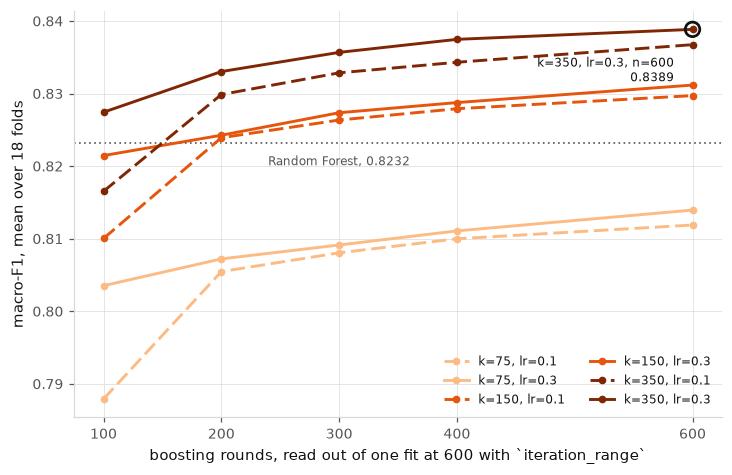

In [22]:
# --- Section 3.4: Figure 5, the boosting model's search ------------------------

FIG5_K_COLORS = {75: "#fdbb84", 150: "#e6550d", 350: "#7f2704"}
FIG5_LR_STYLE = {0.1: (0, (5, 2)), 0.3: "solid"}

section("Section 3.4 - Figure 5")

fig, ax = plt.subplots(figsize=(7.6, 4.8))

rf_reference = float(rf_best.macro_f1)
ax.axhline(rf_reference, color=TEXT_SECONDARY, linewidth=1.1,
           linestyle=(0, (1, 2)), zorder=1)
ax.annotate(f"Random Forest, {rf_reference:.4f}",
            xy=(XGB_STOPS[2], rf_reference), xytext=(0, -8),
            va="top", ha="center", textcoords="offset points",
            fontsize=8, color=TEXT_SECONDARY)

curves, drawn_points = {}, 0
for k_, lr_ in sorted(xgb_grid):
    curve = (xgb_scores[(xgb_scores["k"] == k_)
                        & (xgb_scores["learning_rate"] == lr_)]
             .groupby("n_estimators")["macro_f1"].mean()
             .reindex(XGB_STOPS))
    curves[(k_, lr_)] = curve
    ax.plot(curve.index, curve.to_numpy(), color=FIG5_K_COLORS[k_],
            linestyle=FIG5_LR_STYLE[lr_], linewidth=1.9, marker="o",
            markersize=4, zorder=3,
            label=f"k={k_}, lr={lr_}")
    drawn_points += int(curve.notna().sum())

best_point = (int(xgb_best.n_estimators), float(xgb_best.macro_f1))
ax.scatter(*best_point, s=90, facecolor="none", zorder=4,
           edgecolor=TEXT_PRIMARY, linewidth=1.8)
ax.annotate(f"k={int(xgb_best.k)}, lr={xgb_best.learning_rate},"
            f" n={int(xgb_best.n_estimators)}\n{xgb_best.macro_f1:.4f}",
            xy=best_point, xytext=(-12, -34), textcoords="offset points",
            fontsize=8, color=TEXT_PRIMARY, ha="right")

ax.set_xlabel("boosting rounds, read out of one fit at "
              f"{XGB_N_MAX} with `iteration_range`")
ax.set_ylabel(f"macro-F1, mean over {len(DEV_SUBJECTS)} folds")
ax.set_xticks(XGB_STOPS, [str(n) for n in XGB_STOPS])
ax.legend(fontsize=8, frameon=False, loc="lower right", ncols=2)
fig5_png = save_figure(fig, "fig5_xgboost_grid")

# --- What the picture says, as numbers ----------------------------------------
grid_mean = xgb_scores.groupby(["k", "learning_rate", "n_estimators"])["macro_f1"].mean()
by_k = grid_mean.groupby("k").mean()
by_lr = grid_mean.groupby("learning_rate").mean()
by_n = grid_mean.groupby("n_estimators").mean()
print(f"\n  range over the whole grid : {grid_mean.min():.4f} to"
      f" {grid_mean.max():.4f}   ({grid_mean.max() - grid_mean.min():.4f})")
print(f"  moving k                 : {by_k.min():.4f} to {by_k.max():.4f}"
      f"   ({by_k.max() - by_k.min():.4f})")
print(f"  moving the rounds        : {by_n.min():.4f} to {by_n.max():.4f}"
      f"   ({by_n.max() - by_n.min():.4f})")
print(f"  moving the learning rate : {by_lr.min():.4f} to {by_lr.max():.4f}"
      f"   ({by_lr.max() - by_lr.min():.4f})")

still_rising = sum(bool(c.iloc[-1] >= c.iloc[-2]) for c in curves.values())
above_forest = sum(bool(c.iloc[-1] > rf_reference) for c in curves.values())
print(f"\n  curves still rising at {XGB_N_MAX} rounds: {still_rising}"
      f" of {len(curves)}")
print(f"  curves ending above the forest      : {above_forest}"
      f" of {len(curves)}  — all of them at k=350, none below it")


**The picture ranks the three axes, which the table could only let you infer.**
The bands separate by `k` and nothing else: no curve from a lower band reaches a
higher one at any number of rounds, while inside a band the two learning rates
run almost together. The forest, tuned on the same folds, was indifferent to
that same axis.

**The horizontal rule is the comparison, drawn rather than described.** Only the
three curves at `k`=350 finish above the forest. Whatever separates this family
from bagging on these folds, it is not available at 75 or 150 features — more
useful than "boosting wins", because it says under what condition.

Every curve is still climbing at the right-hand edge: 600 rounds is where the
budget ended, not where the model stopped improving.

### 3.5 Model comparison

**Nothing is trained here.** This section takes each model's winning
configuration and its eighteen per-fold scores and asks whether the distance
between them survives being looked at properly. That it can be a read-only pass
is the point of the freeze in §3.3.

The spread between subjects is
enormous — the same model swings by a fifth of its own score depending on who is
held out — and comparing the models as independent samples would put that spread
in the denominator and drown a real difference; one of the two gaps at stake is
a tenth of it. Comparing fold by fold, on the same subject, removes the
variability they share.



In [23]:
# --- Section 3.5: paired comparison -------------------------------------------

from scipy.stats import wilcoxon

ALPHA = 0.05


def holm(pvalues, alpha):
    """Holm-Bonferroni. Returns the adjusted p-values, in the order given, and
    which of them are rejected.

    Sorts ascending and compares the i-th against alpha/(m-i), which keeps more
    power than plain Bonferroni. The running maximum enforces monotonicity: an
    adjusted p-value can never come out below one that preceded it.
    """
    m = len(pvalues)
    adjusted, running = np.empty(m), 0.0
    for i, idx in enumerate(np.argsort(pvalues)):
        running = max(running, min(1.0, (m - i) * pvalues[idx]))
        adjusted[idx] = running
    return adjusted, adjusted < alpha


section("Section 3.5 - paired comparison over the 18 LOSO folds")

model_scores = pd.DataFrame({
    "XGBoost": xgb_best_f1,
    "Random Forest": rf_best_f1,
    "Decision Tree": dt_best_f1,
})
# The family is all three models, so Holm corrects three pairs.
TEST_FAMILY = list(model_scores.columns)

# Pairing requires fold i to be the same subject everywhere. Checked, not
# assumed.
paired = all(list(model_scores.index) == list(range(len(DEV_SUBJECTS)))
             for _ in model_scores.columns)
print(f"\n  {len(model_scores.columns)} models x {len(model_scores)} folds,"
      f" same subjects in the same order: {paired}")

print(f"\n  {'model':<16}{'macro-F1':>18}{'lowest':>10}{'highest':>10}")
for name in model_scores.columns:
    s = model_scores[name]
    print(f"  {name:<16}{s.mean():>11.4f} +/-{s.std(ddof=1):>5.4f}"
          f"{s.min():>10.4f}{s.max():>10.4f}")

# --- The test -----------------------------------------------------------------
comparisons = list(itertools.combinations(TEST_FAMILY, 2))
print(f"\n  family: {len(comparisons)} comparison(s) among"
      f" {len(TEST_FAMILY)} models, alpha = {ALPHA}")
if len(comparisons) == 1:
    print("  with a single pair the Holm correction changes nothing; it is")
    print("  applied anyway so the code does not have to change for a third model")

pair_rows = []
for a, b in comparisons:
    diff = model_scores[a] - model_scores[b]
    pair_rows.append({"a": a, "b": b, "diff": diff.mean(),
                      "se": diff.std(ddof=1) / np.sqrt(len(diff)),
                      "p": float(wilcoxon(diff).pvalue),
                      "wins": int((diff > 0).sum()), "n": len(diff)})
p_adjusted, rejected = holm([r["p"] for r in pair_rows], ALPHA)
for r, pa, rj in zip(pair_rows, p_adjusted, rejected):
    r["p_holm"], r["significant"] = float(pa), bool(rj)

print(f"\n  {'comparison':<32}{'difference':>12}{'SE':>9}{'p':>11}"
      f"{'p Holm':>10}{'wins':>8}")
for r in pair_rows:
    print(f"  {r['a'] + ' - ' + r['b']:<32}{r['diff']:>+12.4f}{r['se']:>9.4f}"
          f"{r['p']:>11.5f}{r['p_holm']:>10.5f}"
          f"{r['wins']:>5}/{r['n']}" + ("  *" if r["significant"] else ""))
print(f"  * = significant after correction (p_Holm < {ALPHA})")

# A p-value is about how surprising the data would be if the two models were
# equivalent, not about how large the difference is: with 18 paired folds even
# a third-decimal difference can come out significant.
print(f"\n  {'comparison':<32}{'difference':>12}{'95% interval':>24}")
for r in pair_rows:
    lo, hi = r["diff"] - 1.96 * r["se"], r["diff"] + 1.96 * r["se"]
    print(f"  {r['a'] + ' - ' + r['b']:<32}{r['diff']:>+12.4f}"
          f"   [{lo:+.4f}, {hi:+.4f}]")

# --- The delivered model ------------------------------------------------------
# Decided HERE, on validation, before any cell touches the held-out subjects:
# best mean macro-F1 over the eighteen folds. Deciding it after §4.1 would make
# the headline figure a maximum over three test evaluations, optimistic by
# construction.
DELIVERED = model_scores.mean().idxmax()
best_of = {"Random Forest": rf_best, "Decision Tree": dt_best,
           "XGBoost": xgb_best}[DELIVERED]
print(f"\n  delivered model: {DELIVERED}, on validation and not on test"
      f"   (macro-F1 {model_scores[DELIVERED].mean():.4f})")



Section 3.5 - paired comparison over the 18 LOSO folds

  3 models x 18 folds, same subjects in the same order: True

  model                     macro-F1    lowest   highest
  XGBoost              0.8389 +/-0.0400    0.7462    0.9128
  Random Forest        0.8232 +/-0.0326    0.7440    0.8705
  Decision Tree        0.6590 +/-0.0543    0.5707    0.7601

  family: 3 comparison(s) among 3 models, alpha = 0.05

  comparison                        difference       SE          p    p Holm    wins
  XGBoost - Random Forest              +0.0157   0.0048    0.00560   0.00560   16/18  *
  XGBoost - Decision Tree              +0.1799   0.0060    0.00001   0.00002   18/18  *
  Random Forest - Decision Tree        +0.1642   0.0086    0.00001   0.00002   18/18  *
  * = significant after correction (p_Holm < 0.05)

  comparison                        difference            95% interval
  XGBoost - Random Forest              +0.0157   [+0.0063, +0.0251]
  XGBoost - Decision Tree              +0.1799  

Section 3.5 - Figure 4


saved  Notebook\figures\fig4_loso_scores.png  and  fig4_loso_scores.pdf

  medians: XGBoost 0.8367 | Random Forest 0.8190 | Decision Tree 0.6570
  the ranges overlap: the forest's worst subject scores 0.7440, below the tree's best at 0.7601
  the lines do not cross: subject by subject the forest wins by at least +0.1104


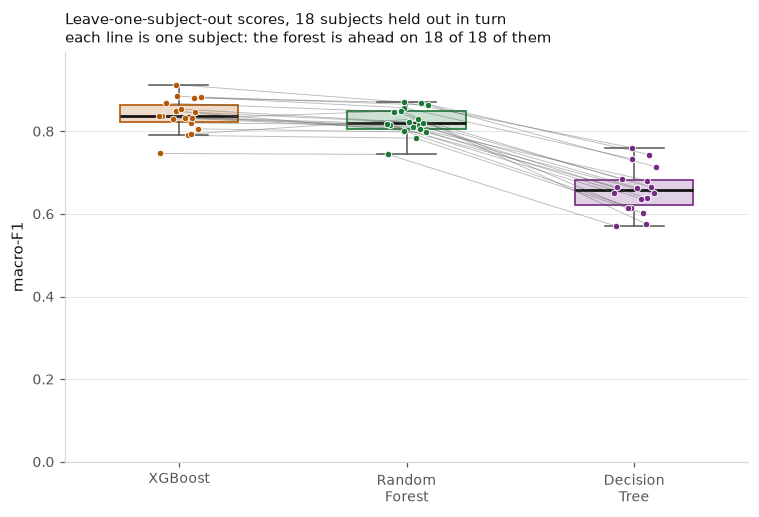

In [24]:
# --- Section 3.5: Figure 4, the per-fold scores -------------------------------


FIG4_ORDER = ["XGBoost", "Random Forest", "Decision Tree"]
FIG4_COLORS = {"XGBoost": "#b35806",
               "Random Forest": "#1b7837",
               "Decision Tree": "#762a83"}
FILL_ALPHA = 0.22
JITTER = 0.10            # one offset per subject, reused at all three models

section("Section 3.5 - Figure 4")

positions = np.arange(1, len(FIG4_ORDER) + 1, dtype=float)
rng = np.random.default_rng(C.RANDOM_SEED)
offsets = rng.uniform(-JITTER, JITTER, len(model_scores))

fig, ax = plt.subplots(figsize=(7.0, 4.8))
bp = ax.boxplot([model_scores[m].to_numpy() for m in FIG4_ORDER],
                positions=positions, widths=0.52,
                patch_artist=True, showfliers=False, zorder=1,
                medianprops={"color": TEXT_PRIMARY, "linewidth": 1.8},
                whiskerprops={"color": TEXT_SECONDARY},
                capprops={"color": TEXT_SECONDARY},
                tick_labels=[m.replace(" ", "\n") for m in FIG4_ORDER])
for patch, name in zip(bp["boxes"], FIG4_ORDER):
    patch.set_facecolor((*mpl.colors.to_rgb(FIG4_COLORS[name]), FILL_ALPHA))
    patch.set_edgecolor(FIG4_COLORS[name])
    patch.set_linewidth(1.1)

# One polyline per subject, under the points and over the fill.
lines_drawn = 0
for offset, (_, row) in zip(offsets, model_scores.iterrows()):
    ax.plot(positions + offset, [row[m] for m in FIG4_ORDER],
            color=TEXT_SECONDARY, linewidth=0.6, alpha=0.4, zorder=2)
    lines_drawn += 1
points_drawn = 0
for x, name in zip(positions, FIG4_ORDER):
    ax.scatter(x + offsets, model_scores[name].to_numpy(), s=18, zorder=3,
               color=FIG4_COLORS[name], edgecolor=SURFACE, linewidth=0.6)
    points_drawn += len(model_scores)

gap = model_scores["Random Forest"] - model_scores["Decision Tree"]
ax.set_ylabel("macro-F1")
ax.set_ylim(0, float(model_scores.to_numpy().max()) + 0.08)
ax.set_xlim(0.5, len(FIG4_ORDER) + 0.5)
ax.set_title(f"Leave-one-subject-out scores, {len(model_scores)} subjects held"
             f" out in turn\neach line is one subject: the forest is ahead on"
             f" {int((gap > 0).sum())} of {len(gap)} of them",
             fontsize=10, loc="left")
ax.grid(False)
ax.grid(axis="y", color=GRID, linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
fig4_png = save_figure(fig, "fig4_loso_scores")

medians = {m: float(np.median(model_scores[m])) for m in FIG4_ORDER}
print("\n  medians: " + " | ".join(f"{m} {v:.4f}" for m, v in medians.items()))
print(f"  the ranges overlap: the forest's worst subject scores"
      f" {model_scores['Random Forest'].min():.4f}, below the tree's best at"
      f" {model_scores['Decision Tree'].max():.4f}")
print(f"  the lines do not cross: subject by subject the forest wins by at"
      f" least {gap.min():+.4f}")


**Every pair is ordered the same way on almost every subject, and the two
comparisons are not the same kind of statement.** The forest beats the tree on
eighteen folds out of eighteen, where the signed-rank test returns the smallest
value it can produce and the p-value has stopped measuring anything except
unanimity. The boosting model beats the forest on sixteen out of eighteen: there
the test has room to distinguish, and the number does real work.

**The two gaps are of very different sizes.** Bagging over a single tree is
worth +0.164; boosting over bagging is worth +0.016 — real, significant, and a
tenth of the first. The family choice between a tree and an ensemble dominates
everything else in this notebook; the choice between two ensembles is a
refinement measurable on eighteen subjects and not much more.

**The picture and the test disagree instructively.** The ranges overlap — the
winning model's worst subject scores below the forest's best — so comparing the
two distributions as independent samples would leave room for doubt. There is
less than it looks: held out one at a time, the same person is classified better
by the boosting model sixteen times out of eighteen, and the standard error of
the paired differences is an order of magnitude below the spread between people.



In [25]:
# --- Section 3.5: the model comparison table ----------------------------------
# No new computation: every figure below came from a cell above. The baseline
# row is the single tree, tuned like the other two rather than left at its
# defaults — otherwise «the forest beats the tree» would have two causes stacked
# on top of each other, the bagging and the fact that one was searched.
table2_rows = [
    ("Baseline", "Decision Tree", len(grid), "Decision Tree"),
    ("Model A", "Random Forest", len(rf_grid), "Random Forest"),
    ("Model B", "XGBoost", len(xgb_rank), "XGBoost"),
]
best_config = {
    "Decision Tree": f"max_depth={int(dt_best.max_depth)}, "
                     f"min_samples_leaf={int(dt_best.min_samples_leaf)}, "
                     f"k={int(dt_best.k)}",
    "Random Forest": f"n_estimators={int(rf_best.n_estimators)}, "
                     f"max_features={RF_MAX_FEATURES}, "
                     f"min_samples_leaf={int(rf_best.min_samples_leaf)}, "
                     f"k={int(rf_best.k)}",
    "XGBoost": f"k={int(xgb_best.k)}, max_leaves={XGB_MAX_LEAVES}, "
               f"learning_rate={xgb_best.learning_rate}, "
               f"n_estimators={int(xgb_best.n_estimators)}",
}
val_metric = {m: (float(model_scores[m].mean()),
                  float(model_scores[m].std(ddof=1)))
              for m in model_scores.columns}

section("Section 3.5 - model comparison")

print(f"\n  {'model':<32}{'configs':>9}{'val macro-F1':>20}{'test':>10}")
for role, name, n_configs, key in table2_rows:
    mean, sd = val_metric[key]
    print(f"  {role + ': ' + name:<32}{n_configs:>9}"
          f"{mean:>13.4f} +/-{sd:>5.4f}{'§4.1':>10}")

print("\n  winning configurations")
for role, name, n_configs, key in table2_rows:
    print(f"    {name:<22}{best_config[key]}")

print(f"\n  the search was not equally wide: the tree tried {len(grid)}"
      f" configurations, the forest {len(rf_grid)},")
print("  so their optimism is not equal either -- and the wider search lost")
print("  the test column is measured once, in §4.1, on the held-out subjects")


Section 3.5 - model comparison

  model                             configs        val macro-F1      test
  Baseline: Decision Tree                27       0.6590 +/-0.0543      §4.1
  Model A: Random Forest                 18       0.8232 +/-0.0326      §4.1
  Model B: XGBoost                       30       0.8389 +/-0.0400      §4.1

  winning configurations
    Decision Tree         max_depth=15, min_samples_leaf=1, k=350
    Random Forest         n_estimators=200, max_features=sqrt, min_samples_leaf=5, k=350
    XGBoost               k=350, max_leaves=63, learning_rate=0.3, n_estimators=600

  the search was not equally wide: the tree tried 27 configurations, the forest 18,
  so their optimism is not equal either -- and the wider search lost
  the test column is measured once, in §4.1, on the held-out subjects


## Part 5 — Final evaluation, explainability and error analysis

### 4.1 Final evaluation on the held-out subjects

**This is the only section that opens the four subjects set aside in §1.4, and
it opens them once.** 

**They are prepared with exactly the code that prepared the others** — same
window, same stride, same rules for the label and for discarding — because a
test set built differently measures the preparation as much as the subjects.
Each winning configuration is then retrained on **all eighteen development
subjects at once, with no folds**: cross-validation existed to estimate
generalisation, and here the held-out subjects provide it for real.

Three things are recomputed on that final training set and only on it: the
undersampling of `idle`, the mutual-information ranking, and the scaler. None
may see a held-out row.

In [26]:
# --- Section 4.1: the held-out subjects, prepared -----------------------------

TEST_INDEX_PATH = WINDOWS_DIR / "window_index_test.parquet"
TEST_INDEX_META_PATH = WINDOWS_DIR / "window_index_test_meta.json"
TEST_FEATURES_META_PATH = FEATURES_DIR / "features_meta_test.json"

section(f"Section 4.1 - preparing the {len(TEST_SUBJECTS)} held-out subjects")

# --- Windows ------------------------------------------------------------------
meta_test = (json.loads(TEST_INDEX_META_PATH.read_text(encoding="utf-8"))
             if TEST_INDEX_META_PATH.exists() and TEST_INDEX_PATH.exists() else {})
reusable_test = (meta_test.get("window_samples") == WIN
                 and meta_test.get("stride_samples") == STRIDE
                 and meta_test.get("classes") == list(C.CLASSES)
                 and meta_test.get("subjects") == sorted(TEST_SUBJECTS))

if reusable_test:
    windows_test = pd.read_parquet(TEST_INDEX_PATH)
    checkpoint_note(TEST_INDEX_PATH, len(windows_test), "held-out windows")
else:
    parts, tot = [], {"positions": 0, "discarded": 0, "ties": 0, "short": 0}
    n_trials_test = n_samples_test = 0
    for fp in tqdm([PARQUET_DIR / f"{s}__{m}.parquet"
                    for s in sorted(TEST_SUBJECTS) for m in C.MODES],
                   desc="windowing held-out", unit="file"):
        subject, mode = fp.stem.split("__")
        df = pd.read_parquet(fp, columns=window_cols)
        n_samples_test += len(df)
        for trial_id, g in df.groupby("trial_id", sort=True):
            n_trials_test += 1
            rows, counters = windows_of_trial(g.sort_values("Header"), codes)
            for key_, value_ in counters.items():
                tot[key_] += value_
            if rows is None:
                continue
            rows.insert(0, "trial_id", trial_id)
            rows.insert(0, "mode", mode)
            rows.insert(0, "subject", subject)
            parts.append(rows)

    windows_test = pd.concat(parts, ignore_index=True)
    meta_test = {
        "created": datetime.now().isoformat(timespec="seconds"),
        "generated_by": "notebook, section 4.1",
        "window_ms": C.WINDOW_MS, "window_samples": WIN,
        "stride_ms": C.STRIDE_MS_CV, "stride_samples": STRIDE,
        "classes": list(C.CLASSES), "subjects": sorted(TEST_SUBJECTS),
        "n_windows": int(len(windows_test)),
        "n_positions": int(tot["positions"]),
        "n_discarded": int(tot["discarded"]),
        "n_trials": int(n_trials_test), "n_samples": int(n_samples_test),
    }
    windows_test.to_parquet(TEST_INDEX_PATH, index=False)
    TEST_INDEX_META_PATH.write_text(json.dumps(meta_test, indent=2),
                                    encoding="utf-8")

n_win_positions_test = meta_test["n_positions"]
n_win_discarded_test = meta_test["n_discarded"]

print(f"\n  windows produced : {len(windows_test):,} from"
      f" {n_win_positions_test:,} positions over {meta_test['n_trials']:,}"
      f" trials, {n_win_discarded_test:,} discarded")

# The invariant left standing in 1.3, eleven blocks ago.
print(f"\n  the deferred invariant of 1.3")
print(f"    positions   {n_win_positions_dev:>9,} + {n_win_positions_test:>7,}"
      f" = {n_win_positions_dev + n_win_positions_test:>9,}"
      f"   counted there: {win_tot:>9,}")
print(f"    discarded   {n_win_discarded_dev:>9,} + {n_win_discarded_test:>7,}"
      f" = {n_win_discarded_dev + n_win_discarded_test:>9,}"
      f"   counted there: {win_bad:>9,}")

# --- Features -----------------------------------------------------------------
signature_test = {k: meta_test[k] for k in
                  ("created", "window_samples", "stride_samples", "n_windows")}
prev_test = (json.loads(TEST_FEATURES_META_PATH.read_text(encoding="utf-8"))
             if TEST_FEATURES_META_PATH.exists() else {})
if (prev_test.get("index") == signature_test
        and prev_test.get("n_features") == len(FEATURE_NAMES)):
    done_test = {s: n for s, n in prev_test["rows_by_subject"].items()
                 if (FEATURES_DIR / f"features__{s}.parquet").exists()}
    checkpoint_note(TEST_FEATURES_META_PATH, len(done_test), "held-out subjects")
else:
    done_test = {}

for s in tqdm(sorted(TEST_SUBJECTS), desc="features held-out", unit="subject"):
    if s in done_test:
        continue
    out, _ = features_of_subject(
        s, windows_test[windows_test["subject"] == s], band_masks, ac_bins)
    out.to_parquet(FEATURES_DIR / f"features__{s}.parquet",
                   index=False, compression="snappy")
    done_test[s] = int(len(out))
    TEST_FEATURES_META_PATH.write_text(json.dumps(
        {"index": signature_test, "n_features": len(FEATURE_NAMES),
         "rows_by_subject": done_test}, indent=2), encoding="utf-8")

X_test = np.empty((len(windows_test), len(FEATURE_NAMES)), dtype=np.float32)
y_parts_test, group_parts_test, at_test = [], [], 0
for s in sorted(TEST_SUBJECTS):
    d = pd.read_parquet(FEATURES_DIR / f"features__{s}.parquet",
                        columns=FEATURE_NAMES + ["label", "subject"])
    X_test[at_test:at_test + len(d)] = d[FEATURE_NAMES].to_numpy(dtype=np.float32)
    y_parts_test.append(d["label"].to_numpy())
    group_parts_test.append(d["subject"].to_numpy())
    at_test += len(d)
y_test = np.concatenate(y_parts_test).astype(str)
groups_test = np.concatenate(group_parts_test).astype(str)
del y_parts_test, group_parts_test, d

print(f"\n  test matrix      : {X_test.shape[0]:,} x {X_test.shape[1]}"
      f"  ({X_test.nbytes / 1e6:,.0f} MB)")
shares = pd.Series(y_test).value_counts(normalize=True)
print(f"  class shares     : rarest {shares.idxmin()} at"
      f" {100 * shares.min():.2f}%, most common {shares.idxmax()} at"
      f" {100 * shares.max():.2f}%")



Section 4.1 - preparing the 4 held-out subjects
  checkpoint found: window_index_test.parquet -> reusing 72,523 held-out windows already computed; they will not be recomputed

  windows produced : 72,523 from 72,534 positions over 550 trials, 11 discarded

  the deferred invariant of 1.3
    positions     319,758 +  72,534 =   392,292   counted there:   392,292
    discarded         107 +      11 =       118   counted there:       118
  checkpoint found: features_meta_test.json -> reusing 4 held-out subjects already computed; they will not be recomputed


features held-out: 100%|██████████| 4/4 [00:00<?, ?subject/s]



  test matrix      : 72,523 x 555  (161 MB)
  class shares     : rarest stair_descent at 5.20%, most common idle at 34.63%


In [27]:
# --- Section 4.1: retrain and evaluate, once ----------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from nb_utils import XGBClasses
import hashlib
import joblib

section("Section 4.1 - final training on 18 subjects, evaluation on 4")

FINAL_ARRAYS_PATH = CKPT_DIR / "final_eval.npz"
FINAL_META_PATH = CKPT_DIR / "final_eval_meta.json"
FINAL_MODEL_PATH = CKPT_DIR / "final_model.joblib"

# --- The final training set ---------------------------------------------------
# No folds: cross-validation estimated generalisation by holding subjects out,
# and the held-out subjects exist for real now. Runs whether or not the
# checkpoint is reused, because `final_train` is what the signature below is a
# fingerprint OF.
rng = np.random.default_rng(C.RANDOM_SEED)
final_train = undersample_idle(y, C.IDLE_KEEP_FRACTION, rng)
print(f"\n  training  : {len(X):,} windows from {len(DEV_SUBJECTS)} subjects"
      f" -> {len(final_train):,} after undersampling `idle`")
print(f"  test      : {len(X_test):,} windows from {len(TEST_SUBJECTS)} subjects")


# --- One fit per model --------------------------------------------------------
def build_model(name):
    """The estimator for one model name, at the configuration §3.4 chose.

    One place in the notebook knows how to build each family, and §4.2 and §4.3
    call it too. Before XGBoost arrived they each named `RandomForestClassifier`
    directly, which was correct only for as long as the forest happened to win:
    a cell that quietly explains a different model from the one Table 2 delivers
    raises nothing and produces the wrong figure.
    """
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=int(rf_best.n_estimators), max_features=RF_MAX_FEATURES,
            min_samples_leaf=int(rf_best.min_samples_leaf),
            max_depth=RF_MAX_DEPTH, criterion="gini",
            class_weight="balanced_subsample", n_jobs=-1,
            random_state=C.RANDOM_SEED)
    if name == "Decision Tree":
        return DecisionTreeClassifier(
            max_depth=int(dt_best.max_depth),
            min_samples_leaf=int(dt_best.min_samples_leaf), max_features=None,
            criterion="gini", class_weight="balanced",
            random_state=C.RANDOM_SEED)
    if name == "XGBoost":
        # The nb_utils wrapper absorbs the three ways XGBoost differs from
        # scikit-learn — integer labels, sample weights, class names out of
        # predict — so nothing downstream needs to know which family it holds.
        return XGBClasses(
            C.CLASSES, n_estimators=int(xgb_best.n_estimators),
            learning_rate=float(xgb_best.learning_rate),
            max_leaves=XGB_MAX_LEAVES, n_jobs=-1,
            random_state=C.RANDOM_SEED, verbosity=0, **XGB_FIXED)
    raise ValueError(f"no builder for {name!r}")


MODEL_K = {"Random Forest": int(rf_best.k), "Decision Tree": int(dt_best.k),
           "XGBoost": int(xgb_best.k)}

final_models = [(name, MODEL_K[name]) for name in model_scores.columns]

# The order is the one §3.5 compared them in, so the tables printed below read
# the same way as Table 2 and nothing has to be matched up by eye.


# --- The checkpoint, and what makes it safe to reuse --------------------------
# Reuse only if the stored arrays came from *these* models, on *these* rows.
# Everything that could change the numbers goes into the signature.
def digest(a):
    """A short fingerprint of an array's contents.

    Enough of a hash to notice that the labels, the rows or the matrix moved;
    not so much of one that the file becomes unreadable. sha256 rather than
    hash() because Python salts the latter per process, and a checkpoint that
    stops matching after a restart is worse than no checkpoint at all.
    """
    return hashlib.sha256(np.ascontiguousarray(a).tobytes()).hexdigest()[:16]


def config_of(name):
    """The hyperparameters `build_model` sets, read back off the estimator.

    Read from the object rather than re-listed here on purpose: a second copy
    of the configuration is a second place to forget to update, and the whole
    point of this signature is to notice when §3.4 has chosen differently.
    Non-finite floats are dropped — `missing=nan` is a constant of
    XGBClassifier, and nan != nan would make every signature disagree with
    itself, checkpoint or no checkpoint.
    """
    model = build_model(name)
    est = getattr(model, "booster", model)
    return {k: v for k, v in sorted(est.get_params().items())
            if v is None or isinstance(v, (bool, int, str))
            or (isinstance(v, float) and np.isfinite(v))}


final_signature = {
    "models": [name for name, _ in final_models],
    "k": {name: k for name, k in final_models},
    "config": {name: config_of(name) for name, _ in final_models},
    "delivered": DELIVERED,
    "seed": int(C.RANDOM_SEED),
    "idle_keep_fraction": float(C.IDLE_KEEP_FRACTION),
    "n_features": len(FEATURE_NAMES),
    # Rows, labels and — strided, the matrix is a gigabyte — the values
    # themselves: the stride catches what shapes cannot, a matrix of the right
    # size built from a different feature order.
    "train_rows": digest(final_train),
    "train_labels": digest(y[final_train]),
    "train_values": digest(X[final_train[::997]]),
    "test_labels": digest(y_test),
    "test_values": digest(X_test[::997]),
}

reusable_final = (FINAL_ARRAYS_PATH.is_file() and FINAL_META_PATH.is_file()
                  and FINAL_MODEL_PATH.is_file())
stored_final = (json.loads(FINAL_META_PATH.read_text(encoding="utf-8"))
                if FINAL_META_PATH.is_file() else {})
if reusable_final:
    reusable_final = stored_final.get("signature") == final_signature
if reusable_final:
    # A pickle can fail for a reason unrelated to the signature: a different
    # XGBoost or sklearn in the environment. That is «no usable checkpoint»,
    # not an error — the cell recomputes, out loud.
    try:
        final_delivered = joblib.load(FINAL_MODEL_PATH)
    except Exception as exc:
        print(f"\n  checkpoint present, but the stored {DELIVERED} cannot be"
              f" read back ({type(exc).__name__}: {exc}); recomputing")
        reusable_final = False

if reusable_final:
    arrays = np.load(FINAL_ARRAYS_PATH, allow_pickle=False)
    final_mi = arrays["final_mi"]
    final_order = arrays["final_order"]
    test_results = pd.DataFrame(stored_final["results"])
    test_predictions = {}
    for name, _ in final_models:
        classes = [str(c) for c in arrays[f"classes__{name}"]]
        proba = arrays[f"proba__{name}"]
        test_predictions[name] = (
            np.asarray(classes)[arrays[f"pred__{name}"]],
            None if proba.size == 0 else proba,
            classes)
    checkpoint_note(FINAL_ARRAYS_PATH, len(final_models), "fitted models")
    print(f"  MI ranking: recalled | top:"
          f" {', '.join(FEATURE_NAMES[i] for i in final_order[:3])}")
else:
    # One ranking, not eighteen — and computed on the final training rows only.
    t0 = time.time()
    final_mi = mutual_info_classif(X[final_train], y[final_train],
                                   random_state=C.RANDOM_SEED, n_jobs=-1)
    final_order = np.argsort(-final_mi)
    print(f"  MI ranking: {time.time() - t0:.0f} s on {len(final_train):,}"
          f" training rows | top:"
          f" {', '.join(FEATURE_NAMES[i] for i in final_order[:3])}")

    test_results, test_predictions, final_delivered = [], {}, None
    for name, k in final_models:
        cols = final_order[:k]
        A, B = X[np.ix_(final_train, cols)], X_test[:, cols]
        # A threshold split does not care about units, so the scaler is inert
        # here. Kept so all three see the same transformation and §3.5 compares
        # algorithms rather than preprocessing.
        scaler = StandardScaler(copy=False).fit(A)
        A, B = scaler.transform(A), scaler.transform(B)
        clf = build_model(name)
        t0 = time.time()
        clf.fit(A, y[final_train])
        t_fit = time.time() - t0
        pred = clf.predict(B)
        proba = clf.predict_proba(B) if hasattr(clf, "predict_proba") else None
        test_predictions[name] = (pred, proba, list(getattr(clf, "classes_",
                                                            C.CLASSES)))
        # Kept rather than dropped: §4.2 explains this exact object instead of
        # refitting an identical one.
        if name == DELIVERED:
            final_delivered = clf
        row = {"model": name, "k": k, "t_fit_s": t_fit,
               "val_macro_f1": float(model_scores[name].mean()),
               "test_macro_f1": f1_score(y_test, pred, average="macro"),
               "test_f1_loco": f1_score(y_test, pred, labels=LOCO_CLASSES,
                                        average="macro"),
               "test_accuracy": accuracy_score(y_test, pred)}
        for cls, value in zip(C.CLASSES, f1_score(y_test, pred,
                                                  labels=list(C.CLASSES),
                                                  average=None, zero_division=0)):
            row[f"f1__{cls}"] = value
        test_results.append(row)
        del A, B

    test_results = pd.DataFrame(test_results)

    # Stored as codes into the model's own `classes_`, not as strings:
    # sklearn sorts that list alphabetically and the wrapper keeps C.CLASSES
    # order, so the mapping has to travel with the model.
    assert final_delivered is not None, (
        f"{DELIVERED} is the delivered model and was never fitted in this loop:"
        f" §4.2 would explain nothing")

    payload = {"final_mi": final_mi, "final_order": final_order}
    for name, _ in final_models:
        pred, proba, classes = test_predictions[name]
        index = {c: i for i, c in enumerate(classes)}
        payload[f"pred__{name}"] = np.array([index[v] for v in pred],
                                            dtype=np.int8)
        payload[f"proba__{name}"] = (np.asarray(proba, dtype=np.float32)
                                     if proba is not None
                                     else np.zeros((0, 0), dtype=np.float32))
        payload[f"classes__{name}"] = np.asarray(classes, dtype="<U16")
    np.savez_compressed(FINAL_ARRAYS_PATH, **payload)
    # `default=float` because the scores arrive as numpy scalars, which json
    # will not serialise and which round-trip through a float exactly.
    FINAL_META_PATH.write_text(json.dumps(
        {"signature": final_signature,
         "results": test_results.to_dict(orient="records")},
        indent=2, default=float), encoding="utf-8")
    joblib.dump(final_delivered, FINAL_MODEL_PATH, compress=3)
    print(f"\n  checkpoint written: {FINAL_ARRAYS_PATH.name},"
          f" {FINAL_META_PATH.name} and {FINAL_MODEL_PATH.name}"
          f" ({FINAL_MODEL_PATH.stat().st_size / 1e6:,.0f} MB)")

print(f"\n  {'model':<16}{'k':>5}{'fit (s)':>9}{'test macro-F1':>15}"
      f"{'F1 loco':>10}{'accuracy':>10}")
for _, r in test_results.iterrows():
    print(f"  {r['model']:<16}{int(r['k']):>5}{r['t_fit_s']:>9.0f}"
          f"{r['test_macro_f1']:>15.4f}{r['test_f1_loco']:>10.4f}"
          f"{r['test_accuracy']:>10.4f}")
if reusable_final:
    print(f"  the fit times are the ones measured when the checkpoint was"
          f" written, not now")

# The validation column was optimistic by construction. This is how much.
print(f"\n  {'model':<16}{'validation':>13}{'test':>10}{'difference':>13}")
for _, r in test_results.iterrows():
    print(f"  {r['model']:<16}{r['val_macro_f1']:>13.4f}"
          f"{r['test_macro_f1']:>10.4f}"
          f"{r['test_macro_f1'] - r['val_macro_f1']:>+13.4f}")

print(f"\n  per-class F1 on the held-out subjects")
print(f"  {'model':<16}" + "".join(f"{c[:12]:>14}" for c in C.CLASSES))
for _, r in test_results.iterrows():
    print(f"  {r['model']:<16}"
          + "".join(f"{r['f1__' + c]:>14.4f}" for c in C.CLASSES))

# --- The test column of the comparison, now measured --------------------------
test_metrics = dict(zip(test_results["model"], test_results["test_macro_f1"]))
print("\n  model comparison, both columns")
print(f"  {'model':<24}{'val macro-F1':>16}{'test macro-F1':>16}")
for _, name, _, key in table2_rows:
    print(f"  {name:<24}{val_metric[key][0]:>16.4f}{test_metrics[key]:>16.4f}")



Section 4.1 - final training on 18 subjects, evaluation on 4

  training  : 319,651 windows from 18 subjects -> 253,235 after undersampling `idle`
  test      : 72,523 windows from 4 subjects
  checkpoint found: final_eval.npz -> reusing 3 fitted models already computed; they will not be recomputed
  MI ranking: recalled | top: shank_Accel_X__max, foot_Accel_X__max, shank_Gyro_Y__min

  model               k  fit (s)  test macro-F1   F1 loco  accuracy
  XGBoost           350      416         0.8535    0.8459    0.8429
  Random Forest     350      102         0.8426    0.8361    0.8325
  Decision Tree     350      126         0.6807    0.6566    0.6950
  the fit times are the ones measured when the checkpoint was written, not now

  model              validation      test   difference
  XGBoost                0.8389    0.8535      +0.0146
  Random Forest          0.8232    0.8426      +0.0194
  Decision Tree          0.6590    0.6807      +0.0217

  per-class F1 on the held-out subjects

Section 4.1 - Figure 6, 3 models
saved  Notebook\figures\fig6_confusion_matrix.png  and  fig6_confusion_matrix.pdf

  largest confusions, XGBoost
    ramp_ascent     -> walk             20.0%
    ramp_descent    -> walk             12.7%
    idle            -> walk             11.7%
  and the largest of each of the others
    Decision Tree  ramp_ascent     -> walk             22.1%
    Random Forest  ramp_ascent     -> walk             16.0%

  precision, which the matrix cannot show
  class              Decision Tree         XGBoost   Random Forest
  idle                       86.7%           93.7%           94.8%
  walk                       61.6%           71.7%           71.9%
  stair_ascent               69.8%           88.3%           83.8%
  stair_descent              52.5%           89.0%           79.5%
  ramp_ascent                72.0%           90.1%           85.6%
  ramp_descent               58.3%           84.2%           83.5%


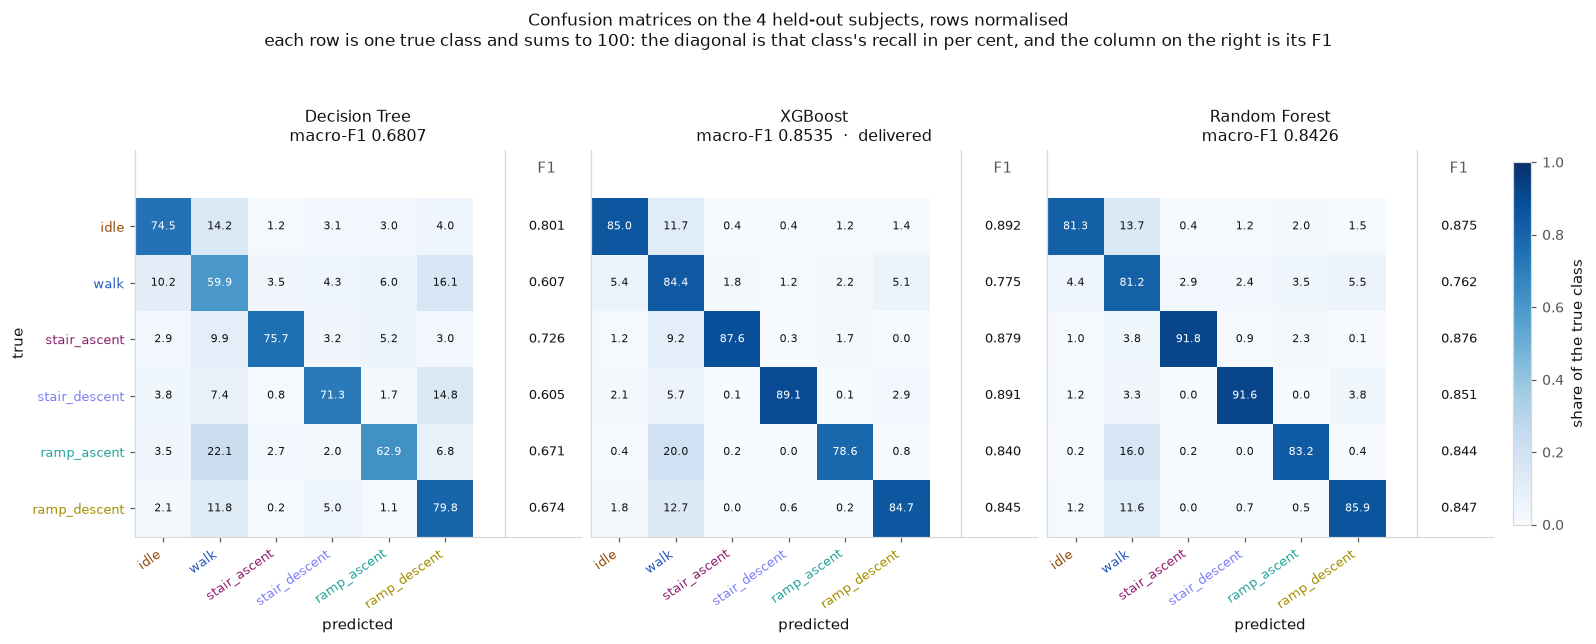

In [28]:
# --- Section 4.1: Figure 6, the confusion matrices ----------------------------

from sklearn.metrics import confusion_matrix, precision_score, recall_score

FIG6_CMAP = "Blues"



# The reading order of both figures here, asserted rather than assumed: a model
# added to §3.4 and not here would silently lose its panel.
PANEL_ORDER = ["Decision Tree", "XGBoost", "Random Forest"]
assert set(PANEL_ORDER) == set(test_predictions), (
    f"the panels {PANEL_ORDER} do not cover the models evaluated in §4.1 "
    f"({sorted(test_predictions)})")

K = len(C.CLASSES)
F1_COLUMN_X = K + 0.8          # where the F1 column sits, in data coordinates

section(f"Section 4.1 - Figure 6, {len(PANEL_ORDER)} models")


def macro_of(name):
    return float(test_results.loc[test_results["model"] == name,
                                  "test_macro_f1"].iloc[0])


def f1_of(name, cls):
    return float(test_results.loc[test_results["model"] == name,
                                  f"f1__{cls}"].iloc[0])


fig, axes = plt.subplots(1, len(PANEL_ORDER), figsize=(14.4, 5.4),
                         layout="constrained")

confusions, f1_drawn = {}, {}
for ax, name in zip(axes, PANEL_ORDER):
    pred = test_predictions[name][0]
    cm = confusion_matrix(y_test, pred, labels=list(C.CLASSES), normalize="true")
    confusions[name] = cm

    im = ax.imshow(cm, cmap=FIG6_CMAP, vmin=0, vmax=1)
    for r in range(K):
        for c in range(K):
            ax.text(c, r, f"{100 * cm[r, c]:.1f}", ha="center", va="center",
                    fontsize=7.5,
                    color="#ffffff" if cm[r, c] > 0.55 else TEXT_PRIMARY)

    # `f1_drawn` stores the number as RENDERED, so the check at the bottom
    # validates the figure rather than the variable behind it.
    ax.axvline(K - 0.5 + 0.55, color=GRID, linewidth=0.9)
    ax.text(F1_COLUMN_X, -1.02, "F1", ha="center", va="center", fontsize=9.5,
            color=TEXT_SECONDARY)
    for r, cls in enumerate(C.CLASSES):
        shown = f"{f1_of(name, cls):.3f}"
        f1_drawn[(name, cls)] = float(shown)
        ax.text(F1_COLUMN_X, r, shown, ha="center", va="center", fontsize=8.5,
                color=TEXT_PRIMARY)

    ax.set_xlim(-0.5, F1_COLUMN_X + 0.6)
    ax.set_ylim(K - 0.5, -1.35)
    ax.set_xticks(range(K), list(C.CLASSES), rotation=35, ha="right",
                  fontsize=8.5)
    for label, cls in zip(ax.get_xticklabels(), C.CLASSES):
        label.set_color(class_color(cls))
    if ax is axes[0]:
        ax.set_yticks(range(K), list(C.CLASSES), fontsize=8.5)
        for label, cls in zip(ax.get_yticklabels(), C.CLASSES):
            label.set_color(class_color(cls))
        ax.set_ylabel("true")
    else:
        ax.set_yticks([])
    ax.set_xlabel("predicted")

    tag = "  ·  delivered" if name == DELIVERED else ""
    ax.set_title(f"{name}\nmacro-F1 {macro_of(name):.4f}{tag}",
                 fontsize=10.5, loc="center")
    ax.grid(False)

fig.colorbar(im, ax=axes, shrink=0.62, pad=0.015,
             label="share of the true class")
fig.suptitle(
    f"Confusion matrices on the {len(TEST_SUBJECTS)} held-out subjects, "
    f"rows normalised\n"
    f"each row is one true class and sums to 100: the diagonal is that class's "
    f"recall in per cent, and the column on the right is its F1",
    fontsize=11, y=1.06)
fig6_png = save_figure(fig, "fig6_confusion_matrix")

# --- What it says -------------------------------------------------------------
# The off-diagonal cells of the delivered model are the material of §4.3.
off = [(C.CLASSES[r], C.CLASSES[c], confusions[DELIVERED][r, c])
       for r in range(K) for c in range(K) if r != c]
off.sort(key=lambda t: -t[2])
print(f"\n  largest confusions, {DELIVERED}")
for true_cls, pred_cls, share in off[:3]:
    print(f"    {true_cls:<15} -> {pred_cls:<15}{100 * share:>6.1f}%")
print(f"  and the largest of each of the others")
for name in PANEL_ORDER:
    if name == DELIVERED:
        continue
    cm = confusions[name]
    r, c = max(((r, c) for r in range(K) for c in range(K) if r != c),
               key=lambda rc: cm[rc])
    print(f"    {name:<15}{C.CLASSES[r]:<15} -> {C.CLASSES[c]:<15}"
          f"{100 * cm[r, c]:>6.1f}%")

# The diagonal is recall and the right-hand column is F1, so precision is what
# the figure cannot carry — and it is where a class that collects everyone
# else's uncertainty shows up.
precisions = {name: precision_score(y_test, test_predictions[name][0],
                                    labels=list(C.CLASSES), average=None,
                                    zero_division=0)
              for name in PANEL_ORDER}
print(f"\n  precision, which the matrix cannot show")
print(f"  {'class':<16}" + "".join(f"{n[:15]:>16}" for n in PANEL_ORDER))
for i, cls in enumerate(C.CLASSES):
    print(f"  {cls:<16}"
          + "".join(f"{100 * precisions[n][i]:>15.1f}%" for n in PANEL_ORDER))


Section 4.1 - Figure 7, 3 models
saved  Notebook\figures\fig7_precision_recall.png  and  fig7_precision_recall.pdf

  class             prevalence  AP Decision Tr      AP XGBoost  AP Random Fore
  idle                   34.6%           0.794           0.963           0.954
  walk                   27.8%           0.518           0.838           0.829
  stair_ascent            5.6%           0.549           0.944           0.901
  stair_descent           5.2%           0.455           0.944           0.899
  ramp_ascent            13.3%           0.594           0.921           0.918
  ramp_descent           13.5%           0.628           0.925           0.918
  macro average                          0.590           0.922           0.903

  the curves describe every threshold, not the one argmax happens to
  pick: a class can be separable and still be lost by the decision rule
  probability rows sum to 1 within 1.8e-07 at worst, which is the float32 softmax rounding and not a defect; t

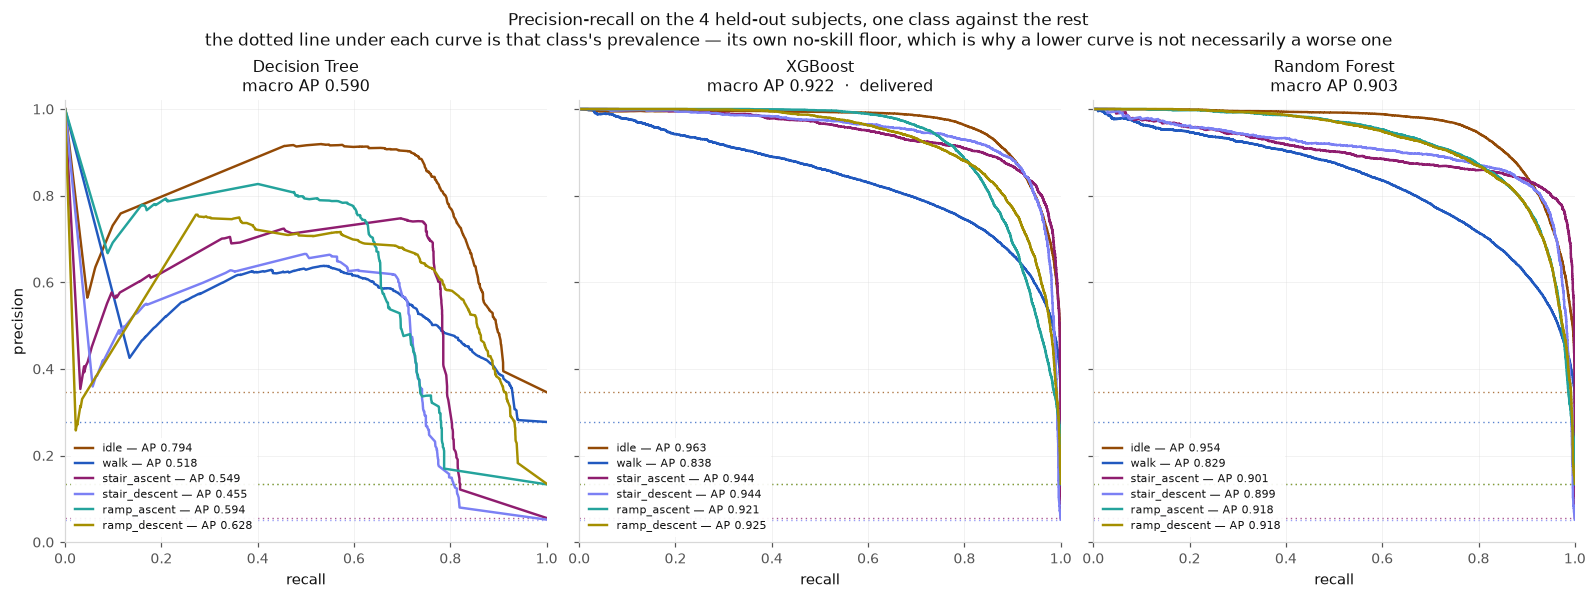

In [29]:
# --- Section 4.1: Figure 7, precision-recall by class -------------------------

from sklearn.metrics import average_precision_score, precision_recall_curve

section(f"Section 4.1 - Figure 7, {len(PANEL_ORDER)} models")

# Prevalence belongs to the labels, not to any model: computed once, drawn in
# every panel.
prevalences = {cls: float((y_test == cls).mean()) for cls in C.CLASSES}

fig, axes = plt.subplots(1, len(PANEL_ORDER), figsize=(14.4, 4.9),
                         sharex=True, sharey=True, layout="constrained")

average_precisions, proba_drift, curve_lines, legend_ap = {}, {}, {}, {}
for ax, name in zip(axes, PANEL_ORDER):
    pred, proba, classes = test_predictions[name]
    column_of = {cls: classes.index(cls) for cls in C.CLASSES}
    average_precisions[name] = {}
    proba_drift[name] = float(np.abs(proba.sum(axis=1) - 1).max())
    curve_lines[name] = []

    for cls in C.CLASSES:
        truth = (y_test == cls).astype(int)
        score = proba[:, column_of[cls]]
        precision, recall, _ = precision_recall_curve(truth, score)
        average_precisions[name][cls] = float(average_precision_score(truth,
                                                                     score))
        line, = ax.plot(recall, precision, color=class_color(cls),
                        linewidth=1.6,
                        label=f"{cls} — AP {average_precisions[name][cls]:.3f}")
        curve_lines[name].append(line)

    # The no-skill floor of each class, drawn rather than stated. Thin, dotted
    # and behind everything: it is a reference, not a series.
    for cls in C.CLASSES:
        ax.axhline(prevalences[cls], color=class_color(cls), linewidth=0.9,
                   linestyle=(0, (1, 2.5)), alpha=0.75, zorder=0)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("recall")
    if ax is axes[0]:
        ax.set_ylabel("precision")
    tag = "  ·  delivered" if name == DELIVERED else ""
    macro_ap = float(np.mean(list(average_precisions[name].values())))
    ax.set_title(f"{name}\nmacro AP {macro_ap:.3f}{tag}", fontsize=10.5,
                 loc="center")
    # The only legend here with a background: four of the six dotted
    # prevalence lines run straight through it. An opaque patch with no border
    # keeps the house style and makes the text readable.
    legend = ax.legend(loc="lower left", fontsize=7.4, labelspacing=0.32,
                       handlelength=1.6, borderpad=0.4, frameon=True,
                       facecolor=SURFACE, edgecolor="none", framealpha=0.93)
    legend.set_zorder(5)
    legend_ap[name] = [t.get_text() for t in legend.get_texts()]
    ax.grid(alpha=0.35)
    ax.set_axisbelow(True)

fig.suptitle(
    f"Precision-recall on the {len(TEST_SUBJECTS)} held-out subjects, "
    f"one class against the rest\n"
    f"the dotted line under each curve is that class's prevalence — its own "
    f"no-skill floor, which is why a lower curve is not necessarily a worse one",
    fontsize=11, y=1.08)
fig7_png = save_figure(fig, "fig7_precision_recall")

# --- What it says -------------------------------------------------------------
print(f"\n  {'class':<16}{'prevalence':>12}"
      + "".join(f"{'AP ' + n[:11]:>16}" for n in PANEL_ORDER))
for cls in C.CLASSES:
    print(f"  {cls:<16}{100 * prevalences[cls]:>11.1f}%"
          + "".join(f"{average_precisions[n][cls]:>16.3f}" for n in PANEL_ORDER))
print(f"  {'macro average':<16}{'':>12}"
      + "".join(f"{np.mean(list(average_precisions[n].values())):>16.3f}"
                for n in PANEL_ORDER))
print(f"\n  the curves describe every threshold, not the one argmax happens to")
print(f"  pick: a class can be separable and still be lost by the decision rule")
print(f"  probability rows sum to 1 within {max(proba_drift.values()):.1e} at"
      f" worst, which is the float32 softmax rounding and not a defect; the"
      f" two float64 models drift by a millionth of that")


**The boosting model holds up on people it had never seen.** The estimate that
counts is this one — four subjects no cell before this section had opened — and
at 0.8535 it lands above what leave-one-subject-out predicted. The two columns
of Table 2 now say different things: validation is what the search found, test
is what the model does.

**All three models score higher on the held-out subjects than in validation, and
that needs an explanation rather than a footnote.** 
The honest statement is therefore not "selection cost us nothing" but
**"at this test size the optimism from selection is not measurable"**. That all
three moved by a similar amount is a property of the protocol, not of any model.

**The class structure is not what class frequency would predict.** The two stair
activities are among the rarest and among the best recognised: rarity did not
become weakness. The worst class is `walk`, and the confusion matrix says why in
a way F1 cannot — its recall is high while everything else leaks *into* it. It
is not a weak class, it is where the model puts what it is not sure about, which
is a precision problem with a plain physical reading: walking on level ground
and on a slope are the same gesture at a different inclination. §4.3 starts
here.

### 4.2 Explaining the delivered model

**This section explains the model of Table 2** — the boosting model retrained on
all eighteen development subjects in §4.1, not a fold model. 

**The values are in logit units — the raw margin the softmax is applied to —
not in probability.** Boosting is additive in that margin, so that is the space
its Shapley values decompose. 





In [30]:
# --- Section 4.2: the delivered model, explained ------------------------------

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

section("Section 4.2 - Shapley values for the delivered forest")


# --- Parameters ---------------------------------------------------------------
N_SHAP = None             # None = every held-out window, no sampling
SHAP_CHUNK = 150          # windows per work unit: 48 units keep the bar moving
SHAP_JOBS = 8             # worker processes, one copy of the model each
SHAP_BACKEND = "process"  # measured; "thread" gains nothing, the C code holds the GIL
SHAP_VALUES_PATH = CKPT_DIR / "shap_values.npy"
SHAP_SAMPLE_PATH = CKPT_DIR / "shap_sample.npy"
SHAP_META_PATH = CKPT_DIR / "shap_meta.json"

# --- The model of Table 2, rebuilt --------------------------------------------
shap_cols = final_order[:int(best_of.k)]
SHAP_FEATURES = [FEATURE_NAMES[i] for i in shap_cols]
shap_scaler = StandardScaler(copy=False).fit(X[np.ix_(final_train, shap_cols)])
B_shap = shap_scaler.transform(X_test[:, shap_cols])

# The object §4.1 fitted, not a copy built here. «It would have to be
# identical» is not an argument this notebook accepts: the anchor below
# recomputes its held-out macro-F1 and refuses to continue unless it matches
# what §4.1 printed.
assert MODEL_K[DELIVERED] == int(best_of.k), (
    f"§4.1 fitted {DELIVERED} on k={MODEL_K[DELIVERED]} while §3.5 chose "
    f"k={int(best_of.k)}: the object below is not the model of Table 2")
model_explained = final_delivered

# `shap` knows scikit-learn estimators and it knows XGBoost's own classifier; it
# does not know the wrapper around it, so what goes to the explainer is the raw
# estimator underneath.
explainable = getattr(model_explained, "booster", model_explained)
EXPLAINS_MARGIN = DELIVERED == "XGBoost"
# Every axis label downstream reads this rather than naming a unit: saying
# «probability» over a raw margin is a caption no verification can catch.
SHAP_UNITS = "logit units" if EXPLAINS_MARGIN else "probability units"


def tree_stats(est):
    """Trees, mean leaves and mean depth, for either family.

    The depth of a boosted tree is not implied by its leaf budget: `lossguide`
    grows leaf by leaf, so 63 leaves can sit anywhere between depth 6 and depth
    62. It is read from the dump rather than assumed, because TreeSHAP costs
    grow with the SQUARE of it and that is the number this cell exists to price.
    """
    if hasattr(est, "estimators_"):
        return (len(est.estimators_),
                float(np.mean([t.get_n_leaves() for t in est.estimators_])),
                float(np.mean([t.get_depth() for t in est.estimators_])))
    dump = est.get_booster().get_dump()
    leaves = [t.count("leaf=") for t in dump]
    depths = [max((ln.count("\t") for ln in t.split("\n") if ln.strip()),
                  default=0) for t in dump]
    return len(dump), float(np.mean(leaves)), float(np.mean(depths))


n_trees, leaves, depth = tree_stats(explainable)
print(f"\n  model     : {DELIVERED}, inherited from §4.1 rather than refitted")
print(f"  structure : {n_trees:,} trees, {leaves:,.0f} leaves and depth"
      f" {depth:.0f} on average")
print(f"  TreeSHAP costs about trees x leaves x depth^2, so roughly"
      f" {n_trees * leaves * depth ** 2 / 1e9:.2f} billion operations per"
      f" window")
print(f"  explains  : {'the raw margin (logit)' if EXPLAINS_MARGIN else 'predict_proba'}"
      f" — boosting is additive in that margin, and that is the space its Shapley")
print(f"              values decompose; the forest's decompose probability")

# The anchor. Not a number copied from a previous run: it is what §4.1 printed
# in this same session, a few cells above.
shap_f1 = f1_score(y_test, model_explained.predict(B_shap),
                   average="macro")

# --- The sample ---------------------------------------------------------------
# Uniform, not stratified: mean |SHAP| averages over the population, so the
# sample has to look like it. Unsorted on purpose — the convergence check reads
# prefixes, and sorting would make each prefix one block of subjects.
rng = np.random.default_rng(C.RANDOM_SEED)
if N_SHAP is None:
    shap_sample = rng.permutation(len(B_shap))
else:
    shap_sample = rng.choice(len(B_shap), min(N_SHAP, len(B_shap)),
                             replace=False)

# --- The checkpoint, and what makes it safe to reuse --------------------------
# Reuse only if the stored values were computed for *this* model on *these*
# windows. The signature carries the selected columns, not just their number:
# identical shapes over different columns is how a silent failure looks here.
shap_signature = {"model": DELIVERED, "k": int(best_of.k),
                  "n_shap": int(len(shap_sample)),
                  "columns": [int(i) for i in shap_cols],
                  "anchor_f1": round(float(shap_f1), 6)}

reusable_shap = (SHAP_VALUES_PATH.is_file() and SHAP_SAMPLE_PATH.is_file()
                 and SHAP_META_PATH.is_file())
if reusable_shap:
    reusable_shap = (json.loads(SHAP_META_PATH.read_text(encoding="utf-8"))
                     == shap_signature
                     and np.array_equal(np.load(SHAP_SAMPLE_PATH), shap_sample))
if reusable_shap:
    shap_values = np.load(SHAP_VALUES_PATH)
    reusable_shap = shap_values.shape == (len(shap_sample), len(shap_cols),
                                          len(C.CLASSES))

if reusable_shap:
    checkpoint_note(SHAP_VALUES_PATH, len(shap_sample), "explained windows")
else:
    print(f"\n  computing : {len(shap_sample):,} of {len(B_shap):,} held-out"
          f" windows | {SHAP_BACKEND} x {SHAP_JOBS}, chunks of {SHAP_CHUNK}")
    t0 = time.time()
    shap_values = shap_parallel(explainable, B_shap[shap_sample],
                                jobs=SHAP_JOBS, backend=SHAP_BACKEND,
                                chunk=SHAP_CHUNK).astype(np.float32)
    dur = time.time() - t0
    print(f"  done      : {hms(dur)} ({dur / len(shap_sample):.2f} s/window),"
          f" array {shap_values.shape} (windows, features, classes)")
    np.save(SHAP_SAMPLE_PATH, shap_sample)
    np.save(SHAP_VALUES_PATH, shap_values)
    SHAP_META_PATH.write_text(json.dumps(shap_signature, indent=2),
                              encoding="utf-8")


# `expected_value` is not settled on a fresh explainer: shap fills it in when the
# object first computes values (shap/shap#4495), so reading it here returns the
# model's `base_score` and the comparison below would measure the library's
# initialisation rather than the decomposition. One window settles it.
shap_explainer = shap.TreeExplainer(explainable)
shap_explainer.shap_values(B_shap[shap_sample[:1]])
shap_declared_base = np.asarray(shap_explainer.expected_value, dtype=np.float64)
shap_proba = model_explained.predict_proba(B_shap[shap_sample])
# The values add up to what the explainer decomposed, and that differs by
# family: a forest's reconstruct `predict_proba`, this model's the raw margin.
# Checking one against the other could pass where the two happen to be close,
# leaving Figure 9 claiming a scale it does not use.
if EXPLAINS_MARGIN:
    shap_reference = np.asarray(
        explainable.predict(B_shap[shap_sample], output_margin=True),
        dtype=np.float64)
else:
    shap_reference = shap_proba
# float64 here too: 350 single-precision values summed in margin space
# drift by about 1e-4, which is a tenth of the tolerance below rather than
# a property of the decomposition.
shap_residual = shap_reference - shap_values.sum(axis=1, dtype=np.float64)
shap_base = shap_residual.mean(axis=0)
additivity = float(np.abs(shap_residual - shap_base).max())
base_drift = float(np.abs(shap_base - shap_declared_base).max())
print("")
print(f"  base value: measured from the data, and it sits {base_drift:.1e}"
      f" from what the explainer declares — the same for every window,")
print(f"              which is what additivity requires and what the check"
      f" below measures")

# --- How many windows were actually needed ------------------------------------
# A ranking settles before the average that generates it. Costs nothing: it
# re-reads prefixes of what is already computed.
shap_top20 = np.argsort(
    -np.abs(shap_values).mean(axis=(0, 2), dtype=np.float64))[:20]
print(f"\n  {'windows':>9}{'top 20 shared':>16}{'same order':>13}")
for frac in (0.25, 0.5, 0.75, 1.0):
    m = max(1, int(len(shap_values) * frac))
    top = np.argsort(
        -np.abs(shap_values[:m]).mean(axis=(0, 2), dtype=np.float64))[:20]
    print(f"  {m:>9,}{len(set(top) & set(shap_top20)):>13}/20"
          f"{'yes' if list(top) == list(shap_top20) else 'no':>13}")



Section 4.2 - Shapley values for the delivered forest

  model     : XGBoost, inherited from §4.1 rather than refitted
  structure : 3,600 trees, 58 leaves and depth 14 on average
  TreeSHAP costs about trees x leaves x depth^2, so roughly 0.04 billion operations per window
  explains  : the raw margin (logit) — boosting is additive in that margin, and that is the space its Shapley
              values decompose; the forest's decompose probability
  checkpoint found: shap_values.npy -> reusing 72,523 explained windows already computed; they will not be recomputed

  base value: measured from the data, and it sits 1.0e-06 from what the explainer declares — the same for every window,
              which is what additivity requires and what the check below measures

    windows   top 20 shared   same order
     18,130           20/20           no
     36,261           20/20           no
     54,392           20/20          yes
     72,523           20/20          yes


Section 4.2 - Figure 8
saved  Notebook\figures\fig8_shap_global.png  and  fig8_shap_global.pdf

  feature                           mean |SHAP|
  hip_sagittal__max                     0.67782
  hip_sagittal__min                     0.41360
  knee_sagittal__min                    0.37282
  knee_sagittal__max                    0.35677
  shank_Gyro_Y__rms                     0.35214
  ankle_sagittal__max                   0.34863
  shank_Gyro_Y__min                     0.30055
  ankle_sagittal__range                 0.27992
  foot_Accel_X__median                  0.25499
  ankle_sagittal__min                   0.21220

  channel                     |SHAP|    share
  hip_sagittal               1.98768     9.1%
  ankle_sagittal             1.52197     6.9%
  knee_sagittal              1.37472     6.3%
  shank_Gyro_Y               1.22804     5.6%
  foot_Accel_X               0.99054     4.5%
  shank_Accel_Z              0.95841     4.4%

  goniometers: 5 channels holding 26.0% of the total

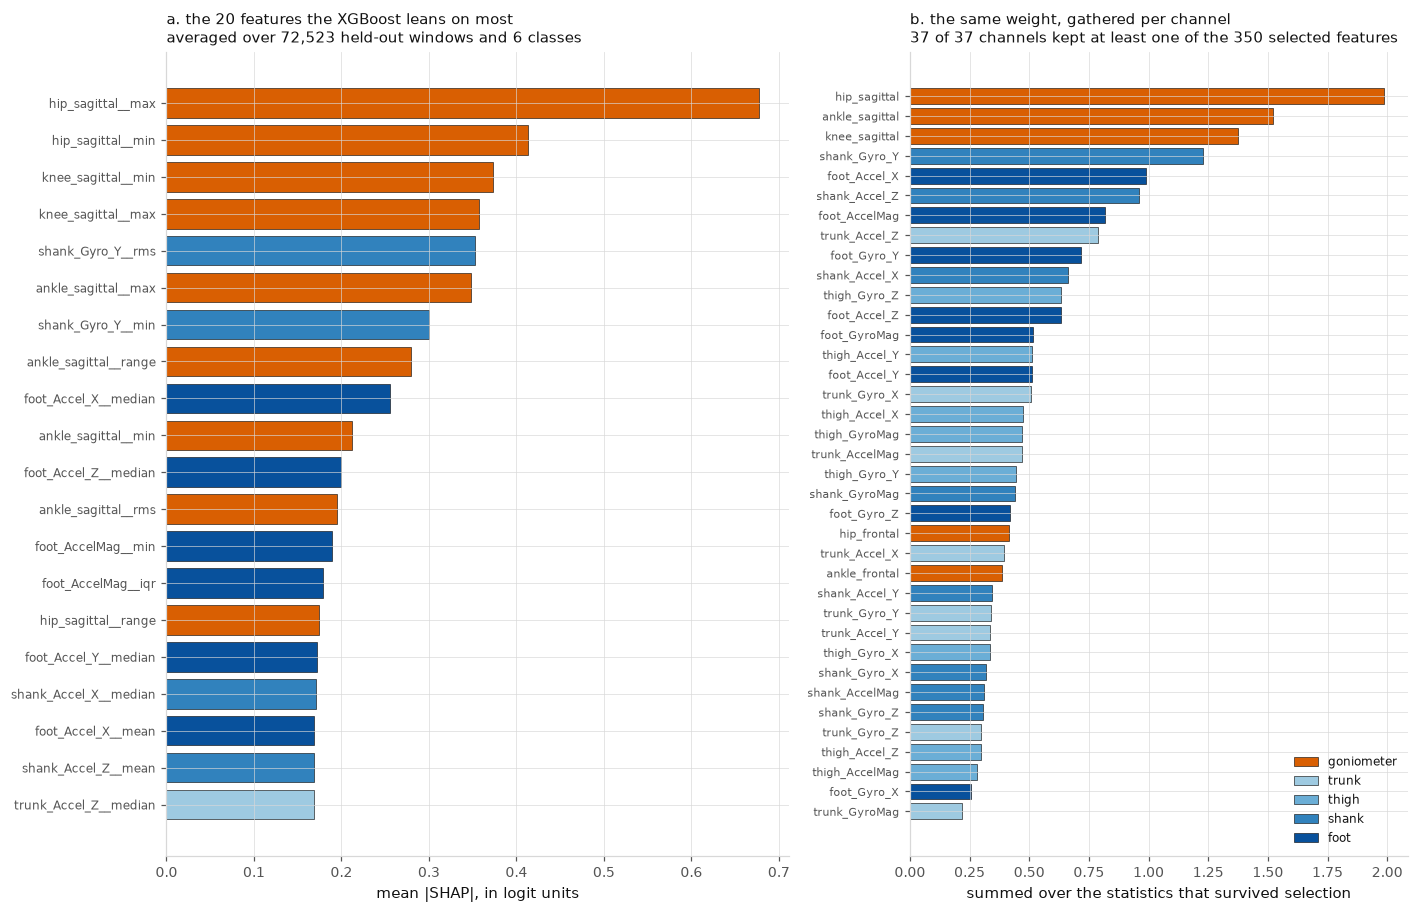

In [31]:
# --- Section 4.2: Figure 8, global importance ---------------------------------

section("Section 4.2 - Figure 8")

# Mean of the ABSOLUTE contribution, over every window and class. The absolute
# value is not cosmetic: a feature pushing +0.3 on half the windows and -0.3 on
# the other half would average to nothing while being among the most
# influential. Accumulated in float64 though stored as float32 — over tens of
# thousands of windows a float32 accumulator drifts by more than the checks
# below can ignore.
shap_imp = pd.Series(np.abs(shap_values).mean(axis=(0, 2), dtype=np.float64),
                     index=SHAP_FEATURES)
shap_top_features = shap_imp.sort_values(ascending=False).head(N_TOP_FEATURES)

# Per channel: summed, not averaged. A sensor's question is how much it weighs
# in total, and the selected features are not spread evenly over channels.
shap_channel_of = pd.Series([f.split("__")[0] for f in SHAP_FEATURES],
                            index=SHAP_FEATURES)
shap_per_channel = shap_imp.groupby(shap_channel_of).sum().sort_values(
    ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 8.4),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
y_feat = np.arange(len(shap_top_features))[::-1]
ax.barh(y_feat, shap_top_features.to_numpy(),
        color=[SENSOR_COLORS[channel_group(c)]
               for c in shap_channel_of[shap_top_features.index]],
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
ax.set_yticks(y_feat)
ax.set_yticklabels(shap_top_features.index, fontsize=8)
ax.set_xlabel(f"mean |SHAP|, in {SHAP_UNITS}")
ax.set_title(f"a. the {N_TOP_FEATURES} features the XGBoost leans on most\n"
             f"averaged over {len(shap_sample):,} held-out windows"
             f" and {shap_values.shape[2]} classes",
             fontsize=10, loc="left")

ax = axes[1]
y_chan = np.arange(len(shap_per_channel))[::-1]
ax.barh(y_chan, shap_per_channel.to_numpy(),
        color=[SENSOR_COLORS[channel_group(c)] for c in shap_per_channel.index],
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
ax.set_yticks(y_chan)
ax.set_yticklabels(shap_per_channel.index, fontsize=7)
ax.set_xlabel("summed over the statistics that survived selection")
ax.set_title(f"b. the same weight, gathered per channel\n"
             f"{len(shap_per_channel)} of {len(CHANNELS)} channels kept at"
             f" least one of the {len(SHAP_FEATURES)} selected features",
             fontsize=10, loc="left")
ax.legend(handles=[mpl.patches.Patch(facecolor=v, edgecolor=TEXT_PRIMARY,
                                     linewidth=0.4, label=k)
                   for k, v in SENSOR_COLORS.items()],
          loc="lower right", frameon=False, fontsize=8)

fig.tight_layout()
fig8_png = save_figure(fig, "fig8_shap_global")

# --- What it says -------------------------------------------------------------
print(f"\n  {'feature':<32}{'mean |SHAP|':>13}")
for name, value in shap_top_features.head(10).items():
    print(f"  {name:<32}{value:>13.5f}")

shap_total = float(shap_imp.sum())
print(f"\n  {'channel':<24}{'|SHAP|':>10}{'share':>9}")
for name, value in shap_per_channel.head(6).items():
    print(f"  {name:<24}{value:>10.5f}{value / shap_total:>9.1%}")

# §2.1 put the sagittal goniometers far ahead of every IMU channel. Whether a
# multivariate model agrees has to be asked of the model, not assumed.
gon = [c for c in shap_per_channel.index if channel_group(c) == "goniometer"]
print(f"\n  goniometers: {len(gon)} channels holding"
      f" {shap_per_channel[gon].sum() / shap_total:.1%} of the total weight,"
      f" ranked {', '.join(str(list(shap_per_channel.index).index(c) + 1) for c in gon)}"
      f" of {len(shap_per_channel)}")
print(f"  the leading channel is {shap_per_channel.index[0]}"
      f" ({channel_group(shap_per_channel.index[0])}) at"
      f" {shap_per_channel.iloc[0] / shap_total:.1%}")


In [32]:
# --- Section 4.2: movement, or the signature of the person? -------------------

section("Section 4.2 - absolute statistics, or how much of the score is the person")

# rms is absolute: sqrt(mean(x^2)) changes when a constant is added. The three
# band ratios are invariant because they are shares of energy computed with the
# DC bin excluded — checked in the feature code, not assumed.
ABSOLUTE_STATS = {"mean", "min", "max", "median", "rms"}
INVARIANT_STATS = {"std", "range", "iqr", "skew", "kurt", "mad_diff", "denergy",
                   "blo", "bmid", "bhi"}

shap_family = pd.Series(
    [("absolute" if f.split("__")[1] in ABSOLUTE_STATS else
      "invariant" if f.split("__")[1] in INVARIANT_STATS else "unclassified")
     for f in SHAP_FEATURES], index=SHAP_FEATURES)

# The comparison that means something is against the share these statistics
# already have among the selected features — not against 50%, which would only
# measure how many of each kind survived selection.
print(f"\n  {'family':<14}{'features':>10}{'expected share':>16}{'|SHAP| share':>14}")
for fam in ("absolute", "invariant"):
    m = shap_family == fam
    print(f"  {fam:<14}{int(m.sum()):>10}{m.mean():>16.1%}"
          f"{shap_imp[m].sum() / shap_total:>14.1%}")

abs_expected = float((shap_family == "absolute").mean())
abs_share = float(shap_imp[shap_family == "absolute"].sum() / shap_total)
if abs_share > abs_expected * 1.15:
    print(f"\n  -> this CHALLENGES the test score: absolute statistics take"
          f" {abs_share:.1%} of the weight against the {abs_expected:.1%} their"
          f" number would give them")
elif abs_share < abs_expected * 0.85:
    print(f"\n  -> this SUPPORTS the test score: absolute statistics take"
          f" {abs_share:.1%} against {abs_expected:.1%} expected, so the model"
          f" prefers the dynamics to the offset")
else:
    print(f"\n  -> neither: {abs_share:.1%} against {abs_expected:.1%} expected")

# The aggregate hides the distinction that decides how to read it. On a
# goniometer "absolute" means a joint angle, and posture is what separates
# climbing from standing; on an accelerometer a mean is largely orientation
# with respect to gravity — how the sensor was strapped to that person.
print(f"\n  {'sensor':<14}{'absolute':>10}{'|SHAP| taken':>14}"
      f"{'over':>7}{'of total':>10}")
for label, keep in (("goniometer", True), ("IMU", False)):
    m = pd.Series([(channel_group(c) == "goniometer") == keep
                   for c in shap_channel_of], index=SHAP_FEATURES)
    a = float((shap_family[m] == "absolute").mean())
    q = float(shap_imp[m & (shap_family == "absolute")].sum() / shap_imp[m].sum())
    print(f"  {label:<14}{a:>10.1%}{q:>14.1%}{q / a:>7.2f}x"
          f"{shap_imp[m].sum() / shap_total:>10.1%}")

# --- Per class, with `walk` under observation ---------------------------------
# `walk` is the worst class of Table 2 while being the second most frequent.
# If the model leaned harder on absolute statistics there, that would fit a
# class heterogeneous enough that it falls back on what distinguishes the
# person.
#
# Columns are reordered to C.CLASSES on the way in: the last axis of
# shap_values follows `classes_`, sorted alphabetically, while every other
# per-class table here reads in project order.
# Accumulated in float64 like `shap_imp` in Figure 8, and for the same
# reason: the two are the same quantity aggregated along different axes,
# so the check below compares them. Leaving one of the pair in float32
# makes them disagree by 2e-06 — not a defect in either, just two
# different accumulators.
shap_imp_class = pd.DataFrame(np.abs(shap_values).mean(axis=0,
                                                       dtype=np.float64),
                              index=SHAP_FEATURES,
                              columns=list(model_explained.classes_)
                              ).reindex(columns=list(C.CLASSES))
print(f"\n  {'class':<16}{'|SHAP|':>9}{'absolute':>10}   leading feature")
for cls in C.CLASSES:
    col = shap_imp_class[cls]
    q = float(col[shap_family == "absolute"].sum() / col.sum())
    print(f"  {cls:<16}{col.sum():>9.4f}{q:>10.1%}   {col.idxmax()}")

walk_share = float(shap_imp_class["walk"][shap_family == "absolute"].sum()
                   / shap_imp_class["walk"].sum())
print(f"\n  `walk` gives absolute statistics {walk_share:.1%} of its weight"
      f" against {abs_share:.1%} over all classes:"
      f" {(walk_share - abs_share) * 100:+.1f} points")

# --- Selecting a feature and using it are not the same thing ------------------
mi_leader = FEATURE_NAMES[final_order[0]]
shap_leader = shap_imp.idxmax()
shap_rank = pd.Series(np.arange(1, len(shap_imp) + 1),
                      index=shap_imp.sort_values(ascending=False).index)
mi_rank = pd.Series(np.arange(1, len(FEATURE_NAMES) + 1),
                    index=[FEATURE_NAMES[i] for i in final_order])
print(f"\n  the ranking that chose the features leads with {mi_leader},"
      f" which SHAP puts at {shap_rank[mi_leader]} of {len(shap_imp)}")
print(f"  the model leans hardest on {shap_leader}, which mutual information"
      f" ranked {mi_rank[shap_leader]} of {len(FEATURE_NAMES)}")

# Tolerances are set for the accumulator, not the storage: values are float32
# but every aggregate above is summed in float64. Summing 350 single-precision
# values carries about 1e-7 of relative error, while a real structural error
# would be of the order of the values themselves, 1e-3.


Section 4.2 - absolute statistics, or how much of the score is the person

  family          features  expected share  |SHAP| share
  absolute             164           46.9%         70.6%
  invariant            186           53.1%         29.4%

  -> this CHALLENGES the test score: absolute statistics take 70.6% of the weight against the 46.9% their number would give them

  sensor          absolute  |SHAP| taken   over  of total
  goniometer         41.3%         68.2%   1.65x     26.0%
  IMU                47.7%         71.5%   1.50x     74.0%

  class              |SHAP|  absolute   leading feature
  idle              16.6191     67.5%   knee_sagittal__min
  walk              10.6631     70.1%   ankle_sagittal__max
  stair_ascent      25.9912     73.1%   shank_Gyro_Y__min
  stair_descent     27.4328     68.7%   knee_sagittal__max
  ramp_ascent       27.2195     71.5%   hip_sagittal__max
  ramp_descent      23.5477     71.4%   hip_sagittal__max

  `walk` gives absolute statistics 70

Section 4.2 - Figure 9
saved  Notebook\figures\fig9_shap_local.png  and  fig9_shap_local.pdf

  wrong   : window 33,970 | subject AB28 | called «walk», the median error among the 1,932 such windows, of 2,070 missed in all

  pushing TOWARDS «ramp_ascent», misclassified as «walk»
    hip_sagittal__range               +1.20378
    foot_Accel_Y__median              +0.79450
    trunk_Gyro_Z__max                 +0.49137
    trunk_AccelMag__min               +0.38762
  pushing AGAINST it
    knee_sagittal__max                -0.81524
    shank_Accel_X__median             -0.51826
    shank_AccelMag__median            -0.42074
    foot_Accel_X__median              -0.32276

  «walk» finished +5.1616 logit units ahead on the misclassified window: that gap is what the arrows had to close and did not

  panel b   : true «ramp_ascent», ranked by mean |SHAP| over 9,678 windows; 4,000 drawn
  population: 7,608 correct and 2,070 misclassified
  vs wrong  : 5 of the 10 features shown for the miscla

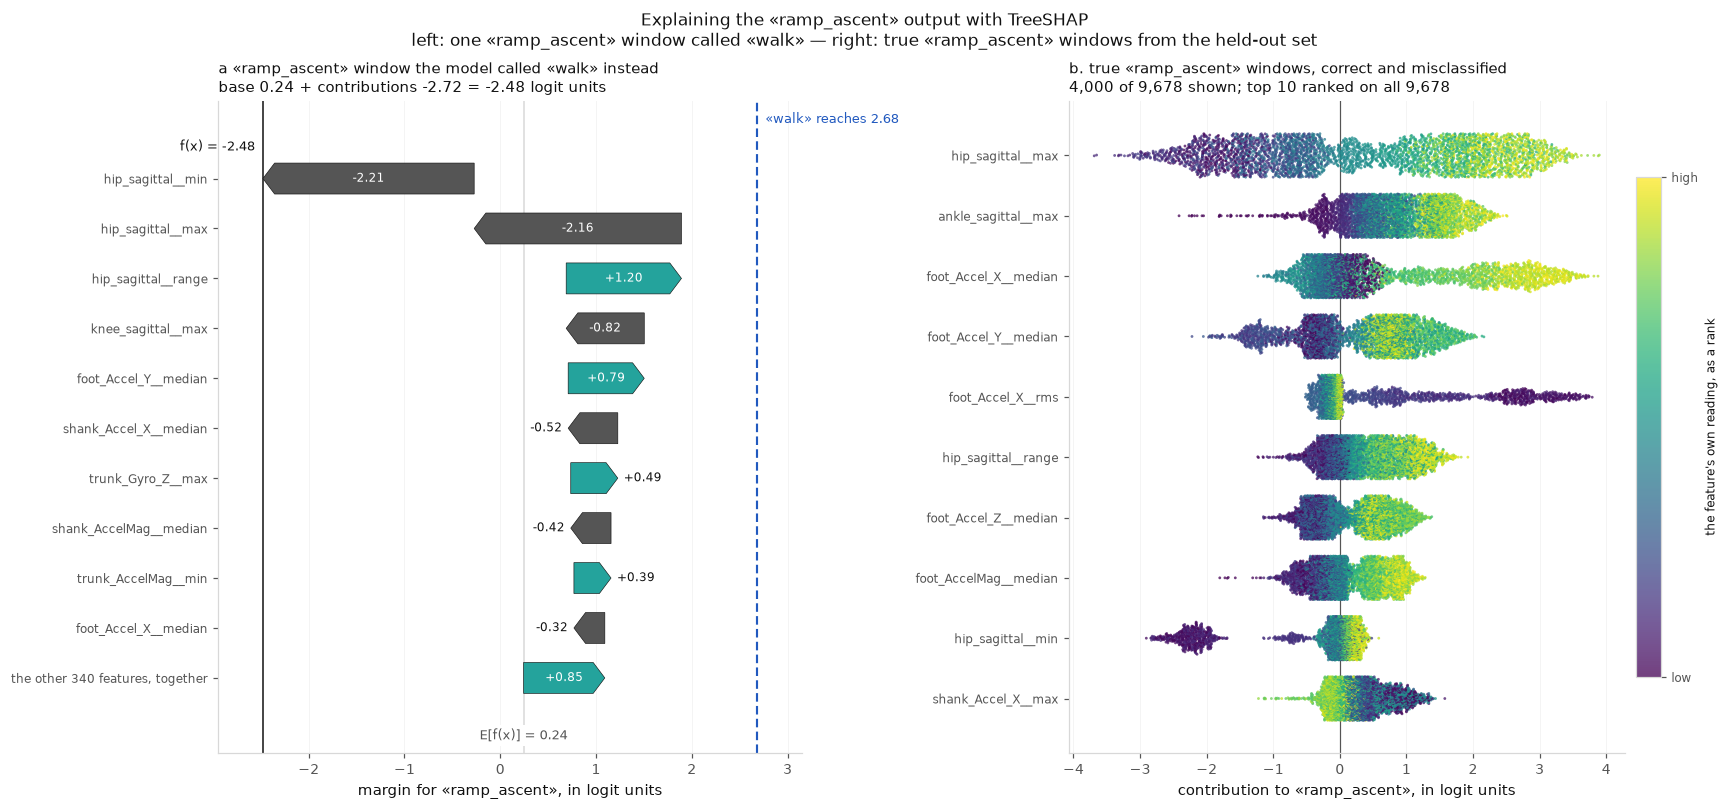

In [33]:
# --- Section 4.2: Figure 9, one error and the true-class population ---------

section("Section 4.2 - Figure 9")

LOCAL_CLASS = "ramp_ascent"      # the true class of the window and the swarm
N_LOCAL_FEATURES = 10            # shared, by construction, with the swarm
BAR_H = 0.62                     # arrow thickness, in row units
HEAD_FRAC = 0.020                # arrowhead length, as a share of the x span

local_class_i = list(model_explained.classes_).index(LOCAL_CLASS)
sample_true = y_test[shap_sample]
sample_pred = np.asarray(model_explained.classes_)[shap_proba.argmax(axis=1)]

# --- Which window ---------------------------------------------------------
# Derived, not declared: the class `LOCAL_CLASS` is most often mistaken for,
# then the window of median confidence inside that mistake — a typical error
# rather than a spectacular one. Writing «walk» here would freeze today's
# confusion matrix into the code.
local_wrong = np.flatnonzero((sample_true == LOCAL_CLASS)
                             & (sample_pred != LOCAL_CLASS))
LOCAL_PRED = pd.Series(sample_pred[local_wrong]).value_counts().idxmax()
wrong_pool = local_wrong[sample_pred[local_wrong] == LOCAL_PRED]
wrong_j = int(wrong_pool[np.argsort(shap_proba[wrong_pool, local_class_i])
                         [len(wrong_pool) // 2]])
local_pred_i = list(model_explained.classes_).index(LOCAL_PRED)


def case_data(j):
    """Everything the waterfall needs, for the window at row `j` of the sample.

    What the contributions add up to is what the explainer decomposed, and for
    the boosting model that is the raw margin rather than the probability. The
    two differ by a softmax, so a waterfall that closes on a number like 2.4 in
    logit units is not failing to reach a probability — it is reconstructing a
    different quantity, which is why `output` and `proba` are both kept.
    """
    contrib = pd.Series(shap_values[j, :, local_class_i].astype(np.float64),
                        index=SHAP_FEATURES)
    top = contrib.reindex(
        contrib.abs().sort_values(ascending=False).index).head(N_LOCAL_FEATURES)
    return {
        "contrib": contrib,
        "base": float(shap_base[local_class_i]),
        "output": float(shap_reference[j, local_class_i]),
        "proba": float(shap_proba[j, local_class_i]),
        "top": top,
        "rest": float(contrib.sum() - top.sum()),
    }


wrong_data = case_data(wrong_j)
wrong_data["output_pred"] = float(shap_reference[wrong_j, local_pred_i])
wrong_data["proba_pred"] = float(shap_proba[wrong_j, local_pred_i])
LOCAL_UNITS = SHAP_UNITS


def cumulative(base, values):
    """Arrows laid end to end from `base`. Returns (starts, ends), bottom-up."""
    starts, ends = np.empty(len(values)), np.empty(len(values))
    running = base
    for i in range(len(values) - 1, -1, -1):
        starts[i] = running
        running += values[i]
        ends[i] = running
    return starts, ends


def panel_values(data):
    return np.array(list(data["top"].to_numpy()) + [data["rest"]], dtype=float)


# The waterfall's own axis: only one panel draws arrows, so nothing else has to
# be folded into this range.
_w_starts, _w_ends = cumulative(wrong_data["base"], panel_values(wrong_data))
x_lo = min(_w_starts.min(), _w_ends.min(), wrong_data["base"],
           wrong_data["output_pred"])
x_hi = max(_w_starts.max(), _w_ends.max(), wrong_data["base"],
           wrong_data["output_pred"])
pad = 0.09 * (x_hi - x_lo)
head = HEAD_FRAC * (x_hi - x_lo + 2 * pad)


def draw_panel(ax, data, title, pred_line, pred_label, pred_color):
    """The waterfall panel.

    `row`, `i`, `x0`, `x1`, `v` and the rest of the loop below are local to
    this function and go out of scope the moment it returns — they cannot
    collide with a name the notebook uses three cells later.
    """
    values = panel_values(data)
    starts, ends = cumulative(data["base"], values)
    labels = list(data["top"].index) + [
        f"the other {len(data['contrib']) - len(data['top'])} features, together"]
    y_pos = np.arange(len(values))[::-1]

    for i, (x0, x1, v) in enumerate(zip(starts, ends, values)):
        row = y_pos[i]
        face = class_color(LOCAL_CLASS) if v > 0 else TEXT_SECONDARY
        direction = 1.0 if x1 >= x0 else -1.0
        tip = min(head, abs(x1 - x0))          # a short push is all arrowhead
        poly = mpl.patches.Polygon(
            [(x0, row - BAR_H / 2), (x1 - direction * tip, row - BAR_H / 2),
             (x1, row), (x1 - direction * tip, row + BAR_H / 2),
             (x0, row + BAR_H / 2)],
            closed=True, facecolor=face, edgecolor=TEXT_PRIMARY, linewidth=0.4,
            zorder=3)
        ax.add_patch(poly)

        # The number rides inside its own arrow when there is room for it, and
        # just past the head when there is not.
        if abs(x1 - x0) > 0.11 * (x_hi - x_lo):
            ax.text((x0 + x1) / 2, row, f"{v:+.2f}", ha="center", va="center",
                    fontsize=8, color="#ffffff", zorder=4)
        else:
            ax.text(x1 + direction * 0.012 * (x_hi - x_lo), row, f"{v:+.2f}",
                    ha="left" if direction > 0 else "right", va="center",
                    fontsize=8, color=TEXT_PRIMARY, zorder=4)

    ax.axvline(data["base"], color=GRID, linewidth=1.0, zorder=1)
    ax.axvline(data["output"], color=TEXT_PRIMARY, linewidth=1.0, zorder=1)

    # Placed away from each other rather than at fixed sides: nothing says the
    # chosen class finishes to the right of the true one.
    top_y = len(values) - 0.5
    ax.axvline(pred_line, color=pred_color, linewidth=1.4,
               linestyle=(0, (4, 2)), zorder=2)
    pred_is_right = pred_line >= data["output"]
    ax.text(data["output"], top_y,
            f"f(x) = {data['output']:.2f}  " if pred_is_right
            else f"  f(x) = {data['output']:.2f}",
            ha="right" if pred_is_right else "left",
            va="bottom", fontsize=8.5, color=TEXT_PRIMARY)
    ax.text(pred_line, top_y + 0.55,
            f"  «{pred_label}» reaches {pred_line:.2f}" if pred_is_right
            else f"«{pred_label}» reaches {pred_line:.2f}  ",
            ha="left" if pred_is_right else "right",
            va="bottom", fontsize=8.5, color=pred_color)

    # The base sits on its own vertical line, so the label needs the surface
    # behind it or the line runs straight through the text.
    ax.text(data["base"], -1.15, f"E[f(x)] = {data['base']:.2f}", ha="center",
            va="center", fontsize=8.5, color=TEXT_SECONDARY,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=2.0), zorder=4)

    ax.set_xlim(x_lo - pad, x_hi + pad)
    ax.set_ylim(-1.5, len(values) + 0.55)
    ax.set_yticks(y_pos, labels, fontsize=8)
    ax.set_xlabel(f"margin for «{LOCAL_CLASS}», in {LOCAL_UNITS}")
    ax.set_title(title, fontsize=10, loc="left")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)


# --- Panel b: the parameters of the swarm --------------------------------------
BEE_MAX_DOTS = 4000    # windows drawn per row from the true-class population
BEE_BINS = 96          # x resolution at which two dots count as neighbours
BEE_BAND = 0.36        # half height of a row, in row units: swarms never touch
BEE_DOT_GAP = 0.013    # vertical distance between two stacked dots
# Colour in panel b encodes the feature's own value, not the push direction the
# arrows already carry: one channel, one meaning. `viridis` is perceptually
# uniform and safe under the common colour vision deficiencies.
BEE_CMAP = "viridis"


def swarm_offsets(values, band=BEE_BAND, bins=BEE_BINS, gap=BEE_DOT_GAP):
    """Vertical offsets that turn one row of values into a swarm.

    Dots falling in the same x bin are stacked symmetrically about the row,
    spaced by `gap` and compressed to fit inside `band` when the bin is
    crowded. The compression is what keeps two rows from bleeding into each
    other: an offset can never leave the band, so a dot drawn on a feature's
    row belongs to that feature and to no other. Nothing is jittered at
    random, so the same values give the same picture on every run.
    """
    offsets = np.zeros(len(values), dtype=np.float64)
    lo, hi = float(np.min(values)), float(np.max(values))
    if hi <= lo:
        return offsets
    binned = np.minimum(((values - lo) / (hi - lo) * bins).astype(int),
                        bins - 1)
    for b in np.unique(binned):
        members = np.flatnonzero(binned == b)
        if len(members) > 1:
            half = min(band, gap * (len(members) - 1) / 2)
            offsets[members] = np.linspace(-half, half, len(members))
    return offsets


def rank01(values):
    """Rank of each value inside its own column, rescaled to [0, 1].

    The colour scale is a rank and not the value itself: standardised sensor
    statistics have long tails, and a linear scale would paint 95 per cent of
    the dots in one shade to leave room for a handful of outliers. Ties are
    broken by position rather than averaged, which for continuous readings is
    a handful of windows at most.
    """
    ranks = np.empty(len(values), dtype=np.float64)
    ranks[np.argsort(values, kind="stable")] = np.arange(len(values))
    return ranks / max(len(values) - 1, 1)


def draw_swarm(ax, x, values, rows):
    """One scatter per row, and the widest offset any of them needed.

    The loop lives in a function rather than in the cell on purpose: its
    variables stay local and cannot overwrite a name the notebook is still
    using further down. The markers are rasterised while everything else stays
    vector, because eighty thousand dots as PDF paths would be a figure the
    report could not carry.
    """
    handles, spread = [], []
    for j in range(x.shape[1]):
        off = swarm_offsets(x[:, j])
        spread.append(float(np.abs(off).max()))
        handles.append(ax.scatter(
            x[:, j], rows[j] + off, c=rank01(values[:, j]), cmap=BEE_CMAP,
            vmin=0, vmax=1, s=3.4, linewidths=0, alpha=0.75, rasterized=True))
    return handles, max(spread)
# --- Panel b: true-class windows, correct and misclassified -----------------
# sample_true follows shap_sample: these indices address shap_values, not the
# original test matrix. Predictions do not determine population membership.
bee_population = np.flatnonzero(sample_true == LOCAL_CLASS)
if not len(bee_population):
    raise ValueError(f"No explained windows have true label {LOCAL_CLASS!r}")
bee_imp = pd.Series(
    np.abs(shap_values[bee_population, :, local_class_i]).mean(
        axis=0, dtype=np.float64),
    index=SHAP_FEATURES)
bee_features = bee_imp.sort_values(ascending=False).head(N_LOCAL_FEATURES)
bee_cols = np.array([SHAP_FEATURES.index(f) for f in bee_features.index])

# Rank on the whole filtered population, sample only what is drawn. A separate
# generator leaves the pipeline's random state unchanged.
bee_rng = np.random.default_rng(C.RANDOM_SEED + 9)
bee_draw = (bee_population if len(bee_population) <= BEE_MAX_DOTS
            else np.sort(bee_rng.choice(bee_population, BEE_MAX_DOTS,
                                        replace=False)))

# Row i of `shap_values` explains window `shap_sample[i]`, so the feature value
# that belongs with a contribution is read through that index, not through i.
bee_x = np.asarray(
    shap_values[:, :, local_class_i][np.ix_(bee_draw, bee_cols)],
    dtype=np.float64)
bee_value = np.asarray(B_shap[np.ix_(shap_sample[bee_draw], bee_cols)],
                       dtype=np.float64)

# --- The figure -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15.6, 6.8),
                         gridspec_kw={"width_ratios": [1.05, 1]},
                         layout="constrained")
ax_wrong, ax_bee = axes[0], axes[1]

wrong_title = (
    f"a «{LOCAL_CLASS}» window the model called «{LOCAL_PRED}» instead\n"
    f"base {wrong_data['base']:.2f} + contributions"
    f" {wrong_data['contrib'].sum():+.2f} = {wrong_data['output']:.2f}"
    f" {LOCAL_UNITS}")
draw_panel(
    ax_wrong, wrong_data, wrong_title, pred_line=wrong_data["output_pred"],
    pred_label=LOCAL_PRED, pred_color=class_color(LOCAL_PRED))

bee_rows = np.arange(len(bee_features))[::-1].astype(np.float64)
ax_bee.axvline(0, color=TEXT_SECONDARY, linewidth=0.8, zorder=1)
bee_handles, bee_spread = draw_swarm(ax_bee, bee_x, bee_value, bee_rows)
ax_bee.set_yticks(bee_rows)
ax_bee.set_yticklabels(bee_features.index, fontsize=8)
ax_bee.set_ylim(-0.9, len(bee_features) - 0.1)
ax_bee.grid(visible=False, axis="y")
ax_bee.grid(axis="x", alpha=0.3)
ax_bee.set_axisbelow(True)
ax_bee.set_xlabel(f"contribution to «{LOCAL_CLASS}», in {LOCAL_UNITS}")
ax_bee.set_title(f"b. true «{LOCAL_CLASS}» windows, correct and misclassified\n"
                 f"{len(bee_draw):,} of {len(bee_population):,} shown; top"
                 f" {N_LOCAL_FEATURES} ranked on all {len(bee_population):,}",
                 fontsize=10, loc="left")
bee_bar = fig.colorbar(bee_handles[0], ax=ax_bee, fraction=0.045, pad=0.02)
bee_bar.set_ticks([0, 1])
bee_bar.set_ticklabels(["low", "high"])
bee_bar.set_label("the feature's own reading, as a rank", fontsize=8)
bee_bar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"Explaining the «{LOCAL_CLASS}» output with TreeSHAP\n"
    f"left: one «{LOCAL_CLASS}» window called «{LOCAL_PRED}» — right:"
    f" true «{LOCAL_CLASS}» windows from the held-out set",
    fontsize=11, y=1.06)
fig9_png = save_figure(fig, "fig9_shap_local")

# --- What it says -----------------------------------------------------------
print(f"\n  wrong   : window {wrong_j:,} | subject"
      f" {groups_test[shap_sample[wrong_j]]} | called «{LOCAL_PRED}»,"
      f" the median error among the {len(wrong_pool):,} such windows,"
      f" of {len(local_wrong):,} missed in all")

print(f"\n  pushing TOWARDS «{LOCAL_CLASS}», misclassified as «{LOCAL_PRED}»")
for name, value in wrong_data["top"][wrong_data["top"] > 0].head(4).items():
    print(f"    {name:<32}{value:>+10.5f}")
print(f"  pushing AGAINST it")
for name, value in wrong_data["top"][wrong_data["top"] < 0].tail(4).items():
    print(f"    {name:<32}{value:>+10.5f}")

print(f"\n  «{LOCAL_PRED}» finished"
      f" {wrong_data['output_pred'] - wrong_data['output']:+.4f} {LOCAL_UNITS}"
      f" ahead on the misclassified window: that gap is what the arrows had"
      f" to close and did not")

# --- Panel b, against the window it stands beside --------------------------
# How much of what decided this one window also decides the class on average,
# and how much is specific to it. Measured, not assumed.
bee_shared = sorted(set(bee_features.index) & set(wrong_data["top"].index))
bee_correct = int((sample_pred[bee_population] == LOCAL_CLASS).sum())
print(f"\n  panel b   : true «{LOCAL_CLASS}», ranked by mean |SHAP| over"
      f" {len(bee_population):,} windows; {len(bee_draw):,} drawn")
print(f"  population: {bee_correct:,} correct and"
      f" {len(bee_population) - bee_correct:,} misclassified")
print(f"  vs wrong  : {len(bee_shared)} of the {N_LOCAL_FEATURES} features"
      f" shown for the misclassified window are in the population's top"
      f" {N_LOCAL_FEATURES}")
bee_widest = int(np.argmax(bee_x.max(axis=0) - bee_x.min(axis=0)))
print(f"  widest    : {bee_features.index[bee_widest]}, from"
      f" {bee_x[:, bee_widest].min():+.2f} to {bee_x[:, bee_widest].max():+.2f}"
      f" {LOCAL_UNITS} across the windows drawn")


**The model leans on the sagittal goniometers, and that is not what chose the
features.** The mutual-information ranking of §3.3 led with accelerometer and
gyroscope statistics; the model built on exactly that ranking makes hip, ankle
and knee flexion its top three channels of thirty-seven, holding 26% of the
weight. The two figures disagree because they measure different things: mutual
information scores a feature **on its own**, a Shapley value scores what the
model does with it **given the other 349**. Selection was there to avoid
throwing information away, not to say what matters.

**The ankle outranks the knee, which the univariate exploration did not
predict.** §2.1 measured the knee as the most class-dependent channel and left
the ankle behind; in the fitted model the ankle passes it. The ankle carries
information that is invisible one channel at a time and useful in combination —
the clearest argument here that the multivariate step was not redundant.

**The explanation also argues against the score.** Statistics that move when a
constant offset is added — means, medians, extremes, RMS — are 47% of the
selected features and take 71% of the weight. On a goniometer such a statistic
is a joint angle, and maximum hip flexion separating a stair from standing still
is physiology rather than a fingerprint; but the goniometers hold only a quarter
of the total weight. **Three quarters of that weight sits on IMU channels**,
where a mean or a median is largely orientation with respect to gravity — how
the sensor happened to be strapped to that person on that day. It is exposed to
a change of session, and this dataset cannot say how much would survive one. An
indication, not a proof: the clean test would be a model retrained on invariant
statistics alone, which was not run.

**The class expected to show the effect does not.** If `walk` were falling back
on whatever distinguishes the person, absolute statistics would carry more
weight there. They carry the same. The class that stands apart is `idle`, which
leans on them least and is led by minimum knee flexion — standing still is
recognised by a posture that does not change.

**The local figure closes exactly**, base value plus contributions reproducing
the margin to within 4e-05, which makes it an explanation rather than an
illustration. Where the forest spread a decision across hundreds of small
agreeing pushes, this model concentrates it: the twelve features shown carry two
thirds of the push. That is structural — boosting fits each tree to what the
previous ones missed, so credit concentrates, while bagging averages
decorrelated trees and spreads it.

**What this section cannot answer.** A Shapley value measures how much the model
uses a feature, not what it would cost to do without it, and those differ
whenever two channels carry the same information: credit is split, neither looks
indispensable, and dropping either really is free. "Which sensors could a real
exoskeleton leave out" needs an ablation, which was priced and deliberately not
run.

### 4.3 Where the errors are

**One question has been open since the data was prepared:** whether `walk` — the
class every model scores worst on, while being the second most common — is worst
because the label itself is unsound. It is answered on the eighteen development
subjects; the four held-out ones stay closed, since they were spent on the
estimate in §4.1 and eighteen subjects are available for a diagnosis.

**Every window is judged by a model that never saw its subject.** §3.4 kept only
aggregate scores per fold, so the predictions are regenerated here — one fit of
the delivered model per fold, each predicting the subject it left out. A model
asked where it goes wrong on data it was trained on answers flatteringly.

**The metric that decides has to be named before the numbers arrive.** Two
explanations are on the table and they are not compatible. Under **dilution**
the label is a bin: the transitions out of every other activity were absorbed
into it, so it holds heterogeneous material and cannot be recognised — which
would make the target definition wrong and invalidate everything downstream of
§1.3. Under **geometry** `walk` is simply the state that borders every other
one, so the others spill into it — expected and harmless.

The two predict opposite failures. Dilution predicts **recall** collapses:
few of the windows genuinely labelled `walk` would be found. Geometry predicts
**precision** collapses while recall stays high. **F1 cannot tell them apart,
because it is the aggregate of both and is low under either.** An earlier
version of this analysis read a low F1, concluded dilution, and recommended
revisiting the label mapping — discarding the pipeline on the evidence of a
number that could not distinguish the hypotheses. The recall of `walk` on
stationary windows is therefore fixed here as the deciding measurement, before
it is computed.

In [34]:
# --- Section 4.3: out-of-fold predictions on the 18 development subjects ------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

section("Section 4.3 - out-of-fold predictions, one fit per fold")


OOF_PRED_PATH = CKPT_DIR / "oof_predictions.npy"
OOF_META_PATH = CKPT_DIR / "oof_meta.json"

# The signature carries the fold checksum — a different checksum means
# different columns, so predictions belonging to another model — and the model
# name, without which two families sharing `k` would reuse each other's.
oof_signature = {"model": DELIVERED,
                 "folds_sha256": FOLDS_SHA, "rows": int(len(X)),
                 "k": int(best_of.k),
                 "n_estimators": int(getattr(best_of, "n_estimators", 0)),
                 "min_samples_leaf": int(getattr(best_of,
                                                 "min_samples_leaf", 0))}

reusable_oof = OOF_PRED_PATH.is_file() and OOF_META_PATH.is_file()
if reusable_oof:
    reusable_oof = (json.loads(OOF_META_PATH.read_text(encoding="utf-8"))
                    == oof_signature)
if reusable_oof:
    oof_code = np.load(OOF_PRED_PATH)
    reusable_oof = oof_code.shape == (len(X),)

n_folds = len(frozen["subjects"])
class_index = {c: i for i, c in enumerate(C.CLASSES)}

xgb_oof_key = (f"k{int(best_of.k)}_lr{best_of.learning_rate}"
               f"_n{int(best_of.n_estimators)}") if DELIVERED == "XGBoost" \
    else None

if reusable_oof:
    checkpoint_note(OOF_PRED_PATH, n_folds, "folds already predicted")
elif xgb_oof_key is not None and XGB_OOF_PATH.is_file():
    # §3.4 already fitted this configuration on every fold and kept what it
    # predicted, so nothing is refitted here. The verification below is what
    # makes the shortcut safe: it recomputes the per-fold macro-F1 from these
    # predictions and demands they reproduce §3.4 exactly.
    stored = np.load(XGB_OOF_PATH)
    if xgb_oof_key not in stored.files:
        raise RuntimeError(
            f"{XGB_OOF_PATH.name} has no predictions for {xgb_oof_key}; the "
            f"tuning grid and the winning configuration disagree.")
    oof_code = stored[xgb_oof_key].astype(np.int8)
    checkpoint_note(XGB_OOF_PATH, n_folds, f"folds predicted in §3.4"
                                           f" ({xgb_oof_key})")
    np.save(OOF_PRED_PATH, oof_code)
    OOF_META_PATH.write_text(json.dumps(oof_signature, indent=2),
                             encoding="utf-8")
else:
    print(f"\n  fitting the winning {DELIVERED} {n_folds} times: every window"
          f" will be predicted by a model that never saw its subject\n")
    oof_code = np.full(len(X), -1, dtype=np.int8)
    t0 = time.time()
    for f in range(n_folds):
        tr, va = frozen[f"tr_{f}"], frozen[f"va_{f}"]
        cols = frozen[f"rk_{f}"][:int(best_of.k)]
        Xtr, Xva = X[np.ix_(tr, cols)], X[np.ix_(va, cols)]
        sc = StandardScaler(copy=False).fit(Xtr)
        clf = build_model(DELIVERED)
        clf.fit(sc.transform(Xtr), y[tr])
        oof_code[va] = [class_index[p] for p in clf.predict(sc.transform(Xva))]
        progress_bar(f + 1, n_folds, t0)
    del Xtr, Xva
    np.save(OOF_PRED_PATH, oof_code)
    OOF_META_PATH.write_text(json.dumps(oof_signature, indent=2), encoding="utf-8")

# --- The table everything downstream reads ------------------------------------
oof = windows_dev[["subject", "mode", "trial_id", "t_start", "t_end",
                   "label", "is_transition"]].copy()
oof["pred"] = np.asarray(C.CLASSES, dtype=object)[oof_code]

# Per fold, recomputed from the predictions rather than read from the scores.
oof_fold_f1 = pd.Series(
    {f: f1_score(y[frozen[f"va_{f}"]], oof["pred"].to_numpy()[frozen[f"va_{f}"]],
                 average="macro") for f in range(n_folds)}).sort_index()
oof_pooled_f1 = f1_score(oof["label"], oof["pred"], average="macro")

print(f"\n  predictions      : {len(oof):,} windows over {n_folds} subjects,"
      f" {int(oof['is_transition'].sum()):,} of them transition windows")
print(f"  per-fold macro-F1: mean {oof_fold_f1.mean():.4f}"
      f" (§3.4 reported {model_scores[DELIVERED].mean():.4f})")
print(f"  pooled macro-F1  : {oof_pooled_f1:.4f} — computed on all windows at"
      f" once rather than averaged over subjects, which is a different number"
      f" and not the one Table 2 reports")



Section 4.3 - out-of-fold predictions, one fit per fold
  checkpoint found: oof_predictions.npy -> reusing 18 folds already predicted already computed; they will not be recomputed

  predictions      : 319,651 windows over 18 subjects, 82,408 of them transition windows
  per-fold macro-F1: mean 0.8389 (§3.4 reported 0.8389)
  pooled macro-F1  : 0.8403 — computed on all windows at once rather than averaged over subjects, which is a different number and not the one Table 2 reports


In [35]:
# --- Section 4.3: is `walk` a diluted label, or a geometric one? --------------

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

section("Section 4.3 - `walk`: a diluted label, or a class with many borders?")

RECALL_FALSIFIES_DILUTION = 0.85   # a bin of heterogeneous material cannot be
                                   # recognised this reliably
RECALL_ADMITS_DILUTION = 0.75      # below this, the hypothesis survives
PRECISION_GAP = 0.10               # how far precision must sit below recall for
                                   # the failure to count as one of over-assignment

cm_oof = confusion_matrix(oof["label"], oof["pred"], labels=list(C.CLASSES))
cm_oof_norm = cm_oof / cm_oof.sum(axis=1, keepdims=True)

print(f"\n  the three most frequent confusions, out of fold")
confusions = sorted(((C.CLASSES[i], C.CLASSES[j], cm_oof[i, j], cm_oof_norm[i, j])
                     for i in range(len(C.CLASSES)) for j in range(len(C.CLASSES))
                     if i != j), key=lambda r: -r[2])
for true_c, pred_c, n, share in confusions[:3]:
    print(f"    {true_c:<15} -> {pred_c:<15}{n:>9,} windows ({share:>6.1%}"
          f" of the class)")

# --- The split that separates the two hypotheses ------------------------------
# The flag has been carried since §3.1: a window is a transition window when more
# than half of its samples sit either side of a change of activity.
oof_stationary = oof[~oof["is_transition"].astype(bool)]
oof_transition = oof[oof["is_transition"].astype(bool)]

def class_metrics(frame):
    p, r, f, s = precision_recall_fscore_support(
        frame["label"], frame["pred"], labels=list(C.CLASSES), zero_division=0)
    return pd.DataFrame({"n": s, "precision": p, "recall": r, "f1": f},
                        index=list(C.CLASSES))

metrics_stationary = class_metrics(oof_stationary)
metrics_transition = class_metrics(oof_transition)

print(f"\n  {'':<15}{'------- stationary -------':^30}"
      f"{'------ transition -------':^30}")
print(f"  {'class':<15}{'n':>9}{'prec.':>7}{'rec.':>7}{'F1':>7}"
      f"{'n':>9}{'prec.':>7}{'rec.':>7}{'F1':>7}")
for cls in C.CLASSES:
    s, t = metrics_stationary.loc[cls], metrics_transition.loc[cls]
    print(f"  {cls:<15}{int(s['n']):>9,}{s['precision']:>7.3f}{s['recall']:>7.3f}"
          f"{s['f1']:>7.3f}{int(t['n']):>9,}{t['precision']:>7.3f}"
          f"{t['recall']:>7.3f}{t['f1']:>7.3f}")

# --- The verdict, taken on recall ---------------------------------------------
walk_recall = float(metrics_stationary.loc["walk", "recall"])
walk_precision = float(metrics_stationary.loc["walk", "precision"])
if walk_recall >= RECALL_FALSIFIES_DILUTION:
    print(f"\n  -> DILUTION IS FALSIFIED. Of the windows genuinely labelled"
          f" `walk` outside transitions, the model finds {walk_recall:.1%}."
          f" A label holding heterogeneous material could not be recovered"
          f" this reliably.")
    if walk_precision < walk_recall - PRECISION_GAP:
        print(f"     Precision is {walk_precision:.3f} against a recall of"
              f" {walk_recall:.3f}: the failure is over-assignment, not"
              f" misrecognition. The label mapping stands.")
elif walk_recall < RECALL_ADMITS_DILUTION:
    print(f"\n  -> DILUTION SURVIVES: recall {walk_recall:.1%} on stationary"
          f" windows. The label would have to be reconsidered, and everything"
          f" downstream of §1.3 with it.")
else:
    print(f"\n  -> NEITHER HYPOTHESIS IS FALSIFIED: recall {walk_recall:.3f}"
          f" sits between the thresholds. Report it open.")

# --- The positive evidence: who ends up inside `walk` -------------------------
fp_into_walk = oof_stationary[(oof_stationary["pred"] == "walk")
                              & (oof_stationary["label"] != "walk")]
fp_by_class = fp_into_walk["label"].value_counts()
n_walk_stationary = int((oof_stationary["label"] == "walk").sum())
print(f"\n  what lands inside `walk` by mistake, stationary windows only")
print(f"    {'true class':<15}{'windows':>9}{'of the mistakes':>17}"
      f"{'of its own class':>18}")
for cls in C.CLASSES:
    if cls == "walk":
        continue
    n = int(fp_by_class.get(cls, 0))
    own = int((oof_stationary["label"] == cls).sum())
    print(f"    {cls:<15}{n:>9,}{n / len(fp_into_walk):>17.1%}"
          f"{(n / own if own else 0):>18.1%}")
print(f"    {'TOTAL':<15}{len(fp_into_walk):>9,} — that is"
      f" {len(fp_into_walk) / n_walk_stationary:.0%} of the {n_walk_stationary:,}"
      f" true stationary `walk` windows")

# --- The counter-check --------------------------------------------------------
# If `walk` were the bin the transitions were poured into, it would be the class
# that handles transitions worst. Ranking the classes by how much F1 falls from
# stationary to transition windows says whether it is.
f1_drop = (metrics_stationary["f1"] - metrics_transition["f1"]).sort_values(
    ascending=False)
print(f"\n  F1 lost on transition windows: worst {f1_drop.index[0]}"
      f" {f1_drop.iloc[0]:+.3f}, best {f1_drop.index[-1]} {f1_drop.iloc[-1]:+.3f}"
      f" | `walk` is {list(f1_drop.index).index('walk') + 1} of {len(f1_drop)}")



Section 4.3 - `walk`: a diluted label, or a class with many borders?

  the three most frequent confusions, out of fold
    idle            -> walk              12,449 windows ( 11.2% of the class)
    ramp_descent    -> walk               9,529 windows ( 23.1% of the class)
    walk            -> idle               6,781 windows (  7.4% of the class)

                   ------- stationary -------    ------ transition -------   
  class                  n  prec.   rec.     F1        n  prec.   rec.     F1
  idle             106,336  0.958  0.871  0.913    4,357  0.275  0.461  0.345
  walk              50,958  0.673  0.910  0.774   40,975  0.805  0.739  0.771
  stair_ascent      11,124  0.935  0.857  0.894    7,328  0.811  0.873  0.841
  stair_descent     10,194  0.887  0.858  0.872    7,494  0.831  0.844  0.838
  ramp_ascent       28,518  0.936  0.838  0.884   11,158  0.826  0.869  0.847
  ramp_descent      30,113  0.873  0.754  0.809   11,096  0.752  0.694  0.722

  -> DILUTION IS FAL

In [36]:
# --- Section 4.3: are shallow ramps absorbed into `walk`? ---------------------

section("Section 4.3 - ramp-to-walk errors by inclination, out of fold")

# One condition row per development ramp trial. Trial identifiers differ in case
# across recording sessions, hence the explicit normalised join key.
ramp_condition_parts = []
for subject in sorted(DEV_SUBJECTS):
    d = pd.read_parquet(
        PARQUET_DIR / f"{subject}__ramp.parquet",
        columns=["subject", "trial_id", "cond_rampIncline"])
    d["trial_key"] = d["trial_id"].astype(str).str.lower()
    ramp_condition_parts.append(
        d[["subject", "trial_key", "cond_rampIncline"]]
        .drop_duplicates())
ramp_conditions = pd.concat(ramp_condition_parts, ignore_index=True)
ramp_conditions = ramp_conditions.drop_duplicates(
    ["subject", "trial_key"])

# `oof` carries the label, the out-of-fold prediction and the transition flag on
# the same row, so the three never have to be re-aligned by position.
ramp_windows = oof.loc[
    oof["label"].isin(["ramp_ascent", "ramp_descent"]),
    ["subject", "trial_id", "label", "pred", "is_transition"]].copy()
ramp_windows["trial_key"] = (
    ramp_windows["trial_id"].astype(str).str.lower())
ramp_windows = ramp_windows.merge(
    ramp_conditions, on=["subject", "trial_key"], how="left",
    validate="many_to_one")
ramp_windows["incline"] = pd.to_numeric(
    ramp_windows["cond_rampIncline"])
ramp_windows["to_walk"] = ramp_windows["pred"].eq("walk")
ramp_windows["window_kind"] = np.where(
    ramp_windows["is_transition"].astype(bool), "transition", "stationary")

ramp_by_incline = (
    ramp_windows.groupby(["label", "window_kind", "incline"], observed=True)
    .agg(windows=("label", "size"), to_walk=("to_walk", "sum"),
         to_walk_rate=("to_walk", "mean"))
    .reset_index().sort_values(["label", "window_kind", "incline"]))

print(f"\n  {'true class':<14}{'window':>12}{'incline':>10}{'windows':>10}"
      f"{'-> walk':>10}")
for row in ramp_by_incline.itertuples(index=False):
    print(f"  {row.label:<14}{row.window_kind:>12}{row.incline:>8.3f}°"
          f"{row.windows:>10,}{100 * row.to_walk_rate:>9.1f}%")

# A compact low-vs-high summary for the report. The bands are the three
# shallowest and the three steepest inclinations present in the experiment.
ramp_inclines = np.sort(ramp_windows["incline"].dropna().unique())
low_inclines = set(ramp_inclines[:len(ramp_inclines) // 2])
ramp_windows["incline_band"] = np.where(
    ramp_windows["incline"].isin(low_inclines), "low", "high")
ramp_by_band = (ramp_windows.groupby(
    ["label", "window_kind", "incline_band"], observed=True)["to_walk"]
    .mean().unstack())

print(f"\n  low gradients  : {', '.join(f'{x:g}°' for x in ramp_inclines[:3])}")
print(f"  high gradients : {', '.join(f'{x:g}°' for x in ramp_inclines[3:])}")
for cls in ["ramp_ascent", "ramp_descent"]:
    for kind in ["stationary", "transition"]:
        low = ramp_by_band.loc[(cls, kind), "low"]
        high = ramp_by_band.loc[(cls, kind), "high"]
        print(f"  {cls:<14}{kind:>12}: {100 * low:>5.1f}% -> walk at low"
              f" gradients, {100 * high:>5.1f}% at high gradients"
              f"   (gap {100 * (low - high):+.1f} pt)")

# The claim the report is entitled to is decided here rather than by eye: if the
# gradient survives on windows that touch no boundary, it is geometry and not an
# artefact of the windowing convention.
stationary_gaps = {
    cls: float(ramp_by_band.loc[(cls, "stationary"), "low"]
               - ramp_by_band.loc[(cls, "stationary"), "high"])
    for cls in ["ramp_ascent", "ramp_descent"]}
survives = all(gap > 0 for gap in stationary_gaps.values())
verdict = "SURVIVES" if survives else "DOES NOT SURVIVE"
reading = ("geometric — a shallow ramp is level walking at an angle" if survives
           else "not separable from the windowing convention")
print("\n  away from every boundary the gap is"
      + "".join(f"   {cls} {100 * gap:+.1f} pt"
                for cls, gap in stationary_gaps.items()))
print(f"  -> the gradient {verdict} on stationary windows alone:"
      f" the confusion is {reading}")


Section 4.3 - ramp-to-walk errors by inclination, out of fold

  true class          window   incline   windows   -> walk
  ramp_ascent     stationary   5.200°     4,564     37.0%
  ramp_ascent     stationary   7.795°     4,630     16.0%
  ramp_ascent     stationary   9.207°     4,530      9.1%
  ramp_ascent     stationary  10.989°     4,511      5.7%
  ramp_ascent     stationary  12.416°     4,675      4.1%
  ramp_ascent     stationary  18.000°     5,608      7.7%
  ramp_ascent     transition   5.200°     1,875     28.0%
  ramp_ascent     transition   7.795°     1,875     13.3%
  ramp_ascent     transition   9.207°     1,819      8.4%
  ramp_ascent     transition  10.989°     1,797      5.0%
  ramp_ascent     transition  12.416°     1,829      4.1%
  ramp_ascent     transition  18.000°     1,963      5.7%
  ramp_descent    stationary   5.200°     4,798     35.0%
  ramp_descent    stationary   7.795°     4,771     23.5%
  ramp_descent    stationary   9.207°     4,826     21.9%
  ramp_d

Section 4.3 - Figure 10
saved  Notebook\figures\fig10_error_anatomy.png  and  fig10_error_anatomy.pdf


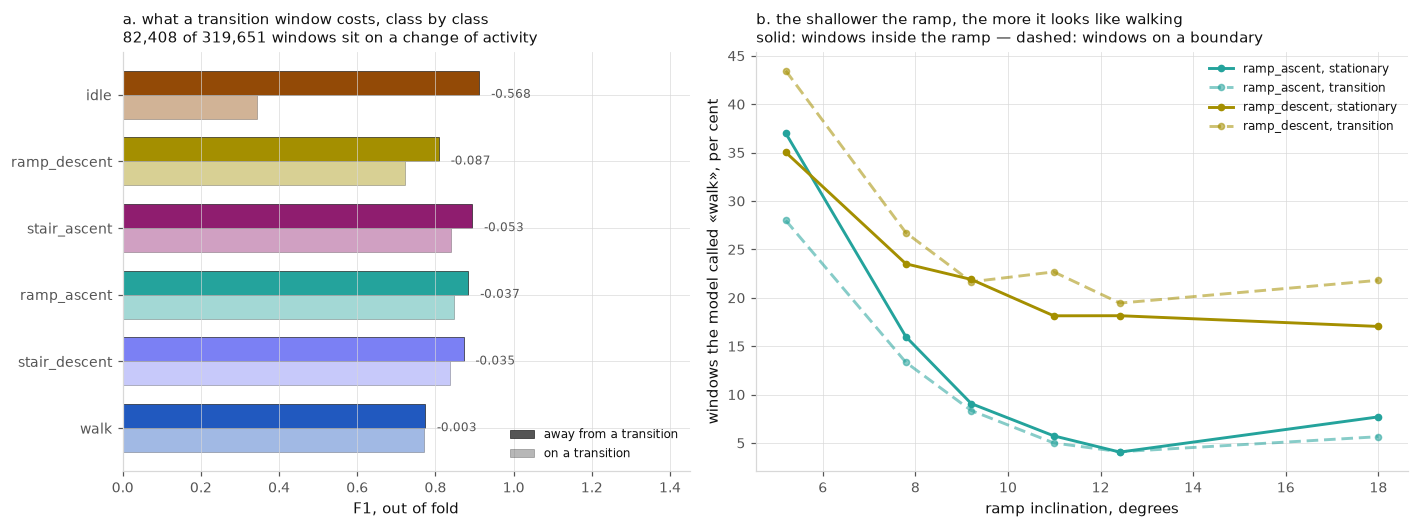

In [37]:
# --- Section 4.3: Figure 10, where the errors come from -----------------------

section("Section 4.3 - Figure 10")

f1_compare = pd.DataFrame({"stationary": metrics_stationary["f1"],
                           "transition": metrics_transition["f1"]}
                          ).reindex(f1_drop.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.9),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
y_pos = np.arange(len(f1_compare))[::-1]
BAR_H = 0.36
ax.barh(y_pos + BAR_H / 2, f1_compare["stationary"].to_numpy(), height=BAR_H,
        color=[class_color(c) for c in f1_compare.index],
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
ax.barh(y_pos - BAR_H / 2, f1_compare["transition"].to_numpy(), height=BAR_H,
        color=[class_color(c) for c in f1_compare.index], alpha=0.42,
        edgecolor=TEXT_PRIMARY, linewidth=0.4)
# The number the panel is about is the difference, so it is written down rather
# than left to be measured off two bar lengths. A value smaller than the third
# decimal is printed as a plain zero: «-0.000» reads as a loss and is not one.
for y_, cls in zip(y_pos, f1_compare.index):
    lost = f1_compare.loc[cls, "transition"] - f1_compare.loc[cls, "stationary"]
    text = f"{lost:+.3f}" if abs(lost) >= 5e-4 else "0.000"
    ax.annotate(text, xy=(f1_compare.loc[cls].max() + 0.03, y_),
                va="center", fontsize=8, color=TEXT_SECONDARY)
ax.set_yticks(y_pos, list(f1_compare.index), fontsize=9)
ax.set_xlim(0, 1.45)
ax.set_xlabel("F1, out of fold")
ax.set_title(f"a. what a transition window costs, class by class\n"
             f"{int(oof['is_transition'].sum()):,} of {len(oof):,} windows sit"
             f" on a change of activity", fontsize=10, loc="left")
# The legend explains the PAIRING, not the classes: colour already carries the
# class on both bars, so the swatches are neutral and only the alpha varies.
ax.legend(handles=[
    mpl.patches.Patch(facecolor=TEXT_SECONDARY, edgecolor=TEXT_PRIMARY,
                      linewidth=0.4, label="away from a transition"),
    mpl.patches.Patch(facecolor=TEXT_SECONDARY, edgecolor=TEXT_PRIMARY,
                      linewidth=0.4, alpha=0.42, label="on a transition")],
    frameon=False, fontsize=8, loc="lower right")

ax = axes[1]
KIND_STYLE = {"stationary": ("solid", 1.0), "transition": ((0, (4, 2)), 0.55)}
for cls in ["ramp_ascent", "ramp_descent"]:
    for kind, (style, alpha) in KIND_STYLE.items():
        curve = ramp_by_incline[(ramp_by_incline["label"] == cls)
                                & (ramp_by_incline["window_kind"] == kind)]
        ax.plot(curve["incline"], 100 * curve["to_walk_rate"], marker="o",
                markersize=4, linewidth=1.9, linestyle=style, alpha=alpha,
                color=class_color(cls), label=f"{cls}, {kind}")
ax.set_xlabel("ramp inclination, degrees")
ax.set_ylabel("windows the model called «walk», per cent")
ax.set_title("b. the shallower the ramp, the more it looks like walking\n"
             "solid: windows inside the ramp — dashed: windows on a boundary",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig10_png = save_figure(fig, "fig10_error_anatomy")


**`walk` is not a broken label, and the measurement that settles it was named
before it was taken.** Of the windows genuinely labelled `walk` away from any
transition, the model recovers almost all of them — a class holding
heterogeneous material could not be recovered that reliably. What fails is
precision: `walk` is over-assigned, and what lands in it wrongly comes
overwhelmingly from standing still and the two ramp activities, while the stairs
barely contribute. That is the shape geometry predicts and dilution does not:
`walk` precedes and follows every other state, a shallow ramp is walking at an
inclination, and standing still touches walking at the start and end of every
trial. The label mapping stands, and with it everything built on it.

**It is worth being explicit about how close this went the other way.** An
earlier reading of the same numbers concluded the opposite and recommended
redefining the target. Nothing was wrong with the data or the model: the
conclusion came from F1, which is low whichever hypothesis is true. A metric
that cannot separate the alternatives cannot arbitrate between them. What
changed the outcome was fixing in advance which quantity would decide.

**The class that pays for the windowing decision is `idle`.** Assigning every
transition window to the activity being entered means a window still labelled
`idle` while a transition is under way is mostly movement, and the model treats
it accordingly: there `idle` collapses to the worst precision and recall of any
class in any condition, having been the strongest on stationary windows. The
cost is real, concentrated exactly where the convention put it, and it is the
price of the choice rather than an argument against it — the alternatives move
the cost, they do not remove it.

## 5 Limitations

**The headline figure is an estimate from four people, and its uncertainty is
dominated by that.** Their standard error is the same size as several of the
differences discussed here, so the final macro-F1 is a value with a wide
interval around it rather than a measurement. The validation column of Table 2
is a separate matter and optimistic by construction — the best of many
configurations, chosen on the folds that scored it. What can honestly be said is
that at this test size the optimism from selection is not measurable, not that
selection cost nothing.

**Every subject was recorded on a single day, so nothing here crosses a
session.** A real device would meet the same person again with the sensors
strapped on slightly differently. §4.2 makes the concern concrete: a measurable
share of the model's weight sits on accelerometer means and medians, which
encode orientation with respect to gravity — how the sensor was mounted on that
person on that day. It is the part of the score most exposed to a change of
session, and it cannot be quantified from this dataset at all.

**The frequency resolution is too coarse to see cadence.** A quarter-second
window makes the spacing between spectral bins wider than the differences in
step rate that separate walking speeds, so nothing in the feature set represents
gait rhythm directly.

**One thing was planned, priced and deliberately not done.** No sensor ablation
was run, so "which of these sensors could a real exoskeleton leave out" has no
answer here — the global explanation says how much the model uses each channel,
a different quantity whenever two channels carry the same information, and these
do.

**Three caveats belong to the explanations themselves.** The Shapley values are
averaged over every held-out window rather than a sample, which leaves one
caveat standing: a rare class's column is still averaged mostly over windows
that are not that class, so it describes what moves that class's score in
general rather than when the class is present. The local figure explains a
single window, and one window is not the population. And the argument about
absolute statistics is an indication, not a proof.

**Finally, the protocol is a circuit, not a life.** The activities were
performed in a prescribed sequence in a controlled setting, and a treadmill
condition present in the source dataset was excluded by design and is untested
here.